# 2024 Pinot noir analysis notebook

This notebook consolidates the primary 2024 Pinot noir chemistry and sensory workflows used for figure generation, statistical auditing, and manuscript-facing summaries.

## Included modules
- Fermentation kinetics
- Color (CIELAB + triangle)
- Phenolics (tannin, polymeric pigment)
- Volatile acidity
- GC–MS volatilome
- Sensory (RATA + color)

## Execution
Run all cells from top to bottom. Outputs will be written to `/outputs/`.

## Key controls
- PANEL_MODE can be toggeled between "consumers" or "winemakers" to use diffrent data sets.
- Global plotting + factor settings defined in the controls cell

# Repository structure
    ├── notebooks/
    │   └── 24pinot.ipynb
    ├── data/
    ├── outputs/
    │   ├── figures/
    │   ├── reports/
    │   └── tables/


# Import cell with auto-install fallback

In [1]:
# ---- standard library ----
import os
import re
import io
import sys
import math
import warnings
import subprocess
import contextlib
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict
import random

# ---- helper: import-or-install ----
def _pip_install(package: str) -> None:
    print(f"[setup] Installing missing dependency: {package}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# ---- numpy / pandas ----
try:
    import numpy as np
except ImportError:
    _pip_install("numpy")
    import numpy as np

try:
    import pandas as pd
except ImportError:
    _pip_install("pandas")
    import pandas as pd


# ---- matplotlib ----
try:
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.patches import Ellipse, Patch
except ImportError:
    _pip_install("matplotlib")
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.patches import Ellipse, Patch

try:
    import prince
except ImportError:
    _pip_install("prince")
    import prince

# ---- scipy ----
try:
    from scipy import stats
    from scipy.stats import f_oneway, t, ttest_ind
    from scipy.spatial.distance import pdist, squareform
except ImportError:
    _pip_install("scipy")
    from scipy import stats
    from scipy.stats import f_oneway, t, ttest_ind
    from scipy.spatial.distance import pdist, squareform


# ---- scikit-learn ----
try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    from sklearn.model_selection import StratifiedKFold, cross_val_predict
    from sklearn.cross_decomposition import PLSRegression
    from sklearn.metrics import roc_auc_score, accuracy_score
except ImportError:
    _pip_install("scikit-learn")
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    from sklearn.model_selection import StratifiedKFold, cross_val_predict
    from sklearn.cross_decomposition import PLSRegression
    from sklearn.metrics import roc_auc_score, accuracy_score


# ---- statsmodels ----
try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm
    from statsmodels.multivariate.manova import MANOVA
    from statsmodels.stats.multicomp import MultiComparison, pairwise_tukeyhsd
    from statsmodels.stats.multitest import multipletests
except ImportError:
    _pip_install("statsmodels")
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm
    from statsmodels.multivariate.manova import MANOVA
    from statsmodels.stats.multicomp import MultiComparison, pairwise_tukeyhsd
    from statsmodels.stats.multitest import multipletests


# ---- scikit-bio ----
try:
    from skbio import DistanceMatrix
    from skbio.stats.distance import permanova, permdisp
except ImportError:
    _pip_install("scikit-bio")
    from skbio import DistanceMatrix
    from skbio.stats.distance import permanova, permdisp

# Global Project Control Cell
This cell is for setting environmental control and standardizing visualization language.

In [5]:
GLOBAL_RANDOM_SEED = 42

# Panel mode toggle
PANEL_MODE = "consumers"   # "winemakers" or "consumers"

# Project paths
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
REPORT_DIR = OUTPUT_DIR / "reports"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

# ------------------------------------------------------------------
# Zero-handling policies that should remain explicit for publication
# ------------------------------------------------------------------
# RATA / sensory descriptor matrices:
#   blank or NA = descriptor not selected, therefore score 0
RATA_ZERO_FILL_VALUE = 0.0

# GC–MS multivariate transforms:
#   retain true zeros through preprocessing, then use log10(x + EPS)
GC_LOG_EPS = 1.0

# GC–MS post-collapse filter:
#   compounds that are all-zero / all-missing across biological means
#   are removed after collapse; NaN is treated as zero for this decision
GC_ZERO_FILTER_NA_AS_ZERO = True


# Expected input files (edit here first when re-pointing the notebook)
# RATA file selection is mode-dependent inside the sensory section.
BRIX_FILE = DATA_DIR / "brix_Pinot24_master.xlsx"
COLOR_TRIANGLE_FILE = DATA_DIR / "Napping data_2.12.26_NM_consumer.xlsx"
CONSUMER_RATA_FILE = DATA_DIR / "Consumer_RATA_10.2025.xlsx"
WINEMAKER_RATA_FILE = DATA_DIR / "Owri winemakers panel.xlsx"
GCMS_FILE = DATA_DIR / "2024PinotGC.xlsx"

# Global factor ordering and labels
TIMING_ORDER = ["Co", "Seq"]
TIMING_ORDER_UPPER = ["CO", "SEQ"]
STRAIN_ORDER = ["BERRY", "CINE", "PRIME", "VP41"]
STRAIN_LABELS = {
    "BERRY": "Berry",
    "CINE": "CiNe",
    "PRIME": "Prime",
    "VP41": "VP41",
}

# Shared visual encodings
INOCULUM_ORDER = ["BERRY", "CINE", "PRIME", "VP41"]
CO_COLOR = "#D73F09"
SEQ_COLOR = "#66023c"
TIMING_COLORS = {"Co": CO_COLOR, "Seq": SEQ_COLOR, "CO": CO_COLOR, "SEQ": SEQ_COLOR}
COLOR_MAP = TIMING_COLORS
LAB_MARKERS = {"BERRY": "o", "CINE": "h", "PRIME": "^", "VP41": "d"}
TIMEPOINT_HATCH = {"EndMLF": "x", "Bottle": "/", "9M": None}

# Shared statistics / export controls
ALPHA = 0.05
PERMUTATIONS = 999
FIG_DPI = 300
ANOVA_TYPE = 2  # 1, 2, or 3

# Report and figure targets for the simpler chemistry sections
VOLATILE_ACIDITY_REPORT = REPORT_DIR / "volatile_acidity_stats.txt"
VOLATILE_ACIDITY_PNG = FIGURE_DIR / "volatile_acidity_cld.png"

TANNIN_REPORT = REPORT_DIR / "tannin_stats.txt"
TANNIN_PNG = FIGURE_DIR / "tannin_bottle_vs_9m.png"

POLYMERIC_PIGMENT_REPORT = REPORT_DIR / "polymeric_pigment_stats.txt"
POLYMERIC_PIGMENT_PNG = FIGURE_DIR / "polymeric_pigment_bottle_vs_9m.png"

ACETALDEHYDE_REPORT = REPORT_DIR / "acetaldehyde_stats.txt"
ACETALDEHYDE_PNG = FIGURE_DIR / "acetaldehyde_grouped.png"

def set_global_seed(seed: int = GLOBAL_RANDOM_SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    print(f"[setup] Global random seed set to {seed}")

set_global_seed(GLOBAL_RANDOM_SEED)
print("=== RUN CONFIG ===")
print(f"PANEL_MODE: {PANEL_MODE}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"GCMS_FILE: {GCMS_FILE}")
print("==================")


[setup] Global random seed set to 42
=== RUN CONFIG ===
PANEL_MODE: consumers
DATA_DIR: C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\data
OUTPUT_DIR: C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs
GCMS_FILE: C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\data\2024PinotGC.xlsx


# Shared Helper Functions

This cell centralizes directory creation, standardized figure saving, and per-analysis text report generation.


In [3]:
def ensure_dir(pathlike) -> Path:
    path = Path(pathlike)
    path.mkdir(parents=True, exist_ok=True)
    return path

for _dir in [DATA_DIR, OUTPUT_DIR, REPORT_DIR, FIGURE_DIR, TABLE_DIR]:
    ensure_dir(_dir)

def savefig_standard(fig, out_path, dpi=FIG_DPI, bbox_inches="tight") -> Path:
    out_path = Path(out_path)
    ensure_dir(out_path.parent)
    fig.savefig(out_path, dpi=dpi, bbox_inches=bbox_inches)
    return out_path

def init_report(report_path, title, metadata=None) -> Path:
    report_path = Path(report_path)
    ensure_dir(report_path.parent)
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(f"{title}\n")
        f.write("=" * 80 + "\n\n")
        f.write(f"Generated: {datetime.now().isoformat(timespec='seconds')}\n\n")
        if metadata:
            f.write("[RUN METADATA]\n")
            f.write("-" * 80 + "\n")
            for key, value in metadata.items():
                f.write(f"{key}: {value}\n")
            f.write("\n")
    return report_path

def append_report_section(report_path, header):
    report_path = Path(report_path)
    with open(report_path, "a", encoding="utf-8") as f:
        f.write(f"{header}\n")
        f.write("-" * 80 + "\n")

def append_report_text(report_path, text=""):
    report_path = Path(report_path)
    with open(report_path, "a", encoding="utf-8") as f:
        f.write(f"{text}\n\n")

def append_report_df(report_path, df, index=True):
    report_path = Path(report_path)
    with open(report_path, "a", encoding="utf-8") as f:
        f.write(df.to_string(index=index))
        f.write("\n\n")


# Data Processing Cells
The following cells are used to clean, analyze, and visualize the experimental data.

# MLF Plotting

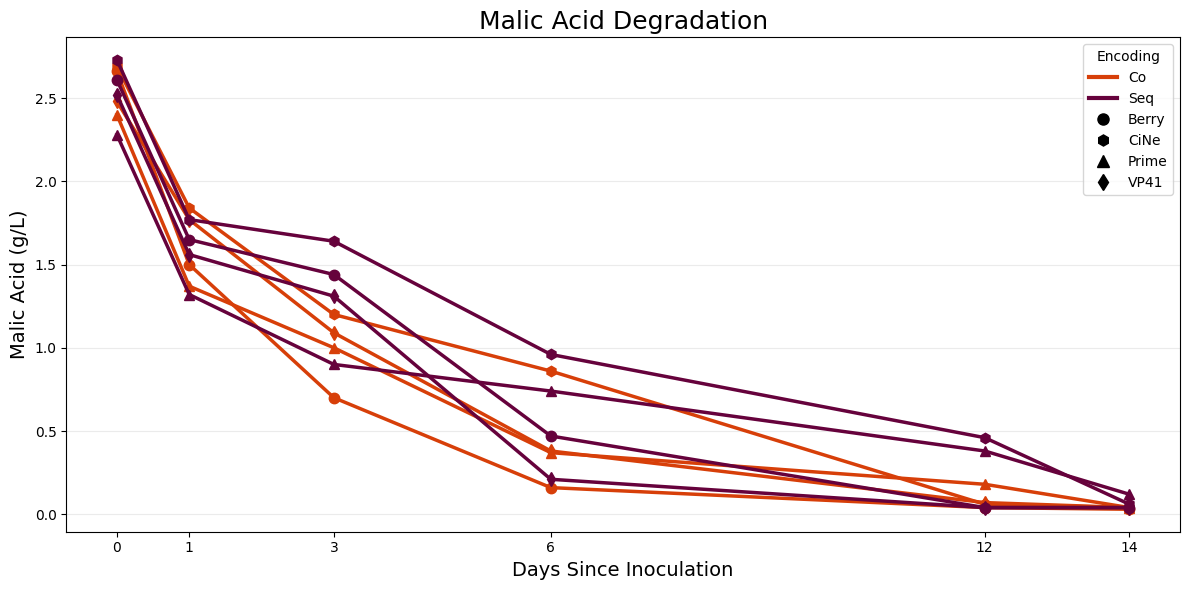

In [13]:

# =========================
# Day-wise data entry helpers
# =========================
co_days: dict[str, list[float]] = {}
seq_days: dict[str, list[float]] = {}

def add_day(day_label: str, co_vals=None, seq_vals=None):
    """
    Add one day's values in inoculum order:
      ["Berry", "CiNe", "Prime", "VP41"]

    Example:
      add_day("D5", co_vals=[...], seq_vals=[...])
    """
    if co_vals is not None:
        if len(co_vals) != len(INOCULUM_ORDER):
            raise ValueError(f"co_vals must have {len(INOCULUM_ORDER)} values (Berry, CiNe, Prime, VP41).")
        co_days[day_label] = co_vals

    if seq_vals is not None:
        if len(seq_vals) != len(INOCULUM_ORDER):
            raise ValueError(f"seq_vals must have {len(INOCULUM_ORDER)} values (Berry, CiNe, Prime, VP41).")
        seq_days[day_label] = seq_vals


def build_dataframes():
    """Build wide dataframes matching your original format."""
    co_malic_data = pd.DataFrame({"Inoculum": INOCULUM_ORDER, **co_days})
    seq_malic_data = pd.DataFrame({"Inoculum": INOCULUM_ORDER, **seq_days})
    return co_malic_data, seq_malic_data


def wide_co_seq_to_long(co_wide: pd.DataFrame, seq_wide: pd.DataFrame) -> pd.DataFrame:
    """Convert your wide Co/Seq tables into a single long dataframe for plotting."""
    def melt_one(wide: pd.DataFrame, timing: str) -> pd.DataFrame:
        m = wide.melt(id_vars="Inoculum", var_name="Day", value_name="Malic")
        m["Days"] = m["Day"].str.extract(r"(\d+)").astype(int)
        m = m.drop(columns="Day").rename(columns={"Inoculum": "Strain"})
        m["Timing"] = timing
        return m

    return pd.concat([melt_one(co_wide, "Co"), melt_one(seq_wide, "Seq")], ignore_index=True)


def plot_malic_co_seq_strain_markers(
    df: pd.DataFrame,
    out_png: str = "Malic_Acid_Degradation.png",
    show_plot: bool = True,
    title: str = "Malic Acid Degradation",
    x_label: str = "Days Since Inoculation",
    y_label: str = "Malic Acid (g/L)",
    legend_loc: str = "upper right",
    linewidth: float = 2.5,
    markersize: float = 7.5,
):
    """
    Plot with encodings:
      - Color: Timing (Co vs Seq)
      - Marker: Strain (Berry, CiNe, Prime, VP41)

    Required columns in df:
      - Days, Malic, Timing, Strain

    Optional columns:
      - Malic_err (symmetric yerr)
    """
    required = {"Days", "Malic", "Timing", "Strain"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"df is missing required columns: {sorted(missing)}")

    d = df.copy()
    d["Timing"] = d["Timing"].astype(str)
    d["Strain"] = d["Strain"].astype(str).str.upper()
    d = d.sort_values(["Timing", "Strain", "Days"])

    fig, ax = plt.subplots(figsize=(12, 6))

    for (timing, strain), g in d.groupby(["Timing", "Strain"], sort=False):
        color = TIMING_COLORS.get(timing, "black")
        marker = LAB_MARKERS.get(strain, "o")

        x = g["Days"].to_numpy()
        y = g["Malic"].to_numpy()

        if "Malic_err" in g.columns:
            yerr = g["Malic_err"].to_numpy()
            ax.errorbar(
                x, y, yerr=yerr,
                color=color,
                marker=marker,
                linestyle="-",
                linewidth=linewidth,
                markersize=markersize,
                capsize=3,
            )
        else:
            ax.plot(
                x, y,
                color=color,
                marker=marker,
                linestyle="-",
                linewidth=linewidth,
                markersize=markersize,
            )

    ax.set_title(title, fontsize=18)
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_xticks(sorted(pd.unique(d["Days"])))
    ax.grid(True, axis="y", alpha=0.25)

    # Legend: color encoding + marker encoding (single box titled "Encoding")
    timing_handles = [
        Line2D([0], [0], color=TIMING_COLORS["Co"], lw=3, label="Co"),
        Line2D([0], [0], color=TIMING_COLORS["Seq"], lw=3, label="Seq"),
    ]
    marker_handles = [
        Line2D([0], [0], color="black", marker=LAB_MARKERS["BERRY"], linestyle="None", markersize=8, label="Berry"),
        Line2D([0], [0], color="black", marker=LAB_MARKERS["CINE"],  linestyle="None", markersize=8, label="CiNe"),
        Line2D([0], [0], color="black", marker=LAB_MARKERS["PRIME"], linestyle="None", markersize=8, label="Prime"),
        Line2D([0], [0], color="black", marker=LAB_MARKERS["VP41"],  linestyle="None", markersize=8, label="VP41"),
    ]
    ax.legend(handles=timing_handles + marker_handles, title="Encoding", loc=legend_loc, frameon=True)

    fig.tight_layout()
    fig.savefig(out_png, dpi=300)

    if show_plot:
        plt.show()
    else:
        plt.close(fig)


# =========================
# Seed with your current data
# (Add more days by adding more add_day(...) lines.)
# =========================
add_day("D0",  co_vals=[2.66, 2.69, 2.40, 2.48], seq_vals=[2.61, 2.73, 2.28, 2.52])
add_day("D1",  co_vals=[1.50, 1.84, 1.37, 1.77], seq_vals=[1.65, 1.77, 1.32, 1.56])
add_day("D3",  co_vals=[0.70, 1.20, 1.00, 1.09], seq_vals=[1.44, 1.64, 0.90, 1.31])
add_day("D6",  co_vals=[0.16, 0.86, 0.37, 0.38], seq_vals=[0.47, 0.96, 0.74, 0.21])
add_day("D12", co_vals=[0.04, 0.06, 0.18, 0.07], seq_vals=[0.04, 0.46, 0.38, 0.04])
add_day("D14", co_vals=[0.03, 0.04, 0.04, 0.04], seq_vals=[0.04, 0.06, 0.12, 0.04])

co_malic_data, seq_malic_data = build_dataframes()

# =========================
# Convert + plot
# =========================
df_long = wide_co_seq_to_long(co_malic_data, seq_malic_data)

plot_malic_co_seq_strain_markers(
    df_long,
    out_png="2024_Malic_Co_vs_Seq_Timecourse_Days.png",
    show_plot=True
)

# Brix plotting

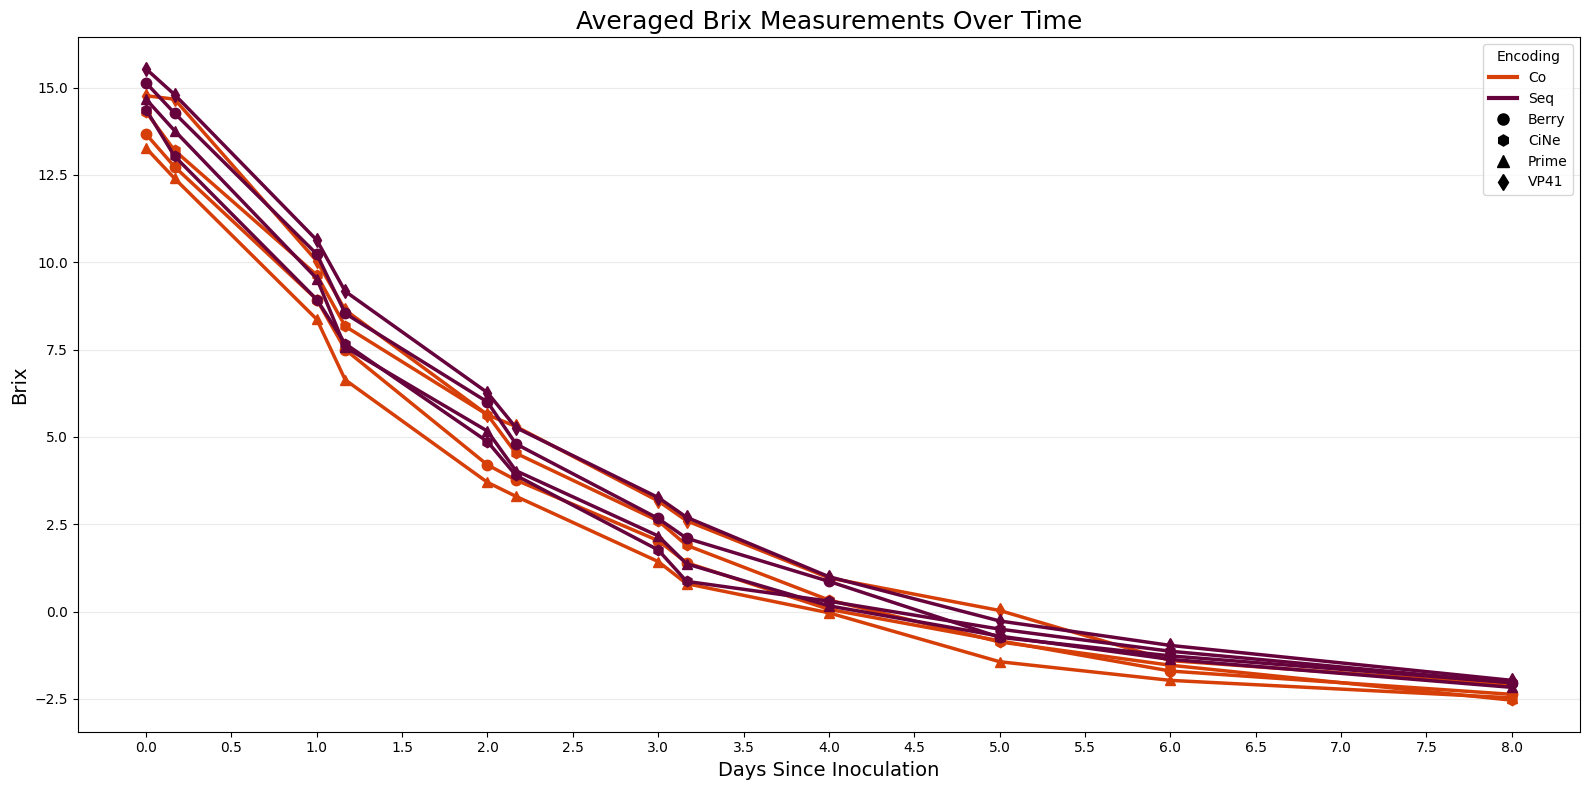

In [12]:
# -------------------------
# Configuration
# -------------------------
FILE_PATH = str(BRIX_FILE)
INOCULUM_MAP = INOCULUM_ORDER
# -------------------------
# Helper functions
# -------------------------
def sheet_name_to_hours(sheet_name: str, start_time: datetime) -> float:
    """Convert sheet name timestamp to hours since start."""
    dt = datetime.strptime(sheet_name, "%m.%d.%y.%H%M")
    return (dt - start_time).total_seconds() / 3600


def load_sheet_data(xls: pd.ExcelFile, sheet_name: str, hours: float) -> pd.DataFrame:
    """Load and clean a single sheet. Expected columns after skiprows: Index, Berry_ID, Co, Seq."""
    df = pd.read_excel(xls, sheet_name=sheet_name, skiprows=2)

    # Defensive handling in case Excel has extra unnamed columns
    df = df.iloc[:, :4].copy()
    df.columns = ["Index", "Berry_ID", "Co", "Seq"]

    df = (
        df.drop(columns="Index")
          .dropna(subset=["Berry_ID"])
          .assign(Hours=hours)
          .reset_index(drop=True)
    )
    return df


def build_encoding_legend(ax, legend_loc: str = "upper right"):
    """Single legend block with color (timing) + marker (strain) encodings."""
    timing_handles = [
        Line2D([0], [0], color=TIMING_COLORS["Co"], lw=3, label="Co"),
        Line2D([0], [0], color=TIMING_COLORS["Seq"], lw=3, label="Seq"),
    ]
    marker_handles = [
        Line2D([0], [0], color="black", marker=LAB_MARKERS["BERRY"], linestyle="None", markersize=8, label="Berry"),
        Line2D([0], [0], color="black", marker=LAB_MARKERS["CINE"],  linestyle="None", markersize=8, label="CiNe"),
        Line2D([0], [0], color="black", marker=LAB_MARKERS["PRIME"], linestyle="None", markersize=8, label="Prime"),
        Line2D([0], [0], color="black", marker=LAB_MARKERS["VP41"],  linestyle="None", markersize=8, label="VP41"),
    ]
    ax.legend(handles=timing_handles + marker_handles, title="Encoding", loc=legend_loc, frameon=True)


# -------------------------
# Load Excel & compute hours
# -------------------------
xls = pd.ExcelFile(FILE_PATH)

sheet_times = [datetime.strptime(s, "%m.%d.%y.%H%M") for s in xls.sheet_names]
start_time = min(sheet_times)

sheet_hours = {name: sheet_name_to_hours(name, start_time) for name in xls.sheet_names}


# -------------------------
# Read and combine all sheets
# -------------------------
all_data = [load_sheet_data(xls, sheet, sheet_hours[sheet]) for sheet in xls.sheet_names]
combined_df = pd.concat(all_data, ignore_index=True)

# -------------------------
# Assign inoculum groups
# -------------------------
# Extract the inoculum token from Berry_ID (adjust regex if needed)
combined_df["Inoculum_raw"] = combined_df["Berry_ID"].astype(str).str.extract(r"([A-Za-z]+[0-9]*)")[0]

combined_df["Inoculum"] = combined_df["Inoculum_raw"].map(INOCULUM_MAP)
combined_df = combined_df.dropna(subset=["Inoculum"])

# Normalize for marker lookup
combined_df["Inoculum_U"] = combined_df["Inoculum"].astype(str).str.upper()


## -------------------------
# Reshape to long and average replicates
# -------------------------
long_df = combined_df.melt(
    id_vars=["Berry_ID", "Hours", "Inoculum", "Inoculum_U"],
    value_vars=["Co", "Seq"],
    var_name="Timing",
    value_name="Brix"
).dropna(subset=["Brix"])

# Convert hours → days
long_df["Days"] = long_df["Hours"] / 24.0

# Average replicates across Berry_ID within inoculum/timing/day
avg_df = (
    long_df
    .groupby(["Inoculum", "Inoculum_U", "Timing", "Days"], as_index=False)
    .agg(Brix=("Brix", "mean"))
    .sort_values(["Timing", "Inoculum", "Days"])
)

# -------------------------
# Plot (days on x-axis)
#   - Color: Timing (Co vs Seq)
#   - Marker: Inoculum strain
# -------------------------
fig, ax = plt.subplots(figsize=(16, 8))

for (timing, inoculum_u), g in avg_df.groupby(["Timing", "Inoculum_U"], sort=False):
    g = g.sort_values("Days")

    ax.plot(
        g["Days"],
        g["Brix"],
        color=TIMING_COLORS.get(timing, "black"),
        marker=LAB_MARKERS.get(inoculum_u, "o"),
        linestyle="-",
        linewidth=2.5,
        markersize=7.5,
    )

ax.set_xlabel("Days Since Inoculation", fontsize=14)
ax.set_ylabel("Brix", fontsize=14)
ax.set_title("Averaged Brix Measurements Over Time", fontsize=18)
ax.grid(True, axis="y", alpha=0.25)

# --- half-day tick control ---
min_day = avg_df["Days"].min()
max_day = avg_df["Days"].max()

xticks = np.arange(
    np.floor(min_day * 2) / 2,
    np.ceil(max_day * 2) / 2 + 0.25,
    0.5
)
ax.set_xticks(xticks)


build_encoding_legend(ax, legend_loc="upper right")

fig.tight_layout()
fig.savefig(
    "2024_Brix_Co_vs_Seq_Timecourse_Days.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# Acetaldehyde Analysis and Ploting

C:\Users\cinde\AppData\Local\Temp\ipykernel_68240\1948360744.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby([TIMEPOINT_COL, TIMING_COL, STRAIN_COL])[Y_COL]
C:\Users\cinde\AppData\Local\Temp\ipykernel_68240\1948360744.py:298: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(ncol=2, frameon=False)


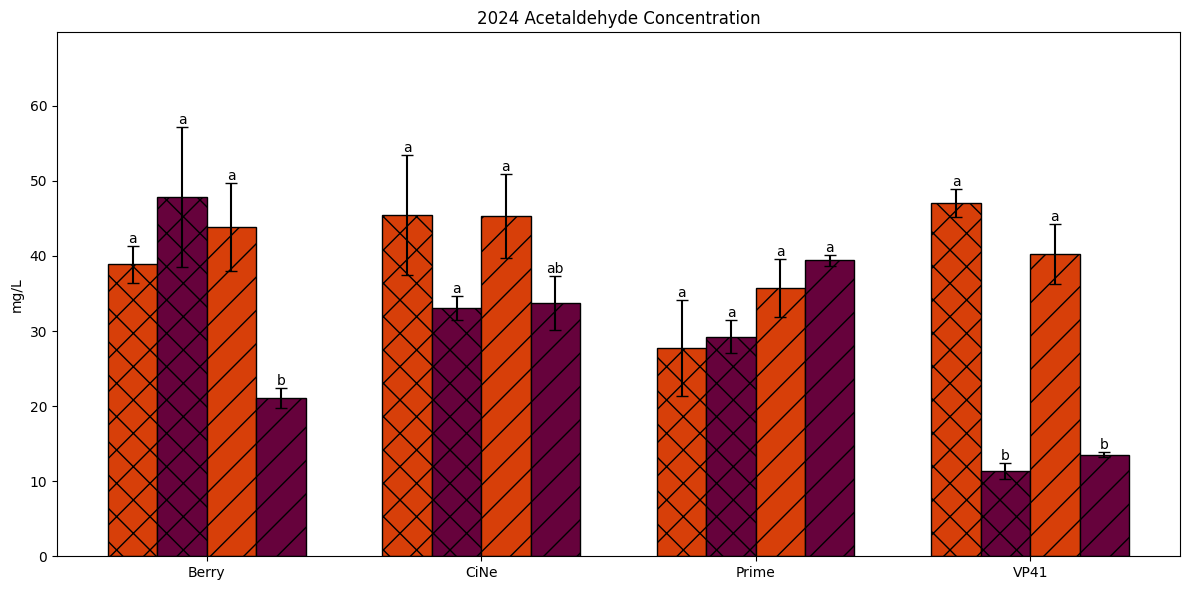

In [11]:
Y_COL = "Acetaldehyde"
TIMEPOINT_COL = "Timepoint"
TIMING_COL = "Timing"
STRAIN_COL = "Strain"
REP_COL = "Rep"

TIMEPOINT_ORDER = ["EndMLF", "Bottle"]

ANOVA_CSV = str(TABLE_DIR / "acet2024_timepoint_anova.csv")
TUKEY_CSV = str(TABLE_DIR / "acet2024_timepoint_tukey.csv")
CLD_CSV = str(TABLE_DIR / "acet2024_timepoint_cld.csv")
BIO_STATS_CSV = str(TABLE_DIR /  "acet2024_timepoint_bio_stats_mean_sem.csv")
PLOT_PNG = str(FIGURE_DIR / "acet2024_timepoint_sem_cld.png")

# ============================================================
# END OF MLF INPUT TABLE
# ============================================================
endmlf_bio_mean = {
    "CO_BERRY": [42.89, 39.23, 34.50],
    "CO_CINE":  [32.36, 60.09, 43.95],
    "CO_PRIME": [23.81, 19.26, 40.21],
    "CO_VP41":  [43.33, 49.39, 48.50],
    "SEQ_BERRY": [64.82, 46.18, 32.63],
    "SEQ_CINE":  [30.40, 35.84, 33.07],
    "SEQ_PRIME": [25.86, 33.52, 28.44],
    "SEQ_VP41":  [9.36, 13.02, 11.59],
}

# ============================================================
# BOTTLE INPUT
# ============================================================
bottle_bio_means = {
    "CO_BERRY": [54.83, 42.08, 34.77],
    "CO_CINE":  [34.24, 52.24, 49.39],
    "CO_PRIME": [32.9, 43.42, 31.03],
    "CO_VP41":  [43.06, 32.28, 45.47],
    "SEQ_BERRY": [21.40, 18.64, 23.18],
    "SEQ_CINE":  [32.27, 28.44, 40.56],
    "SEQ_PRIME": [38.07, 40.48, 39.76],
    "SEQ_VP41":  [13.82, 14.00, 12.84],
}
# ============================================================

# -------------------------
# Helpers
# -------------------------

def parse_compact_treatment(label):
    """
    Convert labels like:
        CoBerry  -> CO, BERRY
        CoCiNe   -> CO, CINE
        SeqPrime -> SEQ, PRIME
        SeqVP41  -> SEQ, VP41
    """
    s = str(label).strip()

    timing_match = re.match(r"^(Co|Seq)", s, flags=re.IGNORECASE)
    if not timing_match:
        raise ValueError(f"Could not parse timing from label: {label}")

    timing_raw = timing_match.group(1).upper()
    timing = "CO" if timing_raw == "CO" else "SEQ"

    strain_raw = s[timing_match.end():].strip()
    strain_key = strain_raw.upper()

    # Normalize common spelling/case variants
    strain_map = {
        "BERRY": "BERRY",
        "CINE": "CINE",
        "PRIME": "PRIME",
        "VP41": "VP41",
    }

    if strain_key not in strain_map:
        raise ValueError(f"Could not parse strain from label: {label}")

    strain = strain_map[strain_key]
    return timing, strain


def long_from_raw_dict(raw_dict, timepoint):
    rows = []
    for treatment, values in raw_dict.items():
        timing, strain = treatment.split("_")
        for rep, value in enumerate(values, start=1):
            rows.append({
                TIMEPOINT_COL: timepoint,
                "Treatment": f"{timepoint}_{timing}_{strain}",
                "Cell": f"{timepoint}_{timing}_{strain}",
                TIMING_COL: timing,
                STRAIN_COL: strain,
                REP_COL: rep,
                Y_COL: float(value),
            })
    return pd.DataFrame(rows)


def long_from_bottle_input(bottle_input, timepoint="Bottle"):
    """
    Accepts either:
      1) dict: {"CoBerry": [.., .., ..], ...}
      2) dataframe with treatment labels + replicate values

    Returns long dataframe with one row per biological replicate mean.
    """
    rows = []

    if isinstance(bottle_input, dict):
        for treatment, values in bottle_input.items():
            timing, strain = parse_compact_treatment(treatment)
            for rep, value in enumerate(values, start=1):
                rows.append({
                    TIMEPOINT_COL: timepoint,
                    "Treatment": f"{timepoint}_{timing}_{strain}",
                    "Cell": f"{timepoint}_{timing}_{strain}",
                    TIMING_COL: timing,
                    STRAIN_COL: strain,
                    REP_COL: rep,
                    Y_COL: float(value),
                })
        return pd.DataFrame(rows)

    if isinstance(bottle_input, pd.DataFrame):
        df_in = bottle_input.copy()

        # Try to infer columns
        cols_lower = {c.lower(): c for c in df_in.columns}

        treatment_col = None
        value_col = None
        rep_col = None

        for c in df_in.columns:
            cl = c.lower()
            if cl in ["treatment", "sample", "group"]:
                treatment_col = c
            elif cl in ["rep", "replicate", "bio_rep", "biorep"]:
                rep_col = c
            elif cl in ["acetaldehyde", "mg/l", "value", "mean"]:
                value_col = c

        if treatment_col is None or value_col is None:
            raise ValueError(
                "Bottle dataframe must contain treatment/sample and value columns."
            )

        if rep_col is None:
            # assign replicate order within treatment if rep not provided
            df_in["_rep_auto"] = df_in.groupby(treatment_col).cumcount() + 1
            rep_col = "_rep_auto"

        for _, r in df_in.iterrows():
            timing, strain = parse_compact_treatment(r[treatment_col])
            rows.append({
                TIMEPOINT_COL: timepoint,
                "Treatment": f"{timepoint}_{timing}_{strain}",
                "Cell": f"{timepoint}_{timing}_{strain}",
                TIMING_COL: timing,
                STRAIN_COL: strain,
                REP_COL: int(r[rep_col]),
                Y_COL: float(r[value_col]),
            })

        return pd.DataFrame(rows)

    raise TypeError("bottle_bio_means must be either a dict or a pandas DataFrame.")


def tukey_df_from_result(res):
    tdf = pd.DataFrame(res._results_table.data[1:], columns=res._results_table.data[0])
    tdf.columns = [str(c).strip() for c in tdf.columns]
    return tdf


def cld_from_tukey(tukey_df, groups, reject_col="reject"):
    groups = list(groups)
    idx = {g: i for i, g in enumerate(groups)}
    n = len(groups)

    not_diff = np.ones((n, n), dtype=bool)
    np.fill_diagonal(not_diff, True)

    for _, r in tukey_df.iterrows():
        g1 = str(r["group1"])
        g2 = str(r["group2"])
        rej = r[reject_col]
        rej_bool = (str(rej).strip().lower() == "true") if isinstance(rej, str) else bool(rej)
        i, j = idx[g1], idx[g2]
        not_diff[i, j] = not rej_bool
        not_diff[j, i] = not rej_bool

    alphabet = list("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ")
    letters = []
    assign = {g: "" for g in groups}

    def can_share(g, letter):
        gi = idx[g]
        for other in groups:
            if other == g:
                continue
            if letter in assign[other]:
                oi = idx[other]
                if not not_diff[gi, oi]:
                    return False
        return True

    for g in groups:
        got_one = False
        for letter in letters:
            if can_share(g, letter):
                assign[g] += letter
                got_one = True
        if not got_one:
            if len(letters) >= len(alphabet):
                raise RuntimeError("CLD ran out of letters; expand alphabet.")
            new = alphabet[len(letters)]
            letters.append(new)
            assign[g] += new

    return pd.DataFrame({"Cell": groups, "CLD": [assign[g] for g in groups]})


def mean_sem_by_cell(df):
    g = df.groupby([TIMEPOINT_COL, TIMING_COL, STRAIN_COL])[Y_COL]
    out = g.agg(["mean", "std", "count"]).reset_index()
    out["sem"] = out["std"] / np.sqrt(out["count"].replace(0, np.nan))
    out = out.rename(columns={"count": "n_bio"})
    return out[[TIMEPOINT_COL, TIMING_COL, STRAIN_COL, "mean", "sem", "n_bio"]]


def plot_acetaldehyde_grouped(stats, cld_df, out_png, show_plot=True):
    x = np.arange(len(INOCULUM_ORDER))
    width = 0.18

    fig, ax = plt.subplots(figsize=(12, 6))

    combo_order = [
        ("EndMLF", "CO"),
        ("EndMLF", "SEQ"),
        ("Bottle", "CO"),
        ("Bottle", "SEQ"),
    ]
    offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width]

    letter_map = dict(zip(cld_df["Cell"].astype(str), cld_df["CLD"].astype(str)))

    ymax_candidates = []

    for (timepoint, timing), offset in zip(combo_order, offsets):
        sub = stats[
            (stats[TIMEPOINT_COL] == timepoint) &
            (stats[TIMING_COL] == timing)
        ].set_index(STRAIN_COL)

        means = np.array([sub.loc[s, "mean"] if s in sub.index else np.nan for s in INOCULUM_ORDER], float)
        sems  = np.array([sub.loc[s, "sem"] if s in sub.index else np.nan for s in INOCULUM_ORDER], float)

        color = CO_COLOR if timing == "CO" else SEQ_COLOR
        hatch = TIMEPOINT_HATCH[timepoint]

        bars = ax.bar(
            x + offset,
            means,
            width,
            yerr=sems,
            capsize=4,
            color=color,
            edgecolor="black",
            hatch=hatch
        )

        ymax_candidates.extend(list(means + sems))

        for i, strain in enumerate(INOCULUM_ORDER):
            cell = f"{timepoint}_{timing}_{strain}"
            y = means[i] + sems[i]
            if np.isfinite(y):
                ax.text(
                    x[i] + offset,
                    y,
                    letter_map.get(cell, ""),
                    ha="center",
                    va="bottom",
                    fontsize=10,
                )

    ymax = np.nanmax(ymax_candidates) if len(ymax_candidates) else 1.0
    if not np.isfinite(ymax) or ymax <= 0:
        ymax = 1.0

    ax.set_ylim(0, ymax * 1.22)
    ax.set_xticks(x)
    ax.set_xticklabels([STRAIN_LABELS[s] for s in INOCULUM_ORDER])
    ax.set_ylabel("mg/L")
    ax.set_title("2024 Acetaldehyde Concentration")
    ax.legend(ncol=2, frameon=False)

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)


# ============================================================
# BUILD DATAFRAME
# ============================================================

df_endmlf = long_from_raw_dict(endmlf_bio_mean, timepoint="EndMLF")
df_bottle = long_from_raw_dict(bottle_bio_means, timepoint="Bottle")
df = pd.concat([df_endmlf, df_bottle], ignore_index=True)

# Canonical factor framing
df[TIMEPOINT_COL] = pd.Categorical(df[TIMEPOINT_COL], categories=TIMEPOINT_ORDER, ordered=True)
df[TIMING_COL] = pd.Categorical(df[TIMING_COL], categories=TIMING_ORDER_UPPER, ordered=True)
df[STRAIN_COL] = pd.Categorical(df[STRAIN_COL], categories=INOCULUM_ORDER, ordered=True)

cell_order = [
    f"{tp}_{tm}_{st}"
    for tp in TIMEPOINT_ORDER
    for st in INOCULUM_ORDER
    for tm in TIMING_ORDER_UPPER
]
df["Cell"] = pd.Categorical(df["Cell"].astype(str), categories=cell_order, ordered=True)
df["Treatment"] = df["Cell"]

# Sanity check
expected_n = 48
assert len(df) == expected_n, f"Expected {expected_n} rows, found {len(df)}"

# ============================================================
# MAIN ANALYSIS
# ============================================================

def run_acetaldehyde_2024_multitime(show_plot=True):
    analysis_df = df.copy()

    formula = f"{Y_COL} ~ C({TIMEPOINT_COL}) * C({TIMING_COL}) * C({STRAIN_COL})"
    model = smf.ols(formula, data=analysis_df).fit()
    aov = anova_lm(model, typ=ANOVA_TYPE)

    tuk = pairwise_tukeyhsd(
        analysis_df[Y_COL].values,
        analysis_df["Cell"].astype(str).values,
        alpha=ALPHA
    )
    tukey_df = tukey_df_from_result(tuk)

    cld_df = cld_from_tukey(tukey_df, cell_order)
    stats = mean_sem_by_cell(analysis_df)

    aov.to_csv(ANOVA_CSV)
    tukey_df.to_csv(TUKEY_CSV, index=False)
    cld_df.to_csv(CLD_CSV, index=False)
    stats.to_csv(BIO_STATS_CSV, index=False)

    report_path = init_report(
        ACETALDEHYDE_REPORT,
        "Acetaldehyde Analysis (2024 Pinot)",
        metadata={
            "Section": "End of MLF vs bottle acetaldehyde",
            "Model": f"Three-way ANOVA (Type {ANOVA_TYPE}) followed by Tukey HSD on Cell",
            "Output figure": str(PLOT_PNG),
        },
    )
    append_report_section(report_path, "[ANOVA RESULTS]")
    append_report_df(report_path, aov)
    append_report_section(report_path, "[SUMMARY TABLES]")
    append_report_df(report_path, stats, index=False)
    append_report_section(report_path, "[COMPACT LETTER DISPLAY]")
    append_report_df(report_path, cld_df, index=False)
    append_report_section(report_path, "[POST HOC TABLE]")
    append_report_df(report_path, tukey_df, index=False)

    plot_acetaldehyde_grouped(
        stats=stats,
        cld_df=cld_df,
        out_png=PLOT_PNG,
        show_plot=show_plot
    )

    append_report_section(report_path, "[OUTPUTS]")
    append_report_text(report_path, f"Saved figure: {PLOT_PNG}")

    return {
        "data": analysis_df,
        "anova": aov,
        "tukey": tukey_df,
        "cld": cld_df,
        "stats": stats,
    }

res2024_acet = run_acetaldehyde_2024_multitime(show_plot=True)

# Volatile acidity (acetic acid) Pipeline


=== SANITY CHECK: Long-format data ===
  Group Condition  Score
0    Co     Berry   0.74
1    Co     Berry   0.78
2    Co     Berry   0.79
3   Seq     Berry   0.57
4   Seq     Berry   0.49

=== TWO-WAY ANOVA ===
                         sum_sq    df          F    PR(>F)
C(Group)               0.041667   1.0  19.841270  0.000400
C(Condition)           0.096500   3.0  15.317460  0.000058
C(Group):C(Condition)  0.052633   3.0   8.354497  0.001433
Residual               0.033600  16.0        NaN       NaN

=== COMPACT LETTER DISPLAY (CLD) ===
   Treatment CLD
0   Co_Berry   a
1    Co_CiNe   b
2   Co_Prime   b
3    Co_VP41   a
4  Seq_Berry   b
5   Seq_CiNe   b
6  Seq_Prime   b
7   Seq_VP41   b

Saving figure to: C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\figures\volatile_acidity_cld.png


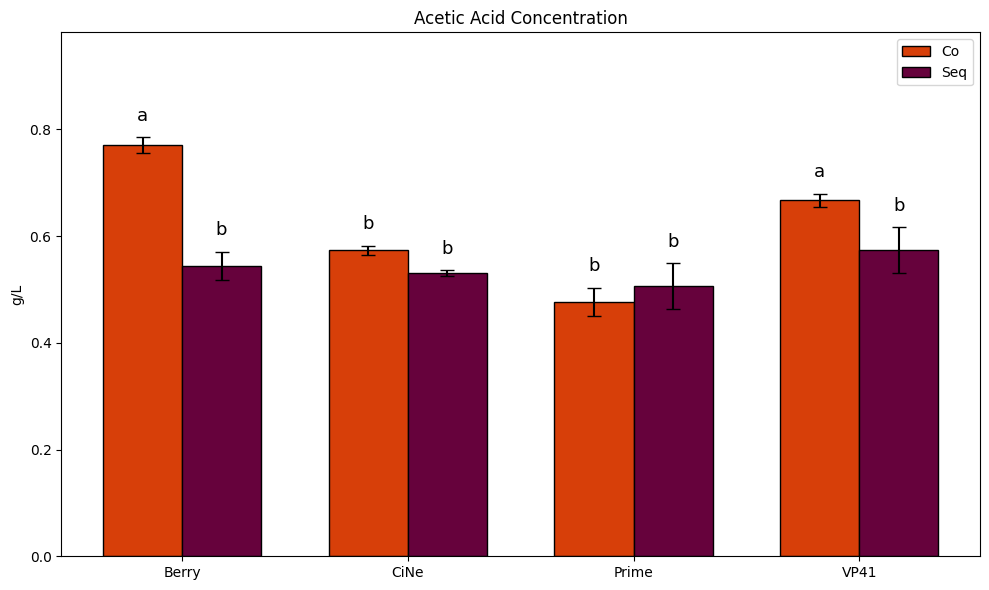

In [7]:
# =========================
#: define dataset → long-format reshape → ANOVA/Tukey CLD → barplot export
# =========================

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

def plot_acetic_acid_cld_barplot(
    out_png=VOLATILE_ACIDITY_PNG,
    show_plot=True
):
    # =========================
    # Step 1: Input data
    # =========================
    co_data = {
        "Group": ["Co"] * 3,
        "Berry": [0.74, 0.78, 0.79],
        "CiNe": [0.56, 0.59, 0.57],
        "Prime": [0.53, 0.45, 0.45],
        "VP41": [0.69, 0.65, 0.66]
    }

    seq_data = {
        "Group": ["Seq"] * 3,
        "Berry": [0.57, 0.49, 0.57],
        "CiNe": [0.53, 0.54, 0.52],
        "Prime": [0.59, 0.48, 0.45],
        "VP41": [0.53, 0.53, 0.66]
    }

    df = pd.concat(
        [pd.DataFrame(co_data), pd.DataFrame(seq_data)],
        ignore_index=True
    )

    # =========================
    # Step 2: Long format
    # =========================
    df_long = df.melt(
        id_vars="Group",
        var_name="Condition",
        value_name="Score"
    )

    print("\n=== SANITY CHECK: Long-format data ===")
    print(df_long.head())

    # =========================
    # Step 3: Two-way ANOVA
    # =========================
    model = ols("Score ~ C(Group) * C(Condition)", data=df_long).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    print("\n=== TWO-WAY ANOVA ===")
    print(anova_table)

    report_path = init_report(
        VOLATILE_ACIDITY_REPORT,
        "Volatile Acidity Analysis (2024 Pinot)",
        metadata={
            "Section": "Volatile acidity / acetic acid",
            "Model": "Two-way ANOVA followed by Tukey HSD and compact letter display",
            "Output figure": str(out_png),
        },
    )
    append_report_section(report_path, "[ANOVA RESULTS]")
    append_report_df(report_path, anova_table)

    # =========================
    # Step 4: Tukey HSD + CLD
    # =========================
    df_long["CondGrp"] = df_long["Group"] + "_" + df_long["Condition"]
    mc = MultiComparison(df_long["Score"], df_long["CondGrp"])
    hsd = mc.tukeyhsd(alpha=0.05)

    tukey_df = pd.DataFrame(
        hsd._results_table.data[1:],
        columns=hsd._results_table.data[0]
    )

    groups = mc.groupsunique
    k = len(groups)
    sig = np.zeros((k, k), dtype=bool)

    for i, g1 in enumerate(groups):
        for j, g2 in enumerate(groups):
            if i >= j:
                continue
            row = tukey_df[
                ((tukey_df.group1 == g1) & (tukey_df.group2 == g2)) |
                ((tukey_df.group1 == g2) & (tukey_df.group2 == g1))
            ]
            sig[i, j] = sig[j, i] = row.reject.values[0]

    letters = [""] * k
    remaining = set(range(k))
    current_letter = ord("a")

    while remaining:
        group = []
        for idx in sorted(remaining):
            if all(not sig[idx, j] for j in group):
                letters[idx] += chr(current_letter)
                group.append(idx)
        remaining -= set(group)
        current_letter += 1

    cld_df = pd.DataFrame({
        "Treatment": groups,
        "CLD": letters
    })

    print("\n=== COMPACT LETTER DISPLAY (CLD) ===")
    print(cld_df)
    append_report_section(report_path, "[COMPACT LETTER DISPLAY]")
    append_report_df(report_path, cld_df, index=False)

    # =========================
    # Step 5: Summary stats
    # =========================
    stats = (
        df_long
        .groupby(["Group", "Condition"])["Score"]
        .agg(["mean", "sem"])
        .unstack("Group")
    )

    inocula = ["Berry", "CiNe", "Prime", "VP41"]
    x = np.arange(len(inocula))
    width = 0.35

    co_mean = stats["mean"]["Co"].reindex(inocula)
    seq_mean = stats["mean"]["Seq"].reindex(inocula)
    co_sem = stats["sem"]["Co"].reindex(inocula)
    seq_sem = stats["sem"]["Seq"].reindex(inocula)

    append_report_section(report_path, "[SUMMARY STATISTICS]")
    append_report_df(report_path, stats)

    # =========================
    # Step 6: Plot
    # =========================
    fig, ax = plt.subplots(figsize=(10, 6))

    bars_co = ax.bar(
        x - width / 2, co_mean, width,
        yerr=co_sem, capsize=5,
        label="Co", color="#D73F09", edgecolor="black"
    )

    bars_seq = ax.bar(
        x + width / 2, seq_mean, width,
        yerr=seq_sem, capsize=5,
        label="Seq", color="#66023c", edgecolor="black"
    )

    ymax = max(
        (co_mean + co_sem).max(),
        (seq_mean + seq_sem).max()
    )

    ax.set_ylim(0, ymax * 1.25)

    letter_map = dict(zip(cld_df.Treatment, cld_df.CLD))
    offset = ymax * 0.03

    for i, cond in enumerate(inocula):
        ax.text(
            x[i] - width / 2,
            co_mean[i] + co_sem[i] + offset,
            letter_map[f"Co_{cond}"],
            ha="center", va="bottom", fontsize=13
        )
        ax.text(
            x[i] + width / 2,
            seq_mean[i] + seq_sem[i] + offset,
            letter_map[f"Seq_{cond}"],
            ha="center", va="bottom", fontsize=13
        )

    ax.set_xticks(x)
    ax.set_xticklabels(inocula)
    ax.set_ylabel("g/L")
    ax.set_title("Acetic Acid Concentration")
    ax.legend()

    plt.tight_layout()

    # =========================
    # Step 7: Output
    # =========================
    print(f"\nSaving figure to: {out_png}")
    savefig_standard(fig, out_png, dpi=300)
    append_report_section(report_path, "[OUTPUTS]")
    append_report_text(report_path, f"Saved figure: {out_png}")

    if show_plot:
        plt.show()
    else:
        plt.close()

def main():
    plot_acetic_acid_cld_barplot(
        out_png=VOLATILE_ACIDITY_PNG,
        show_plot=True
    )

if __name__ == "__main__":
    main()

# Harbertson–Adams Protein Precipitation Assay Analysis and Plotting


Three-Way ANOVA Results:
                                          sum_sq    df         F    PR(>F)
C(Timepoint)                          99.949499   1.0  0.799805  0.377829
C(Group)                             111.700007   1.0  0.893834  0.351525
C(Condition)                         207.390928   3.0  0.553187  0.649722
C(Timepoint):C(Group)                 10.844052   1.0  0.086775  0.770220
C(Timepoint):C(Condition)            504.696313   3.0  1.346209  0.276819
C(Group):C(Condition)               1188.110671   3.0  3.169123  0.037573
C(Timepoint):C(Group):C(Condition)   496.465664   3.0  1.324254  0.283650
Residual                            3998.955021  32.0       NaN       NaN

Compact Letter Display (CLD):
       Treatment CLD
     9M_Co_Berry   a
      9M_Co_CiNe   a
     9M_Co_Prime   a
      9M_Co_VP41   a
    9M_Seq_Berry   a
     9M_Seq_CiNe   a
    9M_Seq_Prime   a
     9M_Seq_VP41   a
 Bottle_Co_Berry   a
  Bottle_Co_CiNe   a
 Bottle_Co_Prime   a
  Bottle_Co_VP41   a
Bot

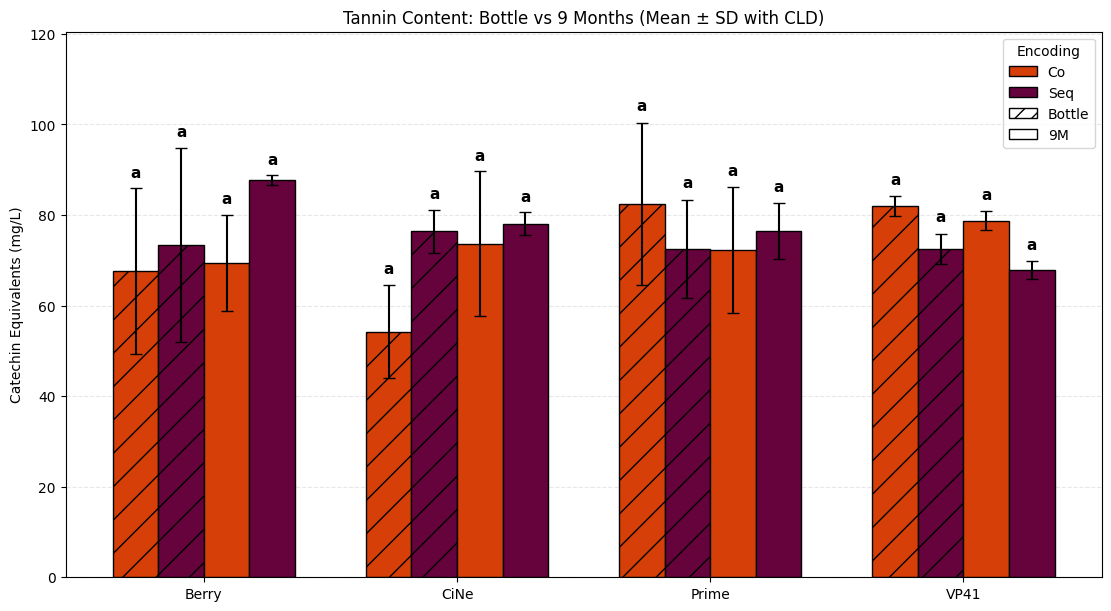

In [18]:
# =========================
# Tannin (post-bottle aging): load data → 3-way ANOVA → Tukey CLD → grouped barplot (bottle/9M styling) + export
# =========================

# =====================================================
# Styling
# =====================================================
# Bottle hatched, 9M solid
HATCH_MAP = TIMEPOINT_HATCH
# =====================================================
# Data setup
# =====================================================
def load_data() -> pd.DataFrame:
    """
    Return long dataframe with columns:
      Timepoint, Group, Condition, Score, CondGrp
    where CondGrp uniquely identifies each bar (for Tukey/CLD):
      f"{Timepoint}_{Group}_{Condition}"
    """

    # ----------------------------
    # Bottle data T0
    # ----------------------------
    bottle_co = {
        "Berry": [86.04081633, 67.67346939, 49.30612245],
        "CiNe":  [42.36734694, 60.63265306, 59.61224490],
        "Prime": [72.46938776, 71.65306122, 103.18367347],
        "VP41":  [79.91836735, 81.95918368, 84.20408163],
    }

    bottle_seq = {
        "Berry": [90.73469388, 49.30612245, 80.12244898],
        "CiNe":  [81.04081633, 76.65306123, 71.44897959],
        "Prime": [64.40816327, 84.81632653, 68.28571429],
        "VP41":  [76.14285714, 69.51020408, 71.75510204],
    }

    # ----------------------------
    # 9M data T9
    # ----------------------------
    aged_co = {
        "Berry": [80.69811321, 67.96226416, 59.66037736],
        "CiNe":  [55.22641509, 82.77358491, 82.96226415],
        "Prime": [62.39622641, 66.07547170, 88.15094340],
        "VP41":  [81.16981132, 77.20754717, 77.96226415],
    }

    aged_seq = {
        "Berry": [88.43396227, 86.54716981, 88.15094340],
        "CiNe":  [80.60377358, 77.96226416, 75.60377359],
        "Prime": [69.94339623, 82.11320755, 77.30188680],
        "VP41":  [66.64150943, 70.13207547, 66.83018868],
    }

    def _wide_from_dict(d: dict, group: str, timepoint: str) -> pd.DataFrame:
        df = pd.DataFrame(d)
        df["Group"] = group
        df["Timepoint"] = timepoint
        return df

    df = pd.concat(
        [
            _wide_from_dict(bottle_co, "Co", "Bottle"),
            _wide_from_dict(bottle_seq, "Seq", "Bottle"),
            _wide_from_dict(aged_co, "Co", "9M"),
            _wide_from_dict(aged_seq, "Seq", "9M"),
        ],
        ignore_index=True
    )

    df_long = df.melt(
        id_vars=["Timepoint", "Group"],
        var_name="Condition",
        value_name="Score"
    )

    # Unique label per bar for Tukey/CLD
    df_long["CondGrp"] = df_long["Timepoint"] + "_" + df_long["Group"] + "_" + df_long["Condition"]
    return df_long


# =====================================================
# Statistics
# =====================================================
def run_three_way_anova(df_long: pd.DataFrame) -> pd.DataFrame:
    """
    Three-way ANOVA because we now have Timepoint, Group, Condition.
    """
    model = ols("Score ~ C(Timepoint) * C(Group) * C(Condition)", data=df_long).fit()
    return sm.stats.anova_lm(model, typ=2)


def run_tukey_cld(df_long: pd.DataFrame, alpha: float = 0.05) -> pd.DataFrame:
    """
    Tukey HSD across all bars (CondGrp) then compact letter display.
    """
    mc = MultiComparison(df_long["Score"], df_long["CondGrp"])
    hsd = mc.tukeyhsd(alpha=alpha)

    tukey_df = pd.DataFrame(hsd._results_table.data[1:], columns=hsd._results_table.data[0])

    groups = mc.groupsunique
    k = len(groups)
    sig = np.zeros((k, k), dtype=bool)

    for i, g1 in enumerate(groups):
        for j in range(i + 1, k):
            g2 = groups[j]
            row = tukey_df[
                ((tukey_df.group1 == g1) & (tukey_df.group2 == g2)) |
                ((tukey_df.group1 == g2) & (tukey_df.group2 == g1))
            ]
            sig[i, j] = sig[j, i] = bool(row.reject.values[0])

    letters = [""] * k
    cur = ord("a")
    remaining = set(range(k))

    while remaining:
        bucket = []
        for idx in sorted(remaining):
            if all(not sig[idx, j] for j in bucket):
                letters[idx] += chr(cur)
                bucket.append(idx)
        remaining -= set(bucket)
        cur += 1

    return pd.DataFrame({"Treatment": groups, "CLD": letters})


# =====================================================
# Plotting 
# =====================================================
def plot_tannin_bars(df_long: pd.DataFrame, cld_df: pd.DataFrame, out_png: str = "tannin_bottle_vs_9m.png") -> None:
    """
    Bar plot grouped by Condition, showing:
      Bottle-Co, Bottle-Seq (hatched)
      9M-Co,     9M-Seq     (solid)
    Error bars = SD.
    CLD letters displayed per bar (CondGrp).
    """

    labels = ["Berry", "CiNe", "Prime", "VP41"]
    timepoints = ["Bottle", "9M"]
    groups = ["Co", "Seq"]

    # Summary stats (mean, SD)
    stats = (
        df_long
        .groupby(["Timepoint", "Group", "Condition"])["Score"]
        .agg(mean="mean", sd="std")
        .reset_index()
    )

    # CLD lookup
    cld_dict = dict(zip(cld_df["Treatment"], cld_df["CLD"]))

    # Bar geometry: 4 bars per condition
    x = np.arange(len(labels))
    width = 0.18
    offsets = {
        ("Bottle", "Co"): -1.5 * width,
        ("Bottle", "Seq"): -0.5 * width,
        ("9M", "Co"):  0.5 * width,
        ("9M", "Seq"): 1.5 * width,
    }

    fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

    # Plot bars one-by-one so hatch can differ by timepoint
    y_max = 0.0
    for i, cond in enumerate(labels):
        for tp in timepoints:
            for grp in groups:
                row = stats.query("Condition == @cond and Timepoint == @tp and Group == @grp")
                if row.empty:
                    continue

                mean = float(row["mean"].iloc[0])
                sd = float(row["sd"].iloc[0]) if pd.notna(row["sd"].iloc[0]) else 0.0
                y_max = max(y_max, mean + sd)

                xi = x[i] + offsets[(tp, grp)]
                ax.bar(
                    xi,
                    mean,
                    width=width,
                    color=COLOR_MAP[grp],
                    edgecolor="black",
                    linewidth=1.0,
                    hatch=HATCH_MAP[tp],
                    yerr=sd,
                    capsize=4,
                    ecolor="black",
                    zorder=2
                )

                # CLD letter
                key = f"{tp}_{grp}_{cond}"
                letter = cld_dict.get(key, "")
                # padding to reduce title collisions
                pad = 0.02 * (y_max if y_max > 0 else 1.0)
                ax.text(
                    xi,
                    mean + sd + pad,
                    letter,
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    fontweight="bold"
                )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Catechin Equivalents (mg/L)")
    ax.set_title("Tannin Content: Bottle vs 9 Months (Mean ± SD with CLD)")
    ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)

    # Legend: timing + aging encoding
    legend_elements = [
        Patch(facecolor=CO_COLOR, edgecolor="black", label="Co"),
        Patch(facecolor=SEQ_COLOR, edgecolor="black", label="Seq"),
        Patch(facecolor="white", edgecolor="black", hatch="//", label="Bottle"),
        Patch(facecolor="white", edgecolor="black", label="9M"),
    ]
    ax.legend(handles=legend_elements, title="Encoding", frameon=True)

    # Give a little headroom for CLD letters
    ax.set_ylim(0, y_max * 1.20)

    savefig_standard(fig, out_png, dpi=300)
    plt.show()

# =====================================================
# Script entry point
# =====================================================
def main() -> None:
    df_long = load_data()

    anova = run_three_way_anova(df_long)
    print("\nThree-Way ANOVA Results:\n", anova)

    cld_df = run_tukey_cld(df_long, alpha=0.05)
    print("\nCompact Letter Display (CLD):")
    print(cld_df.to_string(index=False))

    report_path = init_report(
        TANNIN_REPORT,
        "Tannin Analysis (2024 Pinot)",
        metadata={
            "Section": "Bottle vs 9 months tannin content",
            "Model": "Three-way ANOVA followed by Tukey HSD compact letter display",
            "Output figure": str(TANNIN_PNG),
        },
    )
    append_report_section(report_path, "[ANOVA RESULTS]")
    append_report_df(report_path, anova)
    append_report_section(report_path, "[COMPACT LETTER DISPLAY]")
    append_report_df(report_path, cld_df, index=False)

    summary_df = (
        df_long.groupby(["Timepoint", "Group", "Condition"], observed=False)["Score"]
        .agg(mean="mean", sd="std", n="count")
        .reset_index()
    )
    append_report_section(report_path, "[SUMMARY TABLES]")
    append_report_df(report_path, summary_df, index=False)

    plot_tannin_bars(df_long, cld_df, out_png=TANNIN_PNG)
    append_report_section(report_path, "[OUTPUTS]")
    append_report_text(report_path, f"Saved figure: {TANNIN_PNG}")

if __name__ == "__main__":
    main()

# Polymeric Pigment Pipeline 


Three-Way ANOVA Results:
                                       sum_sq    df           F        PR(>F)
C(Timepoint)                        0.672011   1.0  220.946212  9.960607e-25
C(Group)                            0.558760   1.0  183.711284  2.012371e-22
C(Condition)                        0.271208   3.0   29.722917  5.175353e-13
C(Timepoint):C(Group)               0.000315   1.0    0.103690  7.482853e-01
C(Timepoint):C(Condition)           0.015255   3.0    1.671911  1.796591e-01
C(Group):C(Condition)               0.070369   3.0    7.712035  1.372211e-04
C(Timepoint):C(Group):C(Condition)  0.015455   3.0    1.693753  1.749817e-01
Residual                            0.243321  80.0         NaN           NaN

Compact Letter Display (CLD):
       Treatment CLD
     9M_Co_Berry   a
      9M_Co_CiNe   a
     9M_Co_Prime   b
      9M_Co_VP41   a
    9M_Seq_Berry   b
     9M_Seq_CiNe   b
    9M_Seq_Prime   c
     9M_Seq_VP41   b
 Bottle_Co_Berry   d
  Bottle_Co_CiNe   d
 Bottle_Co_Prime  

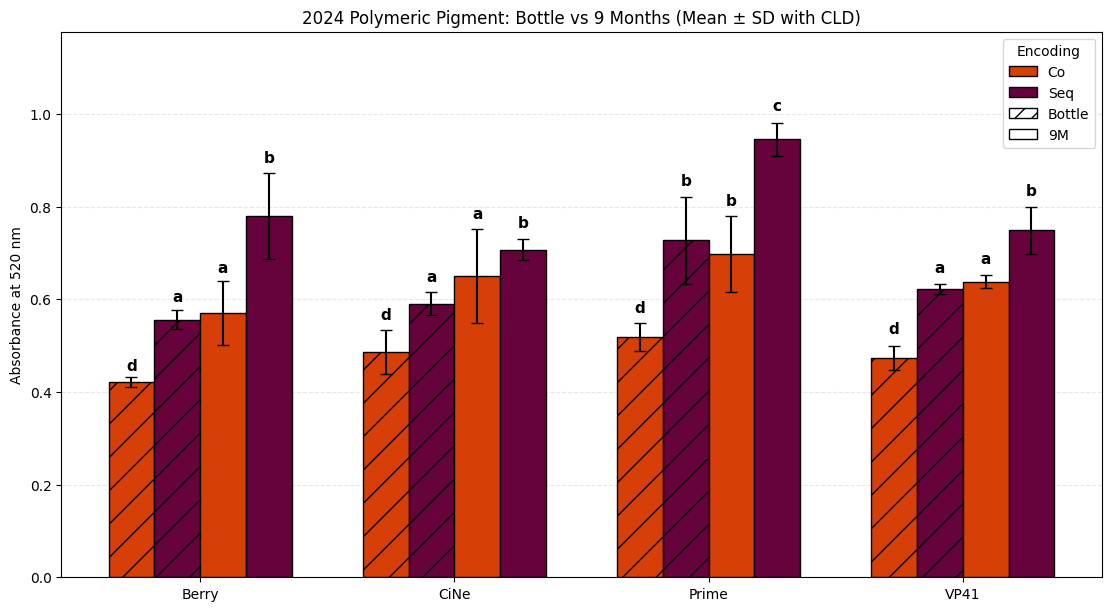

In [19]:
# =========================
# load data (incl. bottle vs 9M) → 3-way ANOVA → Tukey CLD → grouped barplot + export
# =========================

# =====================================================
# Styling
# =====================================================

HATCH_MAP = TIMEPOINT_HATCH


# =====================================================
# Data
# =====================================================
def load_data() -> pd.DataFrame:
    """
    Returns a long dataframe with columns:
      Timepoint, Group, Condition, Score, CondGrp
    CondGrp uniquely identifies each bar:
      f"{Timepoint}_{Group}_{Condition}"
    """

    # ----------------------------
    # Bottle data
    # ----------------------------
    bottle_co = {
        "Berry": [0.415, 0.411, 0.412, 0.433, 0.431, 0.428],
        "CiNe":  [0.44, 0.462, 0.431, 0.534, 0.518, 0.531],
        "Prime": [0.494, 0.489, 0.492, 0.538, 0.548, 0.549],
        "VP41":  [0.497, 0.497, 0.497, 0.444, 0.447, 0.462],
    }

    bottle_seq = {
        "Berry": [0.576, 0.585, 0.561, 0.538, 0.539, 0.537],
        "CiNe":  [0.562, 0.581, 0.59, 0.57, 0.609, 0.628],
        "Prime": [0.802, 0.816, 0.82, 0.636, 0.655, 0.635],
        "VP41":  [0.625, 0.626, 0.624, 0.606, 0.637, 0.617]
    }

    # ----------------------------
    # 9M data
    # ----------------------------
    aged_co = {
        "Berry": [0.581, 0.645, 0.487, 0.579, 0.64, 0.491],
        "CiNe":  [0.545, 0.626, 0.772, 0.551, 0.634, 0.77],
        "Prime": [0.739, 0.586, 0.764, 0.731, 0.601, 0.764],
        "VP41":  [0.621, 0.641, 0.649, 0.618, 0.647, 0.647],
    }

    aged_seq = {
        "Berry": [0.767, 0.888, 0.685, 0.761, 0.891, 0.683],
        "CiNe":  [0.675, 0.706, 0.725, 0.685, 0.716, 0.736],
        "Prime": [0.89, 0.979, 0.924, 0.957, 0.986, 0.932],
        "VP41":  [0.714, 0.811, 0.72, 0.709, 0.815, 0.723],
    }

    def _wide(d: dict, group: str, timepoint: str) -> pd.DataFrame:
        df = pd.DataFrame(d)
        df["Group"] = group
        df["Timepoint"] = timepoint
        return df

    df = pd.concat(
        [
            _wide(bottle_co, "Co", "Bottle"),
            _wide(bottle_seq, "Seq", "Bottle"),
            _wide(aged_co, "Co", "9M"),
            _wide(aged_seq, "Seq", "9M"),
        ],
        ignore_index=True
    )

    df_long = df.melt(
        id_vars=["Timepoint", "Group"],
        var_name="Condition",
        value_name="Score"
    )

    df_long["CondGrp"] = df_long["Timepoint"] + "_" + df_long["Group"] + "_" + df_long["Condition"]
    return df_long

# =====================================================
# Stats
# =====================================================
def run_three_way_anova(df_long: pd.DataFrame) -> pd.DataFrame:
    """
    Three-way ANOVA because we now have Timepoint, Group, Condition.
    """
    model = ols("Score ~ C(Timepoint) * C(Group) * C(Condition)", data=df_long).fit()
    return sm.stats.anova_lm(model, typ=2)


def run_tukey_cld(df_long: pd.DataFrame) -> pd.DataFrame:
    mc = MultiComparison(df_long["Score"], df_long["CondGrp"])
    hsd = mc.tukeyhsd(alpha=0.05)

    tukey_df = pd.DataFrame(
        hsd._results_table.data[1:],
        columns=hsd._results_table.data[0],
    )

    groups = mc.groupsunique
    k = len(groups)
    sig = np.zeros((k, k), dtype=bool)

    for i, g1 in enumerate(groups):
        for j in range(i + 1, k):
            g2 = groups[j]
            row = tukey_df[
                ((tukey_df.group1 == g1) & (tukey_df.group2 == g2)) |
                ((tukey_df.group1 == g2) & (tukey_df.group2 == g1))
            ]
            sig[i, j] = sig[j, i] = bool(row.reject.values[0])

    letters = [""] * k
    cur = ord("a")
    remaining = set(range(k))

    while remaining:
        bucket = []
        for idx in sorted(remaining):
            if all(not sig[idx, j] for j in bucket):
                letters[idx] += chr(cur)
                bucket.append(idx)
        remaining -= set(bucket)
        cur += 1

    return pd.DataFrame({"Treatment": groups, "CLD": letters})


# =====================================================
# Plotting (Hunter-style)
# =====================================================
def plot_polymeric_pigment_bars(df_long: pd.DataFrame, cld_df: pd.DataFrame) -> None:
    labels = ["Berry", "CiNe", "Prime", "VP41"]
    timepoints = ["Bottle", "9M"]
    groups = ["Co", "Seq"]

    # mean ± SD (not SEM)
    stats = (
        df_long
        .groupby(["Timepoint", "Group", "Condition"])["Score"]
        .agg(mean="mean", sd="std")
        .reset_index()
    )

    cld_dict = dict(zip(cld_df["Treatment"], cld_df["CLD"]))

    x = np.arange(len(labels))
    width = 0.18
    offsets = {
        ("Bottle", "Co"): -1.5 * width,
        ("Bottle", "Seq"): -0.5 * width,
        ("9M", "Co"):  0.5 * width,
        ("9M", "Seq"): 1.5 * width,
    }

    fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

    y_max = 0.0

    for i, cond in enumerate(labels):
        for tp in timepoints:
            for grp in groups:
                row = stats.query("Condition == @cond and Timepoint == @tp and Group == @grp")
                if row.empty:
                    continue

                mean = float(row["mean"].iloc[0])
                sd = float(row["sd"].iloc[0]) if pd.notna(row["sd"].iloc[0]) else 0.0
                y_max = max(y_max, mean + sd)

                xi = x[i] + offsets[(tp, grp)]
                ax.bar(
                    xi,
                    mean,
                    width=width,
                    color=COLOR_MAP[grp],
                    edgecolor="black",
                    linewidth=1.0,
                    hatch=HATCH_MAP[tp],
                    yerr=sd,
                    capsize=4,
                    ecolor="black",
                    zorder=2
                )

                key = f"{tp}_{grp}_{cond}"
                letter = cld_dict.get(key, "")

                pad = 0.02 * (y_max if y_max > 0 else 1.0)
                ax.text(
                    xi,
                    mean + sd + pad,
                    letter,
                    ha="center",
                    va="bottom",
                    fontsize=11,
                    fontweight="bold",
                    color="black"
                )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Absorbance at 520 nm")
    ax.set_title("2024 Polymeric Pigment: Bottle vs 9 Months (Mean ± SD with CLD)")
    ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)

    legend_elements = [
        Patch(facecolor=CO_COLOR, edgecolor="black", label="Co"),
        Patch(facecolor=SEQ_COLOR, edgecolor="black", label="Seq"),
        Patch(facecolor="white", edgecolor="black", hatch="//", label="Bottle"),
        Patch(facecolor="white", edgecolor="black", label="9M"),
    ]
    ax.legend(handles=legend_elements, title="Encoding", frameon=True)

    ax.set_ylim(0, y_max * 1.20)

    savefig_standard(plt.gcf(), POLYMERIC_PIGMENT_PNG, dpi=300)
    plt.show()


# =====================================================
# Run
# =====================================================
def main() -> None:
    df_long = load_data()

    anova = run_three_way_anova(df_long)
    print("\nThree-Way ANOVA Results:\n", anova)

    cld_df = run_tukey_cld(df_long)
    print("\nCompact Letter Display (CLD):")
    print(cld_df.to_string(index=False))

    report_path = init_report(
        POLYMERIC_PIGMENT_REPORT,
        "Polymeric Pigment Analysis (2024 Pinot)",
        metadata={
            "Section": "Bottle vs 9 months polymeric pigment absorbance",
            "Model": "Three-way ANOVA followed by Tukey HSD compact letter display",
            "Output figure": str(POLYMERIC_PIGMENT_PNG),
        },
    )
    append_report_section(report_path, "[ANOVA RESULTS]")
    append_report_df(report_path, anova)
    append_report_section(report_path, "[COMPACT LETTER DISPLAY]")
    append_report_df(report_path, cld_df, index=False)

    summary_df = (
        df_long.groupby(["Timepoint", "Group", "Condition"], observed=False)["Score"]
        .agg(mean="mean", sd="std", n="count")
        .reset_index()
    )
    append_report_section(report_path, "[SUMMARY TABLES]")
    append_report_df(report_path, summary_df, index=False)

    plot_polymeric_pigment_bars(df_long, cld_df)
    append_report_section(report_path, "[OUTPUTS]")
    append_report_text(report_path, f"Saved figure: {POLYMERIC_PIGMENT_PNG}")


if __name__ == "__main__":
    main()



# Instrumental Color Metrics (CIELAB) Pipeline

In [10]:
# =========================
# build tidy tables → derive C*, h° → ANOVA + Tukey HSD (all metrics)
# PLUS: two-panel ΔE figure aligned to objective
#   Panel A: ΔE Bottle→9M within each Strain×Timing
#   Panel B: ΔE Co–Seq at Bottle and 9M within each Strain
# =========================

# =====================================================
# Core metric functions
# =====================================================
def delta_e(c1, c2):
    """CIE76 ΔE*ab between two (L*, a*, b*) triplets."""
    return float(np.sqrt((c1[0] - c2[0])**2 + (c1[1] - c2[1])**2 + (c1[2] - c2[2])**2))


# =====================================================
# Data
# =====================================================
bottle_data = {
    'Co Berry': [[4.79,18.68,5.15], [4.23,15.80,4.31], [5.59,22.12,6.81]],
    'Co CiNe': [[6.99,25.57,8.98], [5.39,20.94,6.17], [3.97,16.88,4.46]],
    'Co Prime': [[4.79,23.36,6.98], [5.70,25.24,8.09], [3.87,19.36,5.44]],
    'Co VP41': [[3.87,19.04,5.09], [3.99,19.28,5.04], [3.32,15.90,4.12]],
    'Seq Berry': [[3.59,17.67,4.82], [3.80,17.66,4.61], [3.82,18.86,5.17]],
    'Seq CiNe': [[4.19,20.65,5.95], [4.25,20.46,5.82], [4.07,20.16,5.69]],
    'Seq Prime': [[3.14,15.90,4.24], [2.87,13.30,3.49], [3.86,16.70,4.47]],
    'Seq VP41': [[4.07,21.29,6.07], [3.12,16.42,4.55], [3.17,16.60,4.67]]
}

aged_data = {
    'Co Berry': [[4.24,16.13,4.13], [3.03,14.29,3.50], [3.97,19.98,5.14]],
    'Co CiNe': [[4.58,22.19,6.18], [3.27,16.30,4.14], [2.62,11.37,2.64]],
    'Co Prime': [[4.22,14.57,3.30], [5.67,20.10,5.20], [4.27,13.40,2.85]],
    'Co VP41': [[3.31,13.47,3.19], [3.89,15.84,3.85], [3.52,13.68,2.91]],
    'Seq Berry': [[3.76,15.90,3.85], [3.50,12.60,2.86], [3.63,13.70,3.37]],
    'Seq CiNe': [[4.87,18.51,4.89], [3.90,16.04,4.06], [3.57,16.22,4.02]],
    'Seq Prime': [[2.92,13.66,3.29], [2.40,9.87,2.27], [2.56,12.60,2.89]],
    'Seq VP41': [[3.42,16.08,3.98], [2.58,12.51,2.95], [2.97,14.51,3.54]]
}

# =====================================================
# Output paths
# =====================================================
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
PNG_LAB_PATH = FIGURE_DIR / f"CIELAB_Lab_CLD_{stamp}.png"
PNG_DE_PATH  = FIGURE_DIR / f"DeltaE_two_panel_objective_{stamp}.png"
TXT_PATH     = REPORT_DIR / f"CIELAB_stats_audit_{stamp}.txt"


# =====================================================
# Tidy data builders
# =====================================================
def dict_to_long_with_timepoint(df_dict, timepoint: str, metrics=("L", "a", "b")) -> pd.DataFrame:
    records = []
    for key, values in df_dict.items():
        group, strain = key.split()
        for rep_i, rep_vals in enumerate(values, start=1):
            rec = {"Group": group, "Strain": strain, "Timepoint": timepoint, "Replicate": rep_i}
            for m, v in zip(metrics, rep_vals):
                rec[m] = float(v)
            records.append(rec)
    return pd.DataFrame(records)


def build_lab_dataframe(use_hue_0_360: bool = True) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      df_wide: one row per (Group, Strain, Timepoint, Replicate) with columns L,a,b,C,h + Condition, Treatment
      df_long: long format with Metric/Value (for ANOVA workflows)
    """
    df_bottle = dict_to_long_with_timepoint(bottle_data, "Bottle")
    df_aged = dict_to_long_with_timepoint(aged_data, "9M")
    df_wide = pd.concat([df_bottle, df_aged], ignore_index=True)

    # Derived metrics
    df_wide["C"] = np.sqrt(df_wide["a"]**2 + df_wide["b"]**2)
    df_wide["h"] = np.degrees(np.arctan2(df_wide["b"], df_wide["a"]))
    if use_hue_0_360:
        df_wide["h"] = (df_wide["h"] + 360.0) % 360.0

    # Canonical labels
    df_wide["Condition"] = df_wide["Timepoint"] + "_" + df_wide["Group"]     # Bottle_Co, Bottle_Seq, 9M_Co, 9M_Seq
    df_wide["Treatment"] = df_wide["Group"] + "_" + df_wide["Strain"]        # Co_Berry, Seq_Berry, ...

    df_long = df_wide.melt(
        id_vars=["Group", "Strain", "Timepoint", "Replicate", "Condition", "Treatment"],
        value_vars=["L", "a", "b", "C", "h"],
        var_name="Metric",
        value_name="Value",
    )

    return df_wide, df_long


# =====================================================
# ΔE tables for the objective-aligned two-panel figure
# =====================================================
def build_deltae_aging_table(bottle_dict, aged_dict) -> pd.DataFrame:
    """
    Panel A:
      ΔE Bottle→9M within each Strain×Timing, paired by replicate index.
    """
    records = []
    for key in bottle_dict:
        timing, strain = key.split()  # "Co Berry"
        dEs = [delta_e(b, a) for b, a in zip(bottle_dict[key], aged_dict[key])]
        for rep_i, v in enumerate(dEs, start=1):
            records.append({
                "Timing": timing,
                "Group": timing,  # compatibility
                "Strain": strain,
                "Replicate": rep_i,
                "DeltaE": float(v),
                "Treatment": f"{timing}_{strain}",
                "Contrast": "Bottle→9M",
            })
    return pd.DataFrame(records)


def build_deltae_timing_table(bottle_dict, aged_dict) -> pd.DataFrame:
    """
    Panel B:
      ΔE Co–Seq at Bottle and at 9M within each Strain, paired by replicate index.
    """
    strains = sorted({k.split()[1] for k in bottle_dict.keys()})
    records = []

    for tp, src in [("Bottle", bottle_dict), ("9M", aged_dict)]:
        for strain in strains:
            k_co = f"Co {strain}"
            k_seq = f"Seq {strain}"
            if k_co not in src or k_seq not in src:
                raise KeyError(f"Missing Co/Seq pair for strain '{strain}' at timepoint '{tp}'.")
            dEs = [delta_e(c, s) for c, s in zip(src[k_co], src[k_seq])]
            for rep_i, v in enumerate(dEs, start=1):
                records.append({
                    "Strain": strain,
                    "Timepoint": tp,
                    "Replicate": rep_i,
                    "DeltaE": float(v),
                    "Contrast": "Co–Seq",
                })
    return pd.DataFrame(records)


def summarize_mean_sd(df: pd.DataFrame, value_col: str, group_cols: list[str]) -> pd.DataFrame:
    out = (df.groupby(group_cols, as_index=False, observed=False)
             .agg(mean=(value_col, "mean"), sd=(value_col, "std"), n=(value_col, "count")))
    out["sd"] = out["sd"].fillna(0.0)
    return out


# =====================================================
# ANOVA + Tukey HSD utilities
# =====================================================
def run_three_way_anova_lab(df_long: pd.DataFrame, metric: str, typ: int = 2) -> pd.DataFrame:
    d = df_long.query("Metric == @metric").copy()
    if d.empty:
        raise ValueError(f"No data found for Metric == '{metric}'.")
    d["Group"] = d["Group"].astype("category")
    d["Strain"] = d["Strain"].astype("category")
    d["Timepoint"] = d["Timepoint"].astype("category")
    model = smf.ols("Value ~ C(Group) * C(Strain) * C(Timepoint)", data=d).fit()
    return sm.stats.anova_lm(model, typ=typ)


def print_tukey(title: str, endog: np.ndarray, groups: np.ndarray, alpha: float = 0.05) -> pd.DataFrame:
    tuk = pairwise_tukeyhsd(endog=endog, groups=groups, alpha=alpha)
    print(f"\n--- Tukey HSD: {title} (alpha={alpha}) ---")
    print(tuk.summary())
    df = pd.DataFrame(tuk.summary().data[1:], columns=tuk.summary().data[0])
    return df


def print_means_sd_table(df_long: pd.DataFrame, metric: str,
                         strains_order=("Berry", "CiNe", "Prime", "VP41"),
                         timepoints=("Bottle", "9M"),
                         groups=("Co", "Seq"),
                         decimals: int = 3) -> None:
    label = {"L": "L*", "a": "a*", "b": "b*", "C": "C*", "h": "h°"}.get(metric, metric)

    d = df_long.query("Metric == @metric").copy()
    if d.empty:
        return

    summ = (d.groupby(["Strain", "Timepoint", "Group"], as_index=False, observed=False)
              .agg(mean=("Value", "mean"), sd=("Value", "std"), n=("Value", "count")))

    summ["Strain"] = pd.Categorical(summ["Strain"], categories=list(strains_order), ordered=True)
    summ["Timepoint"] = pd.Categorical(summ["Timepoint"], categories=list(timepoints), ordered=True)
    summ["Group"] = pd.Categorical(summ["Group"], categories=list(groups), ordered=True)
    summ = summ.sort_values(["Strain", "Timepoint", "Group"])

    def fmt(row):
        sd = 0.0 if pd.isna(row["sd"]) else float(row["sd"])
        return f"{float(row['mean']):.{decimals}f} ± {sd:.{decimals}f}"

    summ["mean_sd"] = summ.apply(fmt, axis=1)

    table = (summ.pivot_table(index="Strain", columns=["Timepoint", "Group"], values="mean_sd", aggfunc="first", observed=False)
                  .reindex(index=list(strains_order))
                  .reindex(columns=pd.MultiIndex.from_product([list(timepoints), list(groups)],
                                                             names=["Timepoint", "Group"])))


    n_table = (summ.pivot_table(index="Strain", columns=["Timepoint", "Group"], values="n", aggfunc="first", observed=False)
                    .reindex(index=list(strains_order))
                    .reindex(columns=pd.MultiIndex.from_product([list(timepoints), list(groups)],
                                                               names=["Timepoint", "Group"])))


    print(f"\n=== {label}: Means ± SD (and n) by Strain × Timepoint × Timing ===")
    print(table)
    print("\n(n)")
    print(n_table)


# ============================================================
# CLD (Compact Letter Display) helpers
# ============================================================
def cell_label(strain, timepoint, group):
    return f"{timepoint}_{group}_{strain}"


def run_tukey_on_cells(df_long_metric: pd.DataFrame, alpha: float = 0.05):
    """
    Tukey across full set of cells (Timepoint×Group×Strain).
    Expects columns: Value, Cell
    """
    return pairwise_tukeyhsd(
        endog=df_long_metric["Value"].to_numpy(),
        groups=df_long_metric["Cell"].to_numpy(),
        alpha=alpha
    )


def tukey_to_sig_matrix(tukey_result):
    groups = list(tukey_result.groupsunique)
    idx = {g: i for i, g in enumerate(groups)}
    k = len(groups)
    sig = np.zeros((k, k), dtype=bool)
    for r in tukey_result._results_table.data[1:]:
        g1, g2, _, _, _, _, reject = r
        i, j = idx[g1], idx[g2]
        sig[i, j] = bool(reject)
        sig[j, i] = bool(reject)
    return groups, sig


def compact_letter_display(groups, sig_matrix, means, descending=True):
    """
    Deterministic greedy CLD assignment.
    groups that are NOT significantly different (sig=False) may share letters.
    """
    order = np.argsort(means)
    if descending:
        order = order[::-1]

    can_share = ~sig_matrix.copy()
    np.fill_diagonal(can_share, True)

    letter_sets = []
    assignment = {g: "" for g in groups}

    for gi in order:
        placed = False
        for L in letter_sets:
            if all(can_share[gi, gj] for gj in L):
                L.add(gi)
                placed = True
                break
        if not placed:
            letter_sets.append(set([gi]))

    alphabet = list("abcdefghijklmnopqrstuvwxyz")
    if len(letter_sets) > len(alphabet):
        alphabet = alphabet + [f"a{c}" for c in alphabet]

    for li, L in enumerate(letter_sets):
        lab = alphabet[li]
        for gi in L:
            assignment[groups[gi]] += lab

    return assignment
# ============================================================
# Two-panel ΔE figure
#   Panel A: ΔE Bottle→9M within each Strain×Timing
#   Panel B: ΔE Co–Seq at Bottle and 9M within each Strain
# ============================================================
def plot_two_panel_deltae(
    bottle_dict,
    aged_dict,
    strains_order=("Berry", "CiNe", "Prime", "VP41"),
    timing_order=("Co", "Seq"),
    timepoint_order=("Bottle", "9M"),
    thresholds=(1.0, 3.0),
    out_png="DeltaE_two_panel_objective.png",
    dpi=300,
    show=False
):
    """
    Builds a two-panel ΔE figure aligned to the manuscript objective.

    Panel A:
        ΔE Bottle→9M within each Strain×Timing
    Panel B:
        ΔE Co–Seq at Bottle and 9M within each Strain

    Bars show mean ± SD from replicate-paired ΔE values.
    """

    # -------------------------
    # Build replicate-level data
    # -------------------------
    dfA = build_deltae_aging_table(bottle_dict, aged_dict)
    dfB = build_deltae_timing_table(bottle_dict, aged_dict)

    # -------------------------
    # Summaries
    # -------------------------
    summA = summarize_mean_sd(dfA, "DeltaE", ["Strain", "Timing"])
    summB = summarize_mean_sd(dfB, "DeltaE", ["Strain", "Timepoint"])

    # enforce plotting order
    summA["Strain"] = pd.Categorical(summA["Strain"], categories=list(strains_order), ordered=True)
    summA["Timing"] = pd.Categorical(summA["Timing"], categories=list(timing_order), ordered=True)
    summA = summA.sort_values(["Strain", "Timing"]).reset_index(drop=True)

    summB["Strain"] = pd.Categorical(summB["Strain"], categories=list(strains_order), ordered=True)
    summB["Timepoint"] = pd.Categorical(summB["Timepoint"], categories=list(timepoint_order), ordered=True)
    summB = summB.sort_values(["Strain", "Timepoint"]).reset_index(drop=True)

    # -------------------------
    # Layout
    # -------------------------
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), dpi=dpi, sharex=False)
    fig.suptitle("Objective-Aligned ΔE Comparisons", y=0.98, fontsize=14)

    # =========================
    # Panel A
    # =========================
    ax = axes[0]

    x = np.arange(len(strains_order))
    bar_w = 0.36
    offsets = np.array([-bar_w / 2, bar_w / 2])

    for j, timing in enumerate(timing_order):
        sub = summA[summA["Timing"] == timing].copy()
        sub = sub.set_index("Strain").reindex(strains_order).reset_index()

        means = sub["mean"].to_numpy(dtype=float)
        sds = sub["sd"].to_numpy(dtype=float)

        ax.bar(
            x + offsets[j],
            means,
            width=bar_w,
            color=color_map[timing],
            edgecolor="black",
            linewidth=1.0,
            yerr=sds,
            capsize=4,
            ecolor="black",
            zorder=2,
            label=timing
        )

    # thresholds
    for thr in thresholds:
        ax.axhline(thr, linestyle="--", linewidth=1.0, color="black", alpha=0.6, zorder=1)

    # annotate threshold labels at right margin
    ymaxA = max((summA["mean"] + summA["sd"]).max(), max(thresholds)) if not summA.empty else max(thresholds)
    ax.text(len(strains_order) - 0.35, thresholds[0] + 0.05, "ΔE = 1.0", ha="right", va="bottom", fontsize=9)
    ax.text(len(strains_order) - 0.35, thresholds[1] + 0.05, "ΔE = 3.0", ha="right", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(strains_order)
    ax.set_ylabel("ΔE*ab")
    ax.set_title("Panel A. ΔE Bottle→9M within each Strain × Timing", fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(title="Timing", frameon=False, loc="upper left")

    # =========================
    # Panel B
    # =========================
    ax = axes[1]

    x = np.arange(len(strains_order))
    bar_w = 0.36
    offsets = np.array([-bar_w / 2, bar_w / 2])

    for j, tp in enumerate(timepoint_order):
        sub = summB[summB["Timepoint"] == tp].copy()
        sub = sub.set_index("Strain").reindex(strains_order).reset_index()

        means = sub["mean"].to_numpy(dtype=float)
        sds = sub["sd"].to_numpy(dtype=float)

        ax.bar(
            x + offsets[j],
            means,
            width=bar_w,
            color="white",
            edgecolor="black",
            linewidth=1.0,
            hatch=TIMEPOINT_HATCH.get(tp, None),
            yerr=sds,
            capsize=4,
            ecolor="black",
            zorder=2,
            label=tp
        )

    for thr in thresholds:
        ax.axhline(thr, linestyle="--", linewidth=1.0, color="black", alpha=0.6, zorder=1)

    ymaxB = max((summB["mean"] + summB["sd"]).max(), max(thresholds)) if not summB.empty else max(thresholds)
    ax.text(len(strains_order) - 0.35, thresholds[0] + 0.05, "ΔE = 1.0", ha="right", va="bottom", fontsize=9)
    ax.text(len(strains_order) - 0.35, thresholds[1] + 0.05, "ΔE = 3.0", ha="right", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(strains_order)
    ax.set_xlabel("Strain")
    ax.set_ylabel("ΔE*ab")
    ax.set_title("Panel B. ΔE Co–Seq within each Strain at Bottle and 9M", fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend_elements = [
        Patch(facecolor="white", edgecolor="black", hatch="//", label="Bottle"),
        Patch(facecolor="white", edgecolor="black", label="9M"),
    ]
    ax.legend(handles=legend_elements, title="Timepoint", frameon=False, loc="upper left")

    # -------------------------
    # final formatting
    # -------------------------
    plt.tight_layout(rect=[0, 0, 1, 0.965])
    fig.savefig(out_png, dpi=dpi, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

# ============================================================
# L*, a*, b* combined plot with CLD
# ============================================================
def summarize_mean_sd_n(df_long_metric: pd.DataFrame, value_col="Value"):
    return (
        df_long_metric.groupby(["Strain", "Timepoint", "Group"], as_index=False, observed=False)
                      .agg(mean=(value_col, "mean"), sd=(value_col, "std"), n=(value_col, "size"))
    )


def plot_Lab_three_panel_with_cld(
    df_long: pd.DataFrame,
    cld_maps: dict,
    strains=("Berry", "CiNe", "Prime", "VP41"),
    timepoints=("Bottle", "9M"),
    groups=("Co", "Seq"),
    out_png="CIELAB_Lab_CLD.png",
    dpi=300,
    show=False
):
    """
    Single PNG with 3 panels: L*, a*, b* (mean ± SD) with CLD letters above each bar.
    Bars touch within each strain (no gaps).
    """

    metrics = ("L", "a", "b")
    titles = {"L": "L* (mean ± SD) with CLD (Tukey, α=0.05)",
              "a": "a* (mean ± SD) with CLD (Tukey, α=0.05)",
              "b": "b* (mean ± SD) with CLD (Tukey, α=0.05)"}
    ylabels = {"L": "L*", "a": "a*", "b": "b*"}

    # --- touching bars within each strain ---
    bars_per_strain = len(timepoints) * len(groups)  # 4
    bar_w = 0.20
    rel = np.linspace(-(bars_per_strain - 1) / 2, (bars_per_strain - 1) / 2, bars_per_strain) * bar_w
    order = [(tp, grp) for tp in timepoints for grp in groups]  # Bottle-Co, Bottle-Seq, 9M-Co, 9M-Seq

    x = np.arange(len(strains))

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), dpi=dpi, sharex=True)
    fig.suptitle("CIELAB Metrics: L*, a*, b* (CLD shown above bars)", y=0.985)

    # flexible CLD lookup
    def _cld_lookup(cld_map, strain, tp, grp):
        if cld_map is None:
            return None
        return (
            cld_map.get((strain, tp, grp))
            or cld_map.get((strain, grp, tp))
            or cld_map.get(f"{tp}_{grp}_{strain}")
            or cld_map.get(f"{strain}_{tp}_{grp}")
            or cld_map.get(f"{grp}_{strain}_{tp}")
        )

    for ax, m in zip(axes, metrics):
        raw = df_long.query("Metric == @m").copy()
        if raw.empty:
            raise ValueError(f"No rows found for Metric == '{m}'.")

        summ = (raw.groupby(["Strain", "Timepoint", "Group"], as_index=False)
                  .agg(mean=("Value", "mean"), sd=("Value", "std")))
        summ["sd"] = summ["sd"].fillna(0.0)

        cld_map = cld_maps.get(m, None)

        # draw bars
        for i, strain in enumerate(strains):
            for j, (tp, grp) in enumerate(order):
                row = summ.query("Strain == @strain and Timepoint == @tp and Group == @grp")
                if row.empty:
                    continue

                mean = float(row["mean"].iloc[0])
                sd = float(row["sd"].iloc[0])
                xi = x[i] + rel[j]

                ax.bar(
                    xi, mean,
                    width=bar_w,
                    color=color_map[grp],
                    edgecolor="black",
                    linewidth=1.0,
                    hatch=timepoint_hatch.get(tp, None),
                    yerr=sd,
                    capsize=4,
                    ecolor="black",
                    zorder=2
                )

                # CLD letter
                letter = _cld_lookup(cld_map, strain, tp, grp)
                if letter is not None:
                    ax.text(xi, mean + sd + 0.12, str(letter),
                            ha="center", va="bottom", fontsize=9, fontweight="bold")

        ax.set_ylabel(ylabels[m])
        ax.set_title(titles[m], fontsize=11)
        ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # x-axis labels on bottom only
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(list(strains))
    axes[-1].set_xlabel("Strain")

    # single legend in top panel
    legend_elements = [
        Patch(facecolor=CO_COLOR, edgecolor="black", label="Co"),
        Patch(facecolor=SEQ_COLOR, edgecolor="black", label="Seq"),
        Patch(facecolor="white", edgecolor="black", hatch="//", label="Bottle"),
        Patch(facecolor="white", edgecolor="black", label="9M"),
    ]
    axes[0].legend(handles=legend_elements, title="Encoding", frameon=False, loc="upper right")

    plt.tight_layout(rect=[0, 0, 1, 0.965])
    fig.savefig(out_png, dpi=dpi, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

# =====================================================
# RUN EVERYTHING
# =====================================================
if __name__ == "__main__":
    STRAINS = ("Berry", "CiNe", "Prime", "VP41")
    GROUPS = ("Co", "Seq")
    TIMEPOINTS = ("Bottle", "9M")
    METRICS = ("L", "a", "b", "C", "h")
    ALPHA = 0.05
    DPI = 300

    df_wide, df_long = build_lab_dataframe(use_hue_0_360=True)

    # =========================
    # Write audit log: stats, means, SD, ANOVA, Tukey, CLD (ALL metrics)
    # =========================
    cld_maps = {}  # metric -> dict(cell -> letters)

    with open(TXT_PATH, "w", encoding="utf-8") as f, contextlib.redirect_stdout(f):
        print("============================================================")
        print("CIELAB + ΔE Audit Log")
        print("============================================================")
        print(f"Generated: {datetime.now().isoformat(timespec='seconds')}")
        print(f"Rows (CIELAB): {len(df_wide)}")
        print("")

        print("=== Replicate counts (Strain×Timepoint×Timing) ===")
        print(df_wide.groupby(["Strain", "Timepoint", "Group"], observed=False).size().rename("n"))
        print("\n")

        # CIELAB metrics stats
        for m in METRICS:
            label = {"L": "L*", "a": "a*", "b": "b*", "C": "C*", "h": "h°"}.get(m, m)
            print("============================================================")
            print(f"METRIC: {label}")
            print("============================================================")

            # means ± SD tables
            print_means_sd_table(df_long, metric=m, strains_order=STRAINS, timepoints=TIMEPOINTS, groups=GROUPS, decimals=3)

            # ANOVA
            print(f"\n=== THREE-WAY ANOVA: {label} (Type II) ===")
            anova_tbl = run_three_way_anova_lab(df_long, metric=m, typ=2)
            print(anova_tbl)

            # Tukey across 8 cells
            d = df_long.query("Metric == @m").copy()
            d["Cell"] = d.apply(lambda r: cell_label(r["Strain"], r["Timepoint"], r["Group"]), axis=1)

            tuk = run_tukey_on_cells(d, alpha=ALPHA)
            print(f"\n--- Tukey HSD: {label}: Tukey across 8 cells (Timepoint×Timing×Strain) (alpha={ALPHA}) ---")
            print(tuk.summary())

            # CLD from Tukey
            groups_u, sig = tukey_to_sig_matrix(tuk)
            means_by_cell = d.groupby("Cell", observed=False)["Value"].mean().reindex(groups_u).values
            cld = compact_letter_display(groups_u, sig, means_by_cell, descending=True)
            cld_maps[m] = cld

            print(f"\n=== CLD letters (cell -> letters) for {label} ===")
            order = np.argsort(means_by_cell)[::-1]
            for i in order:
                c = groups_u[i]
                print(f"{c:20s}  mean={means_by_cell[i]:.4f}  CLD={cld[c]}")
            print("\n")

            # Optional within-strain Tukey across 4 conditions (for readability)
            for strain in STRAINS:
                ds = d[d["Strain"] == strain].copy()
                ds["Cond4"] = ds["Timepoint"].astype(str) + "_" + ds["Group"].astype(str)
                _ = print_tukey(
                    title=f"{label}: {strain} Tukey across 4 conditions (Timepoint×Timing)",
                    endog=ds["Value"].to_numpy(),
                    groups=ds["Cond4"].to_numpy(),
                    alpha=ALPHA
                )

        # ΔE tables + stats
        df_deltaA = build_deltae_aging_table(bottle_data, aged_data)
        df_deltaB = build_deltae_timing_table(bottle_data, aged_data)

        print("============================================================")
        print("ΔE TABLES + STATS")
        print("============================================================")

        print("\n=== ΔE Panel A (Bottle→9M within Strain×Timing): mean ± SD ===")
        print(summarize_mean_sd(df_deltaA, "DeltaE", ["Strain", "Timing"]).sort_values(["Strain", "Timing"]))

        print("\n=== ΔE Panel B (Co–Seq at each timepoint within Strain): mean ± SD ===")
        print(summarize_mean_sd(df_deltaB, "DeltaE", ["Strain", "Timepoint"]).sort_values(["Strain", "Timepoint"]))

        print("\n=== ANOVA: ΔE Panel A (Bottle→9M) ~ Timing × Strain ===")
        dfA = df_deltaA.copy()
        dfA["Timing"] = dfA["Timing"].astype("category")
        dfA["Strain"] = dfA["Strain"].astype("category")
        modelA = smf.ols("DeltaE ~ C(Timing) * C(Strain)", data=dfA).fit()
        print(sm.stats.anova_lm(modelA, typ=2))

        dfA["Cell"] = dfA["Timing"].astype(str) + "_" + dfA["Strain"].astype(str)
        _ = print_tukey(
            title="ΔE Panel A: Tukey across 8 cells (Timing×Strain)",
            endog=dfA["DeltaE"].to_numpy(),
            groups=dfA["Cell"].to_numpy(),
            alpha=ALPHA
        )

        print("\n=== ANOVA: ΔE Panel B (Co–Seq) ~ Timepoint × Strain ===")
        dfB = df_deltaB.copy()
        dfB["Timepoint"] = dfB["Timepoint"].astype("category")
        dfB["Strain"] = dfB["Strain"].astype("category")
        modelB = smf.ols("DeltaE ~ C(Timepoint) * C(Strain)", data=dfB).fit()
        print(sm.stats.anova_lm(modelB, typ=2))

        dfB["Cell"] = dfB["Timepoint"].astype(str) + "_" + dfB["Strain"].astype(str)
        _ = print_tukey(
            title="ΔE Panel B: Tukey across 8 cells (Timepoint×Strain)",
            endog=dfB["DeltaE"].to_numpy(),
            groups=dfB["Cell"].to_numpy(),
            alpha=ALPHA
        )

        for strain in STRAINS:
            sub = dfB[dfB["Strain"] == strain].copy()
            _ = print_tukey(
                title=f"ΔE Panel B: {strain} Tukey (Bottle vs 9M)",
                endog=sub["DeltaE"].to_numpy(),
                groups=sub["Timepoint"].to_numpy(),
                alpha=ALPHA
            )

        print("\n============================================================")
        print("END OF AUDIT LOG")
        print("============================================================")

    # =========================
    # Plots
    # =========================
    # 1) L*, a*, b* combined figure WITH CLD (single .png)
    plot_Lab_three_panel_with_cld(df_long=df_long, cld_maps=cld_maps, out_png=PNG_LAB_PATH, dpi=DPI)

    # 2) Two-panel ΔE figure (separate .png)
    plot_two_panel_deltae(
        bottle_dict=bottle_data,
        aged_dict=aged_data,
        strains_order=STRAINS,
        timing_order=GROUPS,
        thresholds=(1.0, 3.0),
        out_png=PNG_DE_PATH,
        dpi=DPI,
        show=False
    )

    print(f"Saved L*, a*, b* CLD figure: {PNG_LAB_PATH}")
    print(f"Saved ΔE two-panel figure: {PNG_DE_PATH}")
    print(f"Saved audit log (.txt): {TXT_PATH}")

Saved L*, a*, b* CLD figure: C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\figures\CIELAB_Lab_CLD_20260503_113455.png
Saved ΔE two-panel figure: C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\figures\DeltaE_two_panel_objective_20260503_113455.png
Saved audit log (.txt): C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\reports\CIELAB_stats_audit_20260503_113455.txt


# Color Triangle Sensory Pipeline

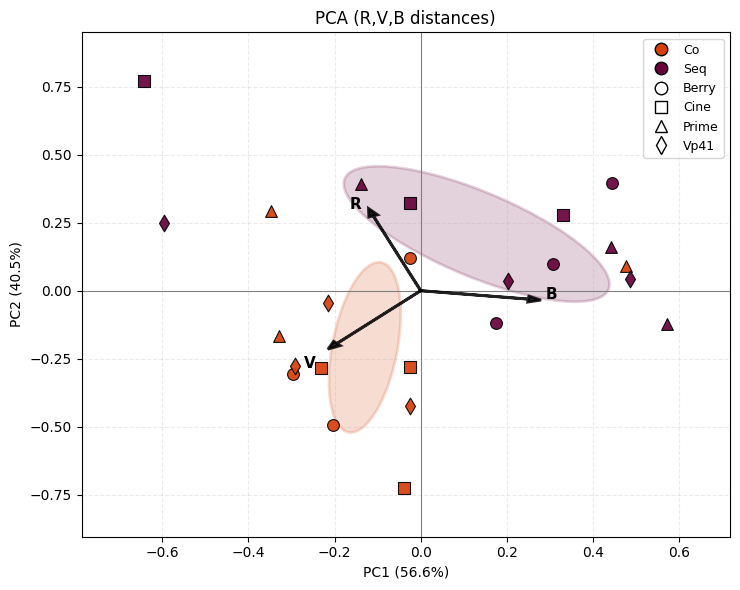

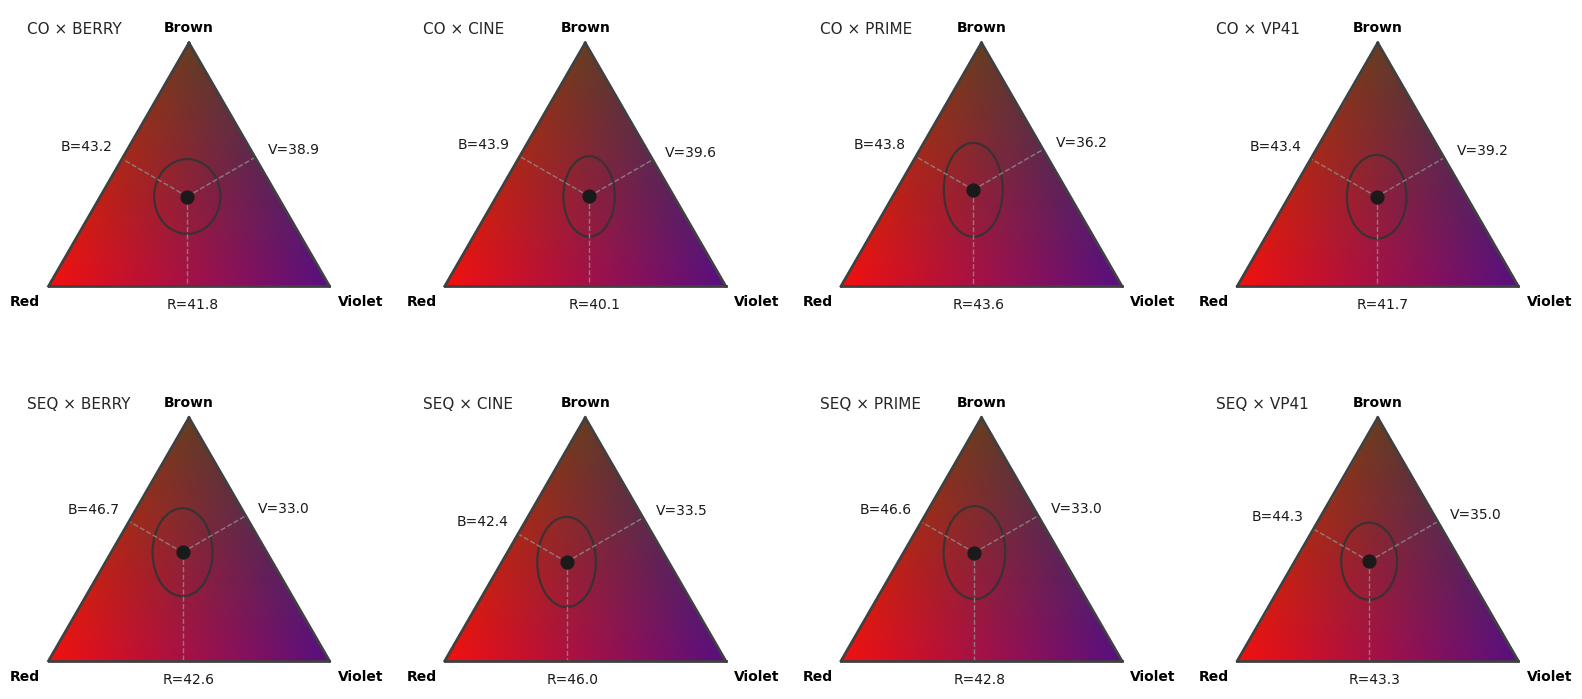

In [20]:
# ============================================================
# (R/P/B distances)
# Structured PERMANOVA + PERMDISP + PCA + Triangle Plot
# ============================================================

# =========================
# USER SETTINGS
# =========================
RAW_FILE = str(COLOR_TRIANGLE_FILE)
SHEET_NAME = 0
FIGURE_OUT_DIR = str(FIGURE_DIR / "color_triangle")
REPORT_OUT_DIR = str(REPORT_DIR / "color_triangle")
TABLE_OUT_DIR = str(TABLE_DIR / "color_triangle")

DIST_METRIC = "euclidean"   # Euclidean on (R,P,B) distances

# Triangle scale used on the printed sheet
TRI_SIDE_MM = 81.0

# Pantone anchor colors
ANCHOR_HEX = {
    "R": "#f30302",
    "V": "#4e027a",
    "B": "#5d3217",
}

# Report/plots
REPORT_TXT = os.path.join(REPORT_OUT_DIR, "color_triangle_report.txt")
PCA_PNG = os.path.join(FIGURE_OUT_DIR, "color_triangle_PCA.png")
TRI_PNG = os.path.join(FIGURE_OUT_DIR, "color_triangle_triangle.png")

# Visual encoding
ELLIPSE_SOURCE_STANDARD = "centroids"
ELLIPSE_N_STD_STANDARD = 1.5

# =========================
# Read wide Excel, flatten headers, build long panelist table
# =========================
def read_color_triangle_wide(path, sheet=0) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"RAW_FILE not found: {path}")

    df = pd.read_excel(path, sheet_name=sheet, header=[0, 1], engine="openpyxl")

    new_cols = []
    panel_pat = re.compile(r"panelist\s*#?\s*(\d+)", flags=re.I)

    for a, b in df.columns:
        a0 = "" if a is None else str(a).strip()
        b0 = "" if b is None else str(b).strip()

        a_low = a0.lower()
        b_up = b0.upper()

        if a_low == "wine":
            new_cols.append("Wine")
            continue
        if a_low == "code":
            new_cols.append("Code")
            continue

        m_a = panel_pat.search(a0)
        m_b = panel_pat.search(b0)
        m = m_a if m_a else m_b

        if m and (b_up in {"R", "B", "V"} or a0.upper() in {"R", "B", "V"}):
            n = m.group(1)
            axis = b_up if b_up in {"R", "B", "V"} else a0.upper()
            new_cols.append(f"P{n}_{axis}")
            continue

        colname = f"{a0}_{b0}".strip("_")
        if colname == "":
            colname = "Unnamed"
        new_cols.append(colname)

    df.columns = new_cols
    df = df.dropna(how="all").reset_index(drop=True)

    if df.columns.duplicated().any():
        counts = {}
        cols2 = []
        for c in df.columns:
            if c not in counts:
                counts[c] = 0
                cols2.append(c)
            else:
                counts[c] += 1
                cols2.append(f"{c}_{counts[c]}")
        df.columns = cols2

    return df


def wide_to_long_panelists(df_wide: pd.DataFrame) -> pd.DataFrame:
    df = df_wide.copy()

    if "Wine" not in df.columns or "Code" not in df.columns:
        raise KeyError("Expected columns 'Wine' and 'Code' in df_wide. Check read_color_triangle_wide().")

    pattern = re.compile(r"^P(\d+)_(R|B|V)$")
    panel_cols = [c for c in df.columns if pattern.match(c)]
    if not panel_cols:
        raise KeyError("No panelist columns found (expected P#_R/B/V).")

    long = (
        df.melt(
            id_vars=["Wine", "Code"],
            value_vars=panel_cols,
            var_name="PanelAxis",
            value_name="Value"
        )
        .dropna(subset=["Value"])
    )

    long["Panelist"] = long["PanelAxis"].str.extract(r"^(P\d+)_", expand=False)
    long["Axis"] = long["PanelAxis"].str.extract(r"_(R|B|V)$", expand=False)

    wine = long["Wine"].astype(str).str.strip()
    long["Timing"] = wine.str.extract(r"^(Co|Seq)", expand=False)
    long["Strain"] = wine.str.extract(r"^(?:Co|Seq)(Berry|CiNe|Prime|VP41)", expand=False)
    long["Replicate"] = pd.to_numeric(wine.str.extract(r"(\d+)$", expand=False), errors="coerce")

    long["Timing"] = long["Timing"].replace({"Co": "CO", "Seq": "SEQ"})
    long["Strain"] = long["Strain"].replace({
        "Berry": "BERRY",
        "CiNe": "CINE",
        "Prime": "PRIME",
        "VP41": "VP41"
    })

    long["Treatment"] = long["Timing"].astype(str) + "_" + long["Strain"].astype(str)
    long["SampleID"] = wine

    wide = (
        long.pivot_table(
            index=["SampleID", "Treatment", "Code", "Panelist", "Timing", "Strain", "Replicate"],
            columns="Axis",
            values="Value",
            aggfunc="first"
        )
        .reset_index()
    )

    for c in ["R", "B", "V"]:
        wide[c] = pd.to_numeric(wide.get(c), errors="coerce")
    wide = wide.dropna(subset=["R", "B", "V"]).reset_index(drop=True)

    return wide


# =========================
# SHEET-GEOMETRY MAPPING
# =========================
SQRT3 = np.sqrt(3)

V_RED = np.array([0.0, 0.0], dtype=float)
V_VIOLET = np.array([1.0, 0.0], dtype=float)
V_BROWN = np.array([0.5, SQRT3 / 2.0], dtype=float)


def _unit(v):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)
    return v if n == 0 else v / n


def _edge_point_from_mm(A, B, t_mm, side_mm=82.0):
    t = float(t_mm) / float(side_mm)
    t = np.clip(t, 0.0, 1.0)
    return (1.0 - t) * A + t * B


def _line_best_intersection(points, dirs):
    I = np.eye(2)
    A = np.zeros((2, 2), dtype=float)
    b = np.zeros(2, dtype=float)

    for p, u in zip(points, dirs):
        u = _unit(u)
        P = I - np.outer(u, u)
        A += P
        b += P @ p

    if np.linalg.cond(A) > 1e12:
        return np.mean(np.vstack(points), axis=0)
    return np.linalg.solve(A, b)


def sheet_rpb_to_xy(R_mm, P_mm, B_mm, side_mm=82.0):
    F_R = _edge_point_from_mm(V_VIOLET, V_RED, R_mm, side_mm=side_mm)
    F_P = _edge_point_from_mm(V_BROWN, V_VIOLET, P_mm, side_mm=side_mm)
    F_B = _edge_point_from_mm(V_RED, V_BROWN, B_mm, side_mm=side_mm)

    def rot90(v):
        return np.array([-v[1], v[0]], dtype=float)

    u_R = rot90(V_RED - V_VIOLET)
    u_P = rot90(V_VIOLET - V_BROWN)
    u_B = rot90(V_BROWN - V_RED)

    X = _line_best_intersection([F_R, F_P, F_B], [u_R, u_P, u_B])
    return float(X[0]), float(X[1])


def _project_point_to_segment(px, py, ax, ay, bx, by):
    abx, aby = bx - ax, by - ay
    apx, apy = px - ax, py - ay
    denom = abx * abx + aby * aby
    if denom == 0:
        return ax, ay
    t = (apx * abx + apy * aby) / denom
    t = np.clip(t, 0.0, 1.0)
    return ax + t * abx, ay + t * aby


# =========================
# Triangle flood background helpers
# =========================
def _hex_to_rgb01(h: str):
    h = h.lstrip("#")
    return np.array([int(h[i:i+2], 16) for i in (0, 2, 4)], dtype=float) / 255.0


def _barycentric_weights(P, A, B, C):
    v0 = B - A
    v1 = C - A
    v2 = P - A

    d00 = np.dot(v0, v0)
    d01 = np.dot(v0, v1)
    d11 = np.dot(v1, v1)

    d20 = v2[..., 0] * v0[0] + v2[..., 1] * v0[1]
    d21 = v2[..., 0] * v1[0] + v2[..., 1] * v1[1]

    denom = d00 * d11 - d01 * d01
    denom = denom if denom != 0 else 1e-12

    wB = (d11 * d20 - d01 * d21) / denom
    wC = (d00 * d21 - d01 * d20) / denom
    wA = 1.0 - wB - wC
    return wA, wB, wC


def add_triangle_color_flood(ax, anchor_hex=ANCHOR_HEX, resolution=350, alpha=0.95, zorder=0):
    A = V_RED
    B = V_VIOLET
    C = V_BROWN

    cA = _hex_to_rgb01(anchor_hex["R"])
    cB = _hex_to_rgb01(anchor_hex["V"])
    cC = _hex_to_rgb01(anchor_hex["B"])

    xmin, xmax = -0.02, 1.02
    ymin, ymax = -0.02, (SQRT3 / 2.0) + 0.02

    xs = np.linspace(xmin, xmax, resolution)
    ys = np.linspace(ymin, ymax, resolution)
    X, Y = np.meshgrid(xs, ys)
    P = np.stack([X, Y], axis=-1)

    wA, wB, wC = _barycentric_weights(P, A, B, C)
    eps = 1e-6
    mask = (wA >= -eps) & (wB >= -eps) & (wC >= -eps)

    img = (wA[..., None] * cA + wB[..., None] * cB + wC[..., None] * cC)
    img = np.clip(img, 0, 1)

    rgba = np.zeros((img.shape[0], img.shape[1], 4), dtype=float)
    rgba[..., :3] = img
    rgba[..., 3] = alpha * mask.astype(float)

    ax.imshow(
        rgba,
        origin="lower",
        extent=(xmin, xmax, ymin, ymax),
        interpolation="bilinear",
        zorder=zorder
    )


def draw_triangle(ax, edge_color="0.25", lw=2.0, flood=True, flood_resolution=350, flood_alpha=0.95):
    if flood:
        add_triangle_color_flood(
            ax,
            anchor_hex=ANCHOR_HEX,
            resolution=flood_resolution,
            alpha=flood_alpha,
            zorder=0
        )

    ax.plot([V_RED[0], V_VIOLET[0]], [V_RED[1], V_VIOLET[1]], color=edge_color, lw=lw, zorder=5)
    ax.plot([V_VIOLET[0], V_BROWN[0]], [V_VIOLET[1], V_BROWN[1]], color=edge_color, lw=lw, zorder=5)
    ax.plot([V_BROWN[0], V_RED[0]], [V_BROWN[1], V_RED[1]], color=edge_color, lw=lw, zorder=5)

    ax.text(V_RED[0] - 0.03, V_RED[1] - 0.03, "Red", ha="right", va="top", fontweight="bold", zorder=6)
    ax.text(V_VIOLET[0] + 0.03, V_VIOLET[1] - 0.03, "Violet", ha="left", va="top", fontweight="bold", zorder=6)
    ax.text(V_BROWN[0], V_BROWN[1] + 0.03, "Brown", ha="center", va="bottom", fontweight="bold", zorder=6)

    ax.set_aspect("equal")
    ax.set_xlim(-0.10, 1.10)
    ax.set_ylim(-0.10, SQRT3 / 2.0 + 0.12)
    ax.axis("off")


# =========================
# XY columns for each observation
# =========================
def add_xy_columns_from_sheet(df_long: pd.DataFrame, side_mm=82.0) -> pd.DataFrame:
    out = df_long.copy()
    xs, ys = [], []
    for _, r in out.iterrows():
        x, y = sheet_rpb_to_xy(r["R"], r["V"], r["B"], side_mm=side_mm)
        xs.append(x)
        ys.append(y)
    out["x"] = xs
    out["y"] = ys
    return out


def replicate_centroids_xy(df_xy: pd.DataFrame) -> pd.DataFrame:
    req = {"SampleID", "Treatment", "Timing", "Strain", "x", "y"}
    missing = req - set(df_xy.columns)
    if missing:
        raise KeyError(f"df_xy missing required columns: {sorted(missing)}")

    return (
        df_xy.groupby(["SampleID", "Treatment", "Timing", "Strain"], as_index=False)
             .agg(x=("x", "mean"), y=("y", "mean"))
    )


def means_sd_tables_xy_and_rpb(df_xy: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    msd_xy = (
        df_xy.groupby(["Treatment", "Timing", "Strain"], as_index=False)
             .agg(
                 x_mean=("x", "mean"), x_sd=("x", "std"),
                 y_mean=("y", "mean"), y_sd=("y", "std"),
                 n=("x", "count")
             )
             .sort_values(["Timing", "Strain"])
             .reset_index(drop=True)
    )

    msd_rpb = (
        df_xy.groupby(["Treatment", "Timing", "Strain"], as_index=False)
             .agg(
                 R_mean=("R", "mean"), R_sd=("R", "std"),
                 V_mean=("V", "mean"), V_sd=("V", "std"),
                 B_mean=("B", "mean"), B_sd=("B", "std"),
                 n=("R", "count")
             )
             .sort_values(["Timing", "Strain"])
             .reset_index(drop=True)
    )
    return msd_xy, msd_rpb


def sd_ring_xy_from_xy_data(ax, df_xy_sub, x0, y0, color="0.20", lw=1.6, alpha=0.9):
    xs = df_xy_sub["x"].to_numpy(dtype=float)
    ys = df_xy_sub["y"].to_numpy(dtype=float)

    xs = xs[~np.isnan(xs)]
    ys = ys[~np.isnan(ys)]
    if len(xs) < 3 or len(ys) < 3:
        return

    sx = float(np.std(xs, ddof=1))
    sy = float(np.std(ys, ddof=1))

    e = Ellipse((x0, y0), width=2*sx, height=2*sy, angle=0.0,
                fill=False, edgecolor=color, linewidth=lw, alpha=alpha)
    ax.add_patch(e)


def add_perpendicular_guides_from_xy(
    ax, x0, y0, Rm, Pm, Bm, label_fmt="{:.1f}",
    line_color="0.55", lw=1.0, alpha=0.85, outward=0.040,
    tangent=0.020, text_color="0.10", fontsize=10, use_bbox=True
):
    Rv = np.array(V_RED, dtype=float)
    Vv = np.array(V_VIOLET, dtype=float)
    Bv = np.array(V_BROWN, dtype=float)
    C = (Rv + Vv + Bv) / 3.0

    faces = {
        "R": (Vv, Rv),
        "V": (Bv, Vv),
        "B": (Rv, Bv),
    }
    vals = {"R": Rm, "V": Pm, "B": Bm}

    bbox_kw = dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75) if use_bbox else None

    for lab in ["R", "V", "B"]:
        A, B = faces[lab]
        qx, qy = _project_point_to_segment(x0, y0, A[0], A[1], B[0], B[1])

        ax.plot([x0, qx], [y0, qy], ls="--", color=line_color, lw=lw, alpha=alpha, zorder=3)

        Q = np.array([qx, qy], dtype=float)
        t = B - A
        t_norm = np.linalg.norm(t)
        if t_norm == 0:
            continue
        t_hat = t / t_norm

        n1 = np.array([-t_hat[1], t_hat[0]], dtype=float)
        n2 = -n1
        n_hat = n1 if np.dot(n1, (Q - C)) > 0 else n2

        sgn = 1.0
        if lab == "R":
            sgn = -1.0
        elif lab == "B":
            sgn = 0.0

        L = Q + outward * n_hat + (tangent * sgn) * t_hat

        ha = "left" if n_hat[0] > 0.1 else ("right" if n_hat[0] < -0.1 else "center")
        va = "bottom" if n_hat[1] > 0 else "top"

        ax.text(
            float(L[0]), float(L[1]),
            f"{lab}={label_fmt.format(vals[lab])}",
            fontsize=fontsize,
            color=text_color,
            ha=ha, va=va,
            zorder=6,
            bbox=bbox_kw
        )


def plot_color_triangle_facets(
    msd_xy: pd.DataFrame,
    msd_rpb: pd.DataFrame,
    df_xy: pd.DataFrame,
    stars=None,
    ncols=4,
    suptitle=None,
    facet_label_mode="inside",
    show_replicates=False,
    label_replicates=False,
    show_sd_ring=True,
    show_projections=True,
    mean_color="0.10",
    flood=True,
):
    req_xy = {"Treatment", "Timing", "Strain", "x_mean", "y_mean", "x_sd", "y_sd", "n"}
    req_rp = {"Treatment", "Timing", "Strain", "R_mean", "V_mean", "B_mean", "R_sd", "V_sd", "B_sd", "n"}

    if req_xy - set(msd_xy.columns):
        raise KeyError(f"msd_xy missing required columns: {sorted(req_xy - set(msd_xy.columns))}")
    if req_rp - set(msd_rpb.columns):
        raise KeyError(f"msd_rpb missing required columns: {sorted(req_rp - set(msd_rpb.columns))}")
    if df_xy is None or not {"Treatment", "x", "y", "SampleID"}.issubset(df_xy.columns):
        raise KeyError("df_xy must be provided and include at least: Treatment, SampleID, x, y")

    df = (
        msd_xy.merge(
            msd_rpb[["Treatment", "R_mean", "V_mean", "B_mean"]],
            on="Treatment",
            how="left"
        )
        .copy()
    )
    df["panel_label"] = df["Timing"].astype(str) + " × " + df["Strain"].astype(str)

    rep_df = None
    if show_replicates:
        rep_df = replicate_centroids_xy(df_xy)

    n = len(df)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, ax in enumerate(axes):
        if i >= n:
            ax.axis("off")
            continue

        row = df.iloc[i]
        draw_triangle(ax, flood=flood)

        if facet_label_mode == "axes_title":
            ax.set_title(str(row["panel_label"]), fontsize=12)
        else:
            ax.text(0.02, 0.96, str(row["panel_label"]), transform=ax.transAxes,
                    ha="left", va="top", fontsize=11, color="0.15", zorder=7)

        if rep_df is not None:
            sub = rep_df[rep_df["Treatment"] == row["Treatment"]]
            for _, rr in sub.iterrows():
                ax.scatter([rr["x"]], [rr["y"]], s=45, facecolors="none", edgecolors="0.35",
                           linewidth=1.0, zorder=2)
                if label_replicates:
                    ax.text(rr["x"] + 0.012, rr["y"] + 0.012, str(rr["SampleID"]),
                            fontsize=8, color="0.25", zorder=3)

        x0 = float(row["x_mean"])
        y0 = float(row["y_mean"])
        ax.scatter([x0], [y0], s=85, color=mean_color, zorder=6)

        if show_sd_ring:
            sub_obs = df_xy[df_xy["Treatment"] == row["Treatment"]]
            sd_ring_xy_from_xy_data(ax, sub_obs, x0, y0, color="0.20", lw=1.6, alpha=0.9)

        if show_projections:
            Rm = float(row["R_mean"])
            Pm = float(row["V_mean"])
            Bm = float(row["B_mean"])
            add_perpendicular_guides_from_xy(ax, x0, y0, Rm, Pm, Bm,
                                             line_color="0.55", lw=1.0, alpha=0.85)

        if stars is not None and bool(stars.get(row["Treatment"], False)):
            ax.text(0.98, 0.96, "★", transform=ax.transAxes,
                    ha="right", va="top", fontsize=16, color="0.10", zorder=8)

    if suptitle:
        fig.suptitle(suptitle, y=0.99, fontsize=14)

    plt.tight_layout()
    return fig


# =========================
# Stats helpers
# =========================
from skbio.stats.ordination import pcoa


def _extract_skbio_result_value(res, primary, secondary=None):
    if hasattr(res, primary):
        return getattr(res, primary)
    if secondary is not None and hasattr(res, secondary):
        return getattr(res, secondary)

    try:
        if primary in res.index:
            return res[primary]
    except Exception:
        pass

    if secondary is not None:
        try:
            if secondary in res.index:
                return res[secondary]
        except Exception:
            pass

    return np.nan


def _stars(p):
    if pd.isna(p):
        return "NA"
    if p <= 1e-4:
        return "****"
    if p <= 1e-3:
        return "***"
    if p <= 1e-2:
        return "**"
    if p <= 5e-2:
        return "*"
    return "ns"


def distance_matrix_from_rpb(df_long: pd.DataFrame, metric=DIST_METRIC) -> DistanceMatrix:
    X = df_long[["R", "V", "B"]].to_numpy(dtype=float)
    D = squareform(pdist(X, metric=metric))
    ids = df_long.index.astype(str).tolist()
    return DistanceMatrix(D, ids=ids)


def permanova_oneway(dm: DistanceMatrix, groups: pd.Series, permutations=999) -> dict:
    g = groups.astype(str).copy()
    g.index = g.index.astype(str)

    counts = g.value_counts()
    keep = g.index[g.map(counts) >= 2]
    dm2 = dm.filter(keep)
    g2 = g.loc[keep]

    if dm2.shape[0] < 3 or g2.nunique() < 2:
        return {
            "pseudo_F": np.nan,
            "p_value": np.nan,
            "n": int(dm2.shape[0]),
            "num_groups": int(g2.nunique())
        }

    res = permanova(distance_matrix=dm2, grouping=g2, permutations=permutations)
    return {
        "pseudo_F": float(_extract_skbio_result_value(res, "test statistic", "statistic")),
        "p_value": float(_extract_skbio_result_value(res, "p-value", "p_value")),
        "n": int(dm2.shape[0]),
        "num_groups": int(g2.nunique())
    }


def pairwise_permanova_bonferroni(dm: DistanceMatrix, groups: pd.Series,
                                  permutations=999, alpha=0.05) -> pd.DataFrame:
    g = groups.astype(str).copy()
    g.index = g.index.astype(str)

    levels = sorted(g.dropna().unique())
    out = []
    m = int(len(levels) * (len(levels) - 1) / 2)

    for i in range(len(levels)):
        for j in range(i + 1, len(levels)):
            a, b = levels[i], levels[j]
            keep_ids = g.index[g.isin([a, b])]
            sub = g.loc[keep_ids]

            row = {"group1": a, "group2": b, "pseudo_F": np.nan, "p": np.nan}

            if sub.nunique() < 2 or (sub.value_counts() < 2).any():
                out.append(row)
                continue

            try:
                dm_sub = dm.filter(keep_ids)
                res = permanova(distance_matrix=dm_sub, grouping=sub, permutations=permutations)
                row["pseudo_F"] = float(_extract_skbio_result_value(res, "test statistic", "statistic"))
                row["p"] = float(_extract_skbio_result_value(res, "p-value", "p_value"))
            except Exception:
                pass

            out.append(row)

    df = pd.DataFrame(out)
    if df.empty:
        return df

    df["p_bonf"] = np.where(df["p"].notna(), np.minimum(df["p"] * m, 1.0), np.nan)
    df["reject_bonf"] = df["p_bonf"] < alpha
    df["stars_bonf"] = df["p_bonf"].apply(_stars)

    return df.sort_values(["p_bonf", "p"], na_position="last").reset_index(drop=True)


def treatments_with_any_sig_pair(pairwise_tbl: pd.DataFrame) -> set:
    if pairwise_tbl is None or pairwise_tbl.empty:
        return set()
    sig = pairwise_tbl[pairwise_tbl["reject_bonf"] == True]
    return set(sig["group1"]).union(set(sig["group2"]))


def permdisp_test(dm: DistanceMatrix, grouping: pd.Series, permutations: int = 999, seed: int = 0):
    rng = np.random.default_rng(seed)

    grouping = grouping.copy()
    grouping.index = grouping.index.astype(str)
    grouping = grouping.rename("group")

    counts = grouping.value_counts()
    keep = grouping.index[grouping.map(counts) >= 2]
    keep = keep.intersection(pd.Index(dm.ids).astype(str))

    grouping = grouping.loc[keep]
    dm2 = dm.filter(keep)

    if dm2.shape[0] < 3 or grouping.nunique() < 2:
        return {
            "pseudo_F": np.nan,
            "p_value": np.nan,
            "n": int(dm2.shape[0]),
            "num_groups": int(grouping.nunique())
        }

    ordn = pcoa(dm2, number_of_dimensions=min(5, dm2.shape[0] - 1))
    coords = pd.DataFrame(ordn.samples.values, index=dm2.ids)
    coords = coords.loc[grouping.index]

    dists = []
    for g, idx in grouping.groupby(grouping).groups.items():
        Xg = coords.loc[idx].values
        if Xg.shape[0] < 2:
            continue
        centroid = Xg.mean(axis=0, keepdims=True)
        dg = np.sqrt(((Xg - centroid) ** 2).sum(axis=1))
        dists.append(pd.DataFrame({"group": g, "dist": dg}, index=idx))

    if not dists:
        return {
            "pseudo_F": np.nan,
            "p_value": np.nan,
            "n": int(dm2.shape[0]),
            "num_groups": int(grouping.nunique())
        }

    dists = pd.concat(dists)

    overall_mean = dists["dist"].mean()
    groups_unique = dists["group"].unique()
    N = len(dists)
    k = len(groups_unique)

    ss_between = 0.0
    ss_within = 0.0

    for g in groups_unique:
        dg = dists.loc[dists["group"] == g, "dist"].values
        ng = len(dg)
        mg = dg.mean()
        ss_between += ng * (mg - overall_mean) ** 2
        ss_within += ((dg - mg) ** 2).sum()

    dfb = k - 1
    dfw = N - k
    msb = ss_between / dfb if dfb > 0 else np.nan
    msw = ss_within / dfw if dfw > 0 else np.nan
    F_obs = msb / msw if (np.isfinite(msw) and msw > 0) else np.nan

    perm_F = []
    labels = dists["group"].values.copy()

    for _ in range(permutations):
        rng.shuffle(labels)
        dperm = dists.copy()
        dperm["group"] = labels

        overall_mean_p = dperm["dist"].mean()
        ssb_p = 0.0
        ssw_p = 0.0

        for g in dperm["group"].unique():
            dg = dperm.loc[dperm["group"] == g, "dist"].values
            ng = len(dg)
            mg = dg.mean()
            ssb_p += ng * (mg - overall_mean_p) ** 2
            ssw_p += ((dg - mg) ** 2).sum()

        msb_p = ssb_p / dfb if dfb > 0 else np.nan
        msw_p = ssw_p / dfw if dfw > 0 else np.nan
        perm_F.append(msb_p / msw_p if (np.isfinite(msw_p) and msw_p > 0) else np.nan)

    perm_F = np.array(perm_F, dtype=float)

    if not np.isfinite(F_obs):
        p_val = np.nan
    else:
        valid_perm = perm_F[np.isfinite(perm_F)]
        p_val = (np.sum(valid_perm >= F_obs) + 1) / (len(valid_perm) + 1) if len(valid_perm) else np.nan

    return {
        "pseudo_F": float(F_obs) if np.isfinite(F_obs) else np.nan,
        "p_value": float(p_val) if np.isfinite(p_val) else np.nan,
        "n": int(N),
        "num_groups": int(k)
    }


# =========================
# PCA
# =========================
def run_pca_rpb(df_long: pd.DataFrame):
    X = df_long[["R", "V", "B"]].to_numpy(dtype=float)
    Z = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=GLOBAL_RANDOM_SEED if "GLOBAL_RANDOM_SEED" in globals() else 42)
    scores = pca.fit_transform(Z)
    var = pca.explained_variance_ratio_

    scores_df = df_long.copy()
    scores_df["PC1"] = scores[:, 0]
    scores_df["PC2"] = scores[:, 1]
    return scores_df, pca, var


def add_group_ellipse(ax, x, y, edgecolor="0.2", lw=2.0, alpha=0.18, n_std=1.0, zorder=1):
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if x.size < 3:
        return

    cov = np.cov(x, y)
    if not np.isfinite(cov).all():
        return

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    vals = np.maximum(vals, 0)

    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals[0]), 2 * n_std * np.sqrt(vals[1])

    e = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=theta,
        facecolor=edgecolor,
        edgecolor=edgecolor,
        alpha=alpha,
        linewidth=lw,
        zorder=zorder,
    )
    ax.add_patch(e)


def plot_pca_centroids(scores_df: pd.DataFrame,
                       sig_treatments: set,
                       pca_model,
                       var,
                       out_png: str,
                       show=True,
                       draw_timing_ellipses=True,
                       ellipse_source="centroids",
                       n_std_ellipse=1.5,
                       arrow_scale_frac=0.24,
                       label_offsets=None,
                       add_legend=True,
                       legend_loc="upper right"):

    if label_offsets is None:
        label_offsets = {}

    rep = (
        scores_df.groupby(["SampleID", "Treatment", "Timing", "Strain"], as_index=False)
                 .agg(PC1_rep=("PC1", "mean"),
                      PC2_rep=("PC2", "mean"))
                 .sort_values(["Timing", "Strain", "SampleID"])
    )

    summ = (
        scores_df.groupby(["Treatment", "Timing", "Strain"], as_index=False)
                 .agg(PC1_mean=("PC1", "mean"),
                      PC2_mean=("PC2", "mean"))
                 .sort_values(["Timing", "Strain"])
    )

    fig, ax = plt.subplots(figsize=(7.5, 6))

    if draw_timing_ellipses:
        if ellipse_source.lower() == "raw":
            ellipse_df = scores_df.copy()
            xcol, ycol = "PC1", "PC2"
        else:
            ellipse_df = summ.copy()
            xcol, ycol = "PC1_mean", "PC2_mean"

        for timing in ["CO", "SEQ"]:
            sub = ellipse_df[ellipse_df["Timing"] == timing]
            if len(sub) < 3:
                continue

            xs = sub[xcol].to_numpy(float)
            ys = sub[ycol].to_numpy(float)
            m = np.isfinite(xs) & np.isfinite(ys)
            xs, ys = xs[m], ys[m]
            if xs.size < 3:
                continue

            add_group_ellipse(
                ax,
                xs, ys,
                edgecolor=TIMING_COLORS.get(timing, "0.2"),
                lw=2.0,
                alpha=0.18,
                n_std=n_std_ellipse
            )

    for _, r in rep.iterrows():
        timing = r["Timing"]
        strain = r["Strain"]

        color = TIMING_COLORS.get(timing, "0.5")
        marker = LAB_MARKERS.get(strain, "o")

        x0, y0 = float(r["PC1_rep"]), float(r["PC2_rep"])
        ax.scatter(
            x0, y0,
            s=72,
            c=color,
            marker=marker,
            edgecolor="black",
            linewidth=0.8,
            alpha=0.92,
            zorder=4
        )

    for _, r in summ.iterrows():
        x0, y0 = float(r["PC1_mean"]), float(r["PC2_mean"])
        if r["Treatment"] in sig_treatments:
            ax.text(x0, y0, "★", ha="center", va="center",
                    fontsize=14, fontweight="bold", zorder=5)

    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.grid(alpha=0.25, linestyle="--")

    xvals = np.concatenate([rep["PC1_rep"].to_numpy(float), summ["PC1_mean"].to_numpy(float)])
    yvals = np.concatenate([rep["PC2_rep"].to_numpy(float), summ["PC2_mean"].to_numpy(float)])
    m = np.isfinite(xvals) & np.isfinite(yvals)
    if m.any():
        xvals = xvals[m]
        yvals = yvals[m]
        xmin, xmax = float(np.min(xvals)), float(np.max(xvals))
        ymin, ymax = float(np.min(yvals)), float(np.max(yvals))
        xspan = max(xmax - xmin, 1.0)
        yspan = max(ymax - ymin, 1.0)
        ax.set_xlim(xmin - 0.14 * xspan, xmax + 0.14 * xspan)
        ax.set_ylim(ymin - 0.14 * yspan, ymax + 0.14 * yspan)

    loadings = pca_model.components_.T
    labels = ["R", "V", "B"]

    xspan = ax.get_xlim()[1] - ax.get_xlim()[0]
    yspan = ax.get_ylim()[1] - ax.get_ylim()[0]
    base = min(xspan, yspan) * float(arrow_scale_frac)

    default_label_step = 0.06 * base
    default_along = 1.08
    arrow_x = []
    arrow_y = []

    for i, lab in enumerate(labels):
        dx = float(loadings[i, 0]) * base
        dy = float(loadings[i, 1]) * base

        ax.arrow(
            0, 0, dx, dy,
            color="black",
            linewidth=2.0,
            head_width=0.06 * base,
            head_length=0.08 * base,
            length_includes_head=True,
            alpha=0.85,
            zorder=3
        )

        v = np.array([dx, dy], dtype=float)
        vn = np.linalg.norm(v)
        perp = np.array([0.0, 0.0]) if vn == 0 else np.array([-v[1], v[0]]) / vn

        tx = dx * default_along + perp[0] * default_label_step
        ty = dy * default_along + perp[1] * default_label_step

        if lab in label_offsets:
            ox, oy = label_offsets[lab]
            tx += ox
            ty += oy

        ax.text(tx, ty, lab, fontsize=11, fontweight="bold",
                ha="center", va="center", zorder=6)
        arrow_x.extend([dx, tx])
        arrow_y.extend([dy, ty])

    all_x = np.concatenate([xvals, np.asarray(arrow_x, dtype=float)]) if len(arrow_x) else xvals
    all_y = np.concatenate([yvals, np.asarray(arrow_y, dtype=float)]) if len(arrow_y) else yvals
    xmin, xmax = float(np.min(all_x)), float(np.max(all_x))
    ymin, ymax = float(np.min(all_y)), float(np.max(all_y))
    xspan = max(xmax - xmin, 1.0)
    yspan = max(ymax - ymin, 1.0)
    ax.set_xlim(xmin - 0.12 * xspan, xmax + 0.12 * xspan)
    ax.set_ylim(ymin - 0.12 * yspan, ymax + 0.12 * yspan)

    pc1 = var[0] * 100 if var is not None and len(var) > 0 else np.nan
    pc2 = var[1] * 100 if var is not None and len(var) > 1 else np.nan
    ax.set_xlabel(f"PC1 ({pc1:.1f}%)" if np.isfinite(pc1) else "PC1")
    ax.set_ylabel(f"PC2 ({pc2:.1f}%)" if np.isfinite(pc2) else "PC2")
    ax.set_title("PCA (R,V,B distances)")

    if add_legend:
        from matplotlib.lines import Line2D

        timing_handles = [
            Line2D([0], [0], marker="o", linestyle="",
                   markerfacecolor=TIMING_COLORS["CO"], markeredgecolor="black",
                   markersize=9, label="Co"),
            Line2D([0], [0], marker="o", linestyle="",
                   markerfacecolor=TIMING_COLORS["SEQ"], markeredgecolor="black",
                   markersize=9, label="Seq"),
        ]

        strain_handles = []
        for k in ["BERRY", "CINE", "PRIME", "VP41"]:
            strain_handles.append(
                Line2D([0], [0], marker=LAB_MARKERS.get(k, "o"), linestyle="",
                       markerfacecolor="white", markeredgecolor="black",
                       markersize=9, label=k.title())
            )

        handles = timing_handles + strain_handles
        ax.legend(handles=handles, loc=legend_loc, frameon=True, fontsize=9)

    plt.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return rep


# =========================
# Reporting helpers
# =========================
def df_to_text(df: pd.DataFrame) -> str:
    if df is None:
        return ""
    if not isinstance(df, pd.DataFrame):
        return str(df)
    if df.empty:
        return "[Empty table]"
    return df.to_string(index=False)


def means_sd_table(df_long: pd.DataFrame) -> pd.DataFrame:
    return (
        df_long.groupby(["Treatment", "Timing", "Strain"], as_index=False)
               .agg(
                   R_mean=("R", "mean"), R_sd=("R", "std"),
                   V_mean=("V", "mean"), V_sd=("V", "std"),
                   B_mean=("B", "mean"), B_sd=("B", "std"),
                   n=("R", "count")
               )
               .sort_values(["Timing", "Strain"])
               .reset_index(drop=True)
    )


def write_color_triangle_audit(
    path: str,
    audit_tbl: pd.DataFrame,
    perm_tbl: pd.DataFrame,
    within_strain_perm_tbl: pd.DataFrame,
    permdisp_tbl: pd.DataFrame,
    pair_tbl: pd.DataFrame,
    msd_rpb: pd.DataFrame,
    var,
    sig_treatments: set
):
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        f.write("COLOR TRIANGLE STATS AUDIT (2024)\n")
        f.write("=" * 72 + "\n\n")

        f.write("[RUN METADATA]\n")
        f.write("-" * 72 + "\n")
        f.write(f"Distance metric: {DIST_METRIC}\n")
        f.write(f"Permutations: {PERMUTATIONS}\n")
        f.write(f"Family-wise alpha (Bonferroni): {ALPHA}\n")
        f.write(f"Triangle side length (mm): {TRI_SIDE_MM}\n\n")

        f.write("[GEOMETRY AUDIT]\n")
        f.write("-" * 72 + "\n")
        f.write(df_to_text(audit_tbl))
        f.write("\n\n")

        f.write("[GLOBAL TESTS]\n")
        f.write("-" * 72 + "\n")
        f.write("Structured PERMANOVA\n")
        f.write(df_to_text(perm_tbl))
        f.write("\n\n")
        f.write("PERMDISP\n")
        f.write(df_to_text(permdisp_tbl))
        f.write("\n\n")

        f.write("[DRILL-DOWN]\n")
        f.write("-" * 72 + "\n")
        f.write("Within-strain Timing PERMANOVA (CO vs SEQ)\n")
        f.write(df_to_text(within_strain_perm_tbl))
        f.write("\n\n")

        f.write("[POST HOC]\n")
        f.write("-" * 72 + "\n")
        f.write("Pairwise PERMANOVA (Bonferroni; Treatment)\n")
        f.write(df_to_text(pair_tbl))
        f.write("\n\n")
        f.write("Treatments flagged by any Bonferroni-significant pair\n")
        if sig_treatments:
            for t in sorted(sig_treatments):
                f.write(f"- {t}\n")
        else:
            f.write("None\n")
        f.write("\n")

        f.write("[SUMMARY TABLES]\n")
        f.write("-" * 72 + "\n")
        f.write("Means ± SD (R,V,B; mm) by Treatment\n")
        f.write(df_to_text(msd_rpb))
        f.write("\n\n")

        f.write("[PCA SUMMARY]\n")
        f.write("-" * 72 + "\n")
        f.write(f"PC1 explained variance: {var[0]:.4f} ({var[0]*100:.2f}%)\n")
        f.write(f"PC2 explained variance: {var[1]:.4f} ({var[1]*100:.2f}%)\n")
        f.write(f"PC1 + PC2: {var[0] + var[1]:.4f} ({(var[0] + var[1])*100:.2f}%)\n")
        f.write("\n")


# =========================
# MAIN PIPELINE
# =========================
def run_color_triangle_pipeline(show_plots=True, write_txt_report=True):
    ensure_dir(FIGURE_OUT_DIR)
    ensure_dir(REPORT_OUT_DIR)
    ensure_dir(TABLE_OUT_DIR)
    resolved_raw_file = Path(COLOR_TRIANGLE_FILE)

    # -------------------------
    # Read + reshape
    # -------------------------
    df_wide = read_color_triangle_wide(str(resolved_raw_file), sheet=SHEET_NAME)
    df_long = wide_to_long_panelists(df_wide)

    # -------------------------
    # Geometry-correct XY mapping for plotting only
    # -------------------------
    df_xy = add_xy_columns_from_sheet(df_long, side_mm=TRI_SIDE_MM)

    # -------------------------
    # Geometry audit
    # -------------------------
    audit_tbl = (
        df_long.assign(sum_rpb=df_long["R"] + df_long["V"] + df_long["B"])
              .groupby(["Treatment", "Timing", "Strain"], as_index=False)
              .agg(
                  sum_mean=("sum_rpb", "mean"),
                  sum_sd=("sum_rpb", "std"),
                  min_sum=("sum_rpb", "min"),
                  max_sum=("sum_rpb", "max"),
                  n=("sum_rpb", "count")
              )
              .sort_values(["Timing", "Strain"])
              .reset_index(drop=True)
    )

    msd_xy, msd_rpb = means_sd_tables_xy_and_rpb(df_xy)

    # -------------------------
    # Distances
    # -------------------------
    dm = distance_matrix_from_rpb(df_long, metric=DIST_METRIC)

    # -------------------------
    # Structured PERMANOVA
    # -------------------------
    perm_rows = []

    res_treat = permanova_oneway(dm, df_long["Treatment"], permutations=PERMUTATIONS)
    perm_rows.append({"Factor": "Treatment", **res_treat, "stars": _stars(res_treat["p_value"])})

    res_timing = permanova_oneway(dm, df_long["Timing"], permutations=PERMUTATIONS)
    perm_rows.append({"Factor": "Timing", **res_timing, "stars": _stars(res_timing["p_value"])})

    res_strain = permanova_oneway(dm, df_long["Strain"], permutations=PERMUTATIONS)
    perm_rows.append({"Factor": "Strain", **res_strain, "stars": _stars(res_strain["p_value"])})

    perm_tbl = pd.DataFrame(perm_rows)

    # -------------------------
    # Within-strain Timing PERMANOVA
    # -------------------------
    within_rows = []
    for strain in sorted(df_long["Strain"].dropna().unique()):
        sub = df_long[df_long["Strain"] == strain].copy()
        if sub["Timing"].nunique() < 2:
            continue

        dm_sub = distance_matrix_from_rpb(sub, metric=DIST_METRIC)
        res = permanova_oneway(dm_sub, sub["Timing"], permutations=PERMUTATIONS)
        within_rows.append({"Strain": strain, **res})

    within_strain_perm_tbl = pd.DataFrame(within_rows)
    if not within_strain_perm_tbl.empty:
        pvals = pd.to_numeric(within_strain_perm_tbl["p_value"], errors="coerce")
        m = pvals.notna().sum()
        within_strain_perm_tbl["p_bonf"] = np.where(
            pvals.notna(),
            np.minimum(pvals * m, 1.0),
            np.nan
        )
        within_strain_perm_tbl["stars_bonf"] = within_strain_perm_tbl["p_bonf"].apply(_stars)

    # -------------------------
    # Pairwise treatment PERMANOVA (Bonferroni)
    # -------------------------
    pair_tbl = pairwise_permanova_bonferroni(
        dm=dm,
        groups=df_long["Treatment"],
        permutations=PERMUTATIONS,
        alpha=ALPHA
    )

    sig_treatments = treatments_with_any_sig_pair(pair_tbl)
    stars = {t: (t in sig_treatments) for t in msd_xy["Treatment"].unique()}

    # -------------------------
    # PERMDISP
    # -------------------------
    permdisp_rows = []
    for term, col in [
        ("Treatment", "Treatment"),
        ("Timing", "Timing"),
        ("LAB", "Strain"),
    ]:
        try:
            grouping = df_long[col].astype(str).rename(term)
            seed = GLOBAL_RANDOM_SEED if "GLOBAL_RANDOM_SEED" in globals() else 42
            res = permdisp_test(dm, grouping=grouping, permutations=PERMUTATIONS, seed=seed)
        except Exception as e:
            res = {
                "pseudo_F": np.nan,
                "p_value": np.nan,
                "n": int(dm.shape[0]),
                "num_groups": np.nan,
                "error": str(e),
            }

        permdisp_rows.append({
            "term": term,
            **res,
            "stars": _stars(res.get("p_value", np.nan))
        })

    permdisp_tbl = pd.DataFrame(permdisp_rows)
    permdisp_tbl_out = permdisp_tbl[["term", "pseudo_F", "p_value", "n", "num_groups", "stars"]].copy()

    # -------------------------
    # PCA
    # -------------------------
    scores_df, pca, var = run_pca_rpb(df_long)

    pca_centroids = plot_pca_centroids(
        scores_df=scores_df,
        sig_treatments=sig_treatments,
        pca_model=pca,
        var=var,
        out_png=PCA_PNG,
        show=show_plots,
        draw_timing_ellipses=True,
        ellipse_source=ELLIPSE_SOURCE_STANDARD,
        n_std_ellipse=ELLIPSE_N_STD_STANDARD,
        arrow_scale_frac=0.24,
        label_offsets={"V": (-0.04, -0.02)},
        add_legend=True,
        legend_loc="upper right"
    )

    # -------------------------
    # Triangle facets
    # -------------------------
    fig = plot_color_triangle_facets(
        msd_xy=msd_xy,
        msd_rpb=msd_rpb,
        df_xy=df_xy,
        stars=stars,
        ncols=4,
        suptitle=None,
        facet_label_mode="inside",
        show_replicates=False,
        label_replicates=False,
        show_sd_ring=True,
        show_projections=True,
        flood=True,
    )
    fig.savefig(TRI_PNG, dpi=300, bbox_inches="tight")
    if show_plots:
        plt.show()
    else:
        plt.close(fig)

    # -------------------------
    # Audit TXT
    # -------------------------
    if write_txt_report:
        write_color_triangle_audit(
            path=REPORT_TXT,
            audit_tbl=audit_tbl,
            perm_tbl=perm_tbl,
            within_strain_perm_tbl=within_strain_perm_tbl,
            permdisp_tbl=permdisp_tbl_out,
            pair_tbl=pair_tbl,
            msd_rpb=msd_rpb,
            var=var,
            sig_treatments=sig_treatments
        )

    return {
        "df_long": df_long,
        "df_xy": df_xy,
        "audit_tbl": audit_tbl,
        "msd_xy": msd_xy,
        "msd_rpb": msd_rpb,
        "perm_tbl": perm_tbl,
        "within_strain_perm_tbl": within_strain_perm_tbl,
        "pair_tbl": pair_tbl,
        "permdisp_tbl": permdisp_tbl_out,
        "sig_treatments": sig_treatments,
        "scores_df": scores_df,
        "pca_centroids": pca_centroids,
        "pca_model": pca,
        "pca_var": var,
        "stars": stars,
        "outputs": {
            "report_txt": REPORT_TXT,
            "pca_png": PCA_PNG,
            "triangle_png": TRI_PNG,
        },
    }


if __name__ == "__main__":
    out_color_triangle = run_color_triangle_pipeline(show_plots=True)


# RATA sensory pipeline

In [22]:
# ============================================================
# Plotting + audit:
#   ingest → metadata → preprocess → PERMANOVA/PERMDISP
#   → PCA biplot (points=centroids; ellipses=centroids; arrows=top loadings)
#   → PCA drills: AllDescriptors + Orthonasal + Retronasal + TasteTrigeminal
#
# Panel Modes:
#   - "winemaker": expert RATA on blended wines (Day absent/ignored; Replicate constant)
#   - "consumer" : consumer RATA dataset (Day optional; Replicate uses Day if present)
#   Changing PANEL_MODE also switches the input workbook automatically.
#
# Exports:
#   - biplot .png files
#   - PCA scores/loadings .csv files
#   - PERMANOVA/PERMDISP .csv files
#   - consolidated audit .txt
# ============================================================

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# =========================
# USER SETTINGS
# =========================

# Select the appropriate source file automatically when panel mode changes.
RATA_FILE_BY_MODE = {
    "consumers": CONSUMER_RATA_FILE,
    "winemakers": WINEMAKER_RATA_FILE,
}
if PANEL_MODE not in RATA_FILE_BY_MODE:
    raise ValueError(f"PANEL_MODE must be one of: {list(RATA_FILE_BY_MODE.keys())}")
RAW_FILE = str(RATA_FILE_BY_MODE[PANEL_MODE])

# Mode-aware export tag so consumer and winemaker outputs do not overwrite each other.
MODE_TAG = PANEL_MODE.lower().strip()

# Sensory outputs are separated by artifact type for GitHub publication.
SENSORY_FIGURE_DIR = FIGURE_DIR / "sensory"
SENSORY_REPORT_DIR = REPORT_DIR / "sensory"
SENSORY_TABLE_DIR = TABLE_DIR / "sensory"

# Publication lock: descriptor NA/blank means "not selected", so it is coerced to 0.
RATA_DESCRIPTOR_ZERO_FILL = RATA_ZERO_FILL_VALUE


DIST_METRIC = "braycurtis"

# Columns expected in your file
COL_SAMPLE_ID = "Sample ID"
COL_DAY = "Day"  # optional depending on mode/file
COL_PARTICIPANT = "Participant Code"  # optional

# Biplot knobs
BIPLOT_TOP_N = 30


# Ellipse behavior:
# Ellipses are computed on the SAME points plotted (centroids),
# and grouped by Timing to show "area of influence" (visual guide, not inference).
ELLIPSE_N_STD = 1.0
ELLIPSE_ALPHA = 0.18
ELLIPSE_LW = 2.0

# PCA fitting behavior (overridden by PANEL_MODE defaults below)
PCA_FIT_MODE = "centroid"     # "raw" or "centroid"
PCA_STANDARDIZE = True
PCA_FIT_GROUP = "Treatment"   # "Timing*LAB" or "Treatment" (used when PCA_FIT_MODE="centroid")

# Arrow scaling (relative to plot span)
ARROW_SCALE_FRAC = 0.50
ARROW_HEAD_FRAC_W = 0.04
ARROW_HEAD_FRAC_L = 0.06

# Descriptor suffixes
ORTHONASAL_SUFFIX = "_a"
RETRONASAL_SUFFIX = "_f"
TASTE_TRIG_SUFFIX = "_t"

# =========================
# Mode configuration
# =========================
PANEL_CONFIG = {
    "winemakers": {
        "requires_day": False,
        "replicate_source": None,      # no replicate/day
        "pca_fit_mode": "raw",         # fit on participant rows; plot centroids
        "pca_fit_group": "Treatment",
        "notes": "Expert RATA on blended wines; Day ignored; descriptor NA -> 0."
    },
    "consumers": {
        "requires_day": True,         # keep optional; won’t crash if absent
        "replicate_source": "Day",     # if present, use it; else constant label
        "pca_fit_mode": "centroid",    # legacy behavior (adjust if desired)
        "pca_fit_group": "Treatment",
        "notes": "Consumer/legacy format; Day optional; descriptor NA -> 0."
    }
}

if PANEL_MODE not in PANEL_CONFIG:
    raise ValueError(f"PANEL_MODE must be one of: {list(PANEL_CONFIG.keys())}")

MODE = PANEL_CONFIG[PANEL_MODE]

# Override PCA defaults based on mode (single source of truth)
PCA_FIT_MODE  = MODE["pca_fit_mode"]
PCA_FIT_GROUP = MODE["pca_fit_group"]

# =========================
# Map Sample ID to metadata
# =========================
SAMPLE_MAPS = {
    "winemakers": {
        1: {"Treatment": "SEQVP41",  "LAB": "VP41",  "Timing": "SEQ"},
        2: {"Treatment": "SEQPRIME", "LAB": "PRIME", "Timing": "SEQ"},
        3: {"Treatment": "SEQCINE",  "LAB": "CINE",  "Timing": "SEQ"},
        4: {"Treatment": "SEQBERRY", "LAB": "BERRY", "Timing": "SEQ"},
        5: {"Treatment": "COVP41",   "LAB": "VP41",  "Timing": "CO"},
        6: {"Treatment": "COPRIME",  "LAB": "PRIME", "Timing": "CO"},
        7: {"Treatment": "COCINE",   "LAB": "CINE",  "Timing": "CO"},
        8: {"Treatment": "COBERRY",  "LAB": "BERRY", "Timing": "CO"},
    },
    "consumers": {
        1: {"Treatment": "COVP41",   "LAB": "VP41",  "Timing": "CO"},
        2: {"Treatment": "COPRIME",  "LAB": "PRIME", "Timing": "CO"},
        3: {"Treatment": "COBERRY",  "LAB": "BERRY", "Timing": "CO"},
        4: {"Treatment": "COCINE",   "LAB": "CINE",  "Timing": "CO"},
        5: {"Treatment": "SEQBERRY", "LAB": "BERRY", "Timing": "SEQ"},
        6: {"Treatment": "SEQVP41",  "LAB": "VP41",  "Timing": "SEQ"},
        7: {"Treatment": "SEQCINE",  "LAB": "CINE",  "Timing": "SEQ"},
        8: {"Treatment": "SEQPRIME", "LAB": "PRIME", "Timing": "SEQ"},
    }
}

sample_map = SAMPLE_MAPS[PANEL_MODE]

def validate_sample_map(df, sample_col=COL_SAMPLE_ID, mapping=sample_map):
    observed = sorted(pd.Series(df[sample_col]).dropna().unique().tolist())
    missing = [x for x in observed if x not in mapping]
    extra = [x for x in mapping.keys() if x not in observed]

    if missing:
        raise ValueError(
            f"Sample IDs found in data but missing from sample_map for PANEL_MODE='{PANEL_MODE}': {missing}"
        )

    if extra:
        print(f"[sensory] Note: sample_map contains IDs not present in this file: {extra}")

    print(f"[sensory] sample_map validated for PANEL_MODE='{PANEL_MODE}'")

# =========================
# Helpers: reporting
# =========================

def _extract_skbio_result_value(res, primary, secondary=None):
    try:
        if primary in res.index:
            return res[primary]
    except Exception:
        pass
    if secondary is not None:
        try:
            if secondary in res.index:
                return res[secondary]
        except Exception:
            pass
    return np.nan

def compute_family_loadings(loadings: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse descriptor loadings into 3 family vectors by suffix:
      - Orthonasal (_a)
      - Retronasal (_f)
      - TasteTrigeminal (_t)

    Returns a 3x2 DataFrame with index = family names and columns = PC1, PC2.
    Uses mean loading per family (stable, scale-independent of #descriptors).
    """
    fam = {
        "Orthonasal": loadings.loc[[i for i in loadings.index if str(i).endswith(ORTHONASAL_SUFFIX)]],
        "Retronasal": loadings.loc[[i for i in loadings.index if str(i).endswith(RETRONASAL_SUFFIX)]],
        "TasteTrigeminal": loadings.loc[[i for i in loadings.index if str(i).endswith(TASTE_TRIG_SUFFIX)]],
    }

    rows = {}
    for k, df in fam.items():
        if df.shape[0] == 0:
            rows[k] = {"PC1": 0.0, "PC2": 0.0}
        else:
            rows[k] = {"PC1": float(df["PC1"].mean()), "PC2": float(df["PC2"].mean())}

    return pd.DataFrame.from_dict(rows, orient="index")[["PC1", "PC2"]]

def df_to_pretty_text(df: pd.DataFrame) -> str:
    if df is None:
        return ""
    if not isinstance(df, pd.DataFrame):
        return str(df)
    if df.empty:
        return "[Empty table]"
    return df.to_string(index=False)

def _ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def write_text_report(report_path: str, sections: list[tuple[str, str]]):
    _ensure_dir(os.path.dirname(report_path) or ".")
    with open(report_path, "w", encoding="utf-8") as f:
        f.write("RATA Sensory Analysis Report\n")
        f.write("=" * 80 + "\n\n")
        for header, body in sections:
            f.write(header.strip() + "\n")
            f.write("-" * 80 + "\n")
            f.write((body or "").rstrip() + "\n\n")
    return report_path

# =========================
# Helpers: descriptor families
# =========================
def infer_descriptor_groups(df: pd.DataFrame):
    cols = list(df.columns)
    ortho = [c for c in cols if c.endswith(ORTHONASAL_SUFFIX)]
    retro = [c for c in cols if c.endswith(RETRONASAL_SUFFIX)]
    taste_trig = [c for c in cols if c.endswith(TASTE_TRIG_SUFFIX)]

    def _dedupe(seq):
        seen, out = set(), []
        for x in seq:
            if x not in seen and x in cols:
                out.append(x)
                seen.add(x)
        return out

    descriptor_cols_aroma = _dedupe(ortho + retro)
    descriptor_cols_taste_tri = _dedupe(taste_trig)
    descriptor_cols_all = _dedupe(descriptor_cols_aroma + descriptor_cols_taste_tri)

    families = {
        "Orthonasal": _dedupe(ortho),
        "Retronasal": _dedupe(retro),
        "TasteTrigeminal": _dedupe(taste_trig),
    }
    return descriptor_cols_aroma, descriptor_cols_taste_tri, descriptor_cols_all, families

# =========================
# Legend helper
# =========================
def add_encoding_legend(ax, timing_colors, lab_markers,
                        loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True):
    timing_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor=timing_colors.get("CO", "gray"),
               markeredgecolor='black', markersize=9, label='Co'),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor=timing_colors.get("SEQ", "gray"),
               markeredgecolor='black', markersize=9, label='Seq'),
    ]

    strain_order  = ["BERRY", "CINE", "PRIME", "VP41"]
    strain_labels = {"BERRY": "Berry", "CINE": "CiNe", "PRIME": "Prime", "VP41": "VP41"}

    strain_handles = [
        Line2D([0], [0], marker=lab_markers.get(k, "o"), linestyle='None',
               markerfacecolor='none', markeredgecolor='black',
               markersize=9, label=strain_labels.get(k, k))
        for k in strain_order
    ]

    handles = timing_handles + strain_handles
    return ax.legend(handles=handles, loc=loc, bbox_to_anchor=bbox_to_anchor,
                     frameon=frameon, borderaxespad=0.3, handletextpad=0.6,
                     labelspacing=0.5, fontsize=9)

# =========================
# Ellipse helper
# =========================
def add_group_ellipse(ax, x, y, edgecolor="black", n_std=1.0, linewidth=2.0, alpha=0.18, zorder=0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if x.size < 3:
        return None

    cov = np.cov(x, y)
    if not np.isfinite(cov).all():
        return None

    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals = np.maximum(vals[order], 0.0)
    vecs = vecs[:, order]

    width = 2 * n_std * np.sqrt(vals[0])
    height = 2 * n_std * np.sqrt(vals[1])
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    ell = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        facecolor=edgecolor,
        edgecolor=edgecolor,
        linewidth=linewidth,
        alpha=alpha,
        zorder=zorder
    )
    ax.add_patch(ell)
    return ell

# =========================
# Load and prepare data
# =========================
def load_rata_excel(raw_file: str) -> pd.DataFrame:
    return pd.read_excel(raw_file)

def add_metadata(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if COL_SAMPLE_ID not in df.columns:
        raise KeyError(f"Expected column '{COL_SAMPLE_ID}' not found in the input file.")

    def _map_sample(x, key):
        try:
            xi = int(x)
            return sample_map[xi][key]
        except Exception:
            return np.nan

    df["Treatment"] = df[COL_SAMPLE_ID].map(lambda x: _map_sample(x, "Treatment"))
    df["LAB"] = df[COL_SAMPLE_ID].map(lambda x: _map_sample(x, "LAB"))
    df["Timing"] = df[COL_SAMPLE_ID].map(lambda x: _map_sample(x, "Timing"))

    rep_src = MODE.get("replicate_source", None)
    if rep_src is None:
        df["Replicate"] = PANEL_MODE
    else:
        df["Replicate"] = df[rep_src] if rep_src in df.columns else PANEL_MODE

    df["Timing"] = df["Timing"].astype(str).str.upper()
    df["LAB"] = df["LAB"].astype(str).str.upper()

    if df["Treatment"].isna().any():
        bad = df.loc[df["Treatment"].isna(), COL_SAMPLE_ID].unique()
        raise ValueError(f"Unmapped Sample ID value(s) found in '{COL_SAMPLE_ID}': {bad}")

    return df

def prepare_numeric_matrix(df: pd.DataFrame, descriptor_cols: list[str]) -> pd.DataFrame:
    """
    UNIFIED RULE FOR ALL MODES:
      - Coerce to numeric (handles blanks/"NA" strings from Excel)
      - NA/blank -> RATA_DESCRIPTOR_ZERO_FILL (RATA convention: attribute not selected)
    """
    X = df[descriptor_cols].copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.fillna(RATA_DESCRIPTOR_ZERO_FILL)
    return X

def prepare_metadata_df(df: pd.DataFrame) -> pd.DataFrame:
    cols = [COL_PARTICIPANT, COL_DAY, COL_SAMPLE_ID, "Treatment", "LAB", "Timing", "Replicate"]
    cols = [c for c in cols if c in df.columns]
    return df[cols].copy()

def align_numeric_and_metadata(X: pd.DataFrame, md: pd.DataFrame):
    X = X.copy()
    md = md.copy()

    X.index = X.index.astype(str)
    md.index = md.index.astype(str)

    if X.index.duplicated().any() or md.index.duplicated().any() or (len(X) != len(md)):
        X = X.reset_index(drop=True)
        md = md.reset_index(drop=True)
        new_ids = [f"row_{i}" for i in range(len(X))]
        X.index = new_ids
        md.index = new_ids
        return X, md

    common = X.index.intersection(md.index)
    if len(common) == 0:
        raise ValueError("No overlapping IDs between numeric matrix and metadata indices.")

    return X.loc[common].copy(), md.loc[common].copy()

# =========================
# Distance + PERMANOVA/PERMDISP
# =========================
def prepare_distance_matrix(df_numeric: pd.DataFrame, metric: str = "euclidean") -> DistanceMatrix:
    arr = df_numeric.to_numpy()
    dist_array = squareform(pdist(arr, metric=metric))
    return DistanceMatrix(dist_array, ids=df_numeric.index.astype(str))

def run_permanova_safe(dm: DistanceMatrix, metadata: pd.DataFrame, factor_cols: list[str], permutations: int = 999) -> pd.DataFrame:
    md = metadata.copy()
    md.index = md.index.astype(str)

    if len(factor_cols) == 1:
        term = factor_cols[0]
        grouping = md[term].astype(str)
    else:
        term = "*".join(factor_cols)
        grouping = md[factor_cols].astype(str).agg("*".join, axis=1)

    grouping = grouping.rename(term)

    counts = grouping.value_counts()
    keep_ids = grouping.index[grouping.map(counts) >= 2]
    keep_ids = keep_ids.intersection(pd.Index(dm.ids).astype(str))

    dm2 = dm.filter(keep_ids)
    grouping2 = grouping.loc[keep_ids]

    if dm2.shape[0] < 3 or grouping2.nunique() < 2:
        return pd.DataFrame([{
            "term": term,
            "pseudo_F": float(_extract_skbio_result_value(r, "test statistic", "statistic")),
            "p_value": float(_extract_skbio_result_value(r, "p-value", "p_value")),
            "permutations": permutations,
            "n": int(dm2.shape[0]),
            "num_groups": int(grouping2.nunique())
        }])

    if not np.isfinite(dm2.data).all():
        return pd.DataFrame([{
            "term": term,
            "pseudo_F": float(_extract_skbio_result_value(r, "test statistic", "statistic")),
            "p_value": float(_extract_skbio_result_value(r, "p-value", "p_value")),
            "permutations": permutations,
            "n": int(dm2.shape[0]),
            "num_groups": int(grouping2.nunique())
        }])

    r = permanova(distance_matrix=dm2, grouping=grouping2, permutations=permutations)

    return pd.DataFrame([{
        "term": term,
        "pseudo_F": float(_extract_skbio_result_value(r, "test statistic", "statistic")),
        "p_value": float(_extract_skbio_result_value(r, "p-value", "p_value")),
        "permutations": permutations,
        "n": int(dm2.shape[0]),
        "num_groups": int(grouping2.nunique())
    }])

def pcoa_from_distance(dm: DistanceMatrix):
    D = dm.data.astype(float)
    n = D.shape[0]
    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    pos = eigvals > 1e-12
    eigvals = eigvals[pos]
    eigvecs = eigvecs[:, pos]

    coords = eigvecs * np.sqrt(eigvals)
    cols = [f"PCo{i+1}" for i in range(coords.shape[1])]
    return pd.DataFrame(coords, index=dm.ids, columns=cols), eigvals

def permdisp_test(dm: DistanceMatrix, grouping: pd.Series, permutations: int = 999, seed: int = 0):
    rng = np.random.default_rng(seed)

    grouping = grouping.copy()
    grouping.index = grouping.index.astype(str)
    grouping = grouping.rename("group")

    counts = grouping.value_counts()
    keep = grouping.index[grouping.map(counts) >= 2]
    keep = keep.intersection(pd.Index(dm.ids).astype(str))

    grouping = grouping.loc[keep]
    dm2 = dm.filter(keep)

    if dm2.shape[0] < 3 or grouping.nunique() < 2:
        return {"pseudo_F": np.nan, "p_value": np.nan, "n": int(dm2.shape[0]), "num_groups": int(grouping.nunique())}

    coords, _ = pcoa_from_distance(dm2)
    coords = coords.loc[grouping.index]

    dists = []
    for g, idx in grouping.groupby(grouping).groups.items():
        Xg = coords.loc[idx].values
        if Xg.shape[0] < 2:
            continue
        centroid = Xg.mean(axis=0, keepdims=True)
        dg = np.sqrt(((Xg - centroid) ** 2).sum(axis=1))
        dists.append(pd.DataFrame({"group": g, "dist": dg}, index=idx))

    if not dists:
        return {"pseudo_F": np.nan, "p_value": np.nan, "n": int(dm2.shape[0]), "num_groups": int(grouping.nunique())}

    dists = pd.concat(dists)

    overall_mean = dists["dist"].mean()
    ss_between = 0.0
    ss_within = 0.0
    groups = dists["group"].unique()
    N = len(dists)
    k = len(groups)

    for g in groups:
        dg = dists.loc[dists["group"] == g, "dist"].values
        ng = len(dg)
        mg = dg.mean()
        ss_between += ng * (mg - overall_mean) ** 2
        ss_within += ((dg - mg) ** 2).sum()

    dfb = k - 1
    dfw = N - k
    msb = ss_between / dfb if dfb > 0 else np.nan
    msw = ss_within / dfw if dfw > 0 else np.nan
    F_obs = msb / msw if (np.isfinite(msw) and msw > 0) else np.nan

    perm_F = []
    labels = dists["group"].values.copy()
    for _ in range(permutations):
        rng.shuffle(labels)
        dperm = dists.copy()
        dperm["group"] = labels

        overall_mean_p = dperm["dist"].mean()
        ssb_p = 0.0
        ssw_p = 0.0
        groups_p = dperm["group"].unique()

        for g in groups_p:
            dg = dperm.loc[dperm["group"] == g, "dist"].values
            ng = len(dg)
            mg = dg.mean()
            ssb_p += ng * (mg - overall_mean_p) ** 2
            ssw_p += ((dg - mg) ** 2).sum()

        msb_p = ssb_p / dfb if dfb > 0 else np.nan
        msw_p = ssw_p / dfw if dfw > 0 else np.nan
        perm_F.append(msb_p / msw_p if (np.isfinite(msw_p) and msw_p > 0) else np.nan)

    perm_F = np.array(perm_F, dtype=float)
    if not np.isfinite(F_obs):
        p_val = np.nan
    else:
        p_val = (np.sum(perm_F >= F_obs) + 1) / (len(perm_F) + 1)

    return {
        "pseudo_F": float(F_obs) if np.isfinite(F_obs) else np.nan,
        "p_value": float(p_val) if np.isfinite(p_val) else np.nan,
        "n": int(N),
        "num_groups": int(k)
    }

# =========================
# PCA core + biplot
# =========================
def _make_group_vector(md: pd.DataFrame, group_mode: str) -> pd.Series:
    if group_mode == "Treatment":
        return md["Treatment"].astype(str)
    if group_mode == "Timing*LAB":
        return md[["Timing", "LAB"]].astype(str).agg("*".join, axis=1)
    raise ValueError("group_mode must be 'Treatment' or 'Timing*LAB'")

def fit_pca_model(X_fit: pd.DataFrame, standardize: bool = True, n_components: int = 2):
    if standardize:
        scaler = StandardScaler()
        Z_fit = scaler.fit_transform(X_fit.values)
    else:
        scaler = None
        Z_fit = X_fit.values

    pca = PCA(n_components=n_components, random_state=0)
    scores_fit = pca.fit_transform(Z_fit)

    loadings = pd.DataFrame(
        pca.components_.T,
        index=X_fit.columns,
        columns=[f"PC{i+1}" for i in range(n_components)]
    )
    var = pca.explained_variance_ratio_
    scores_fit_df = pd.DataFrame(
        scores_fit,
        index=X_fit.index.astype(str),
        columns=[f"PC{i+1}" for i in range(n_components)]
    )
    return pca, scaler, scores_fit_df, loadings, var

def transform_with_model(X: pd.DataFrame, pca: PCA, scaler):
    if scaler is not None:
        Z = scaler.transform(X.values)
    else:
        Z = X.values
    scores = pca.transform(Z)
    return pd.DataFrame(scores, index=X.index.astype(str), columns=[f"PC{i+1}" for i in range(scores.shape[1])])

def plot_pca_biplot_timing_ellipses(
    scores_points: pd.DataFrame,
    md_points: pd.DataFrame,
    scores_ellipses: pd.DataFrame,
    md_ellipses: pd.DataFrame,
    loadings: pd.DataFrame,
    var,
    out_png: str,
    top_n: int = 30,
    show: bool = True,
    ellipse_source: str = "centroids",
    arrow_mode: str = "descriptors",   # "descriptors" or "families"
):

    """
    PCA biplot:
      - Points: centroids (Treatment means or Timing*LAB means)
      - Ellipses: timing ellipses fit to centroid points ("area of influence")
      - Arrows: top-N loadings (scaled to plot span)
    """

    sp = scores_points.copy()
    mp = md_points.copy()
    se = scores_ellipses.copy()
    me = md_ellipses.copy()

    for df in (sp, mp, se, me):
        df.index = df.index.astype(str)

    mp = mp.reindex(sp.index)
    me = me.reindex(se.index)

    for c in ["PC1", "PC2"]:
        if c not in sp.columns:
            raise KeyError(f"Missing '{c}' in scores_points.")
        if c not in se.columns:
            raise KeyError(f"Missing '{c}' in scores_ellipses.")

    for c in ["Timing", "LAB"]:
        if c not in mp.columns:
            raise KeyError(f"md_points must contain '{c}'.")

    mp["Timing"] = mp["Timing"].astype(str).str.upper()
    mp["LAB"] = mp["LAB"].astype(str).str.upper()
    me["Timing"] = me["Timing"].astype(str).str.upper()
    if "LAB" in me.columns:
        me["LAB"] = me["LAB"].astype(str).str.upper()

        # ---- arrow set selection ----
    if arrow_mode.lower().strip() == "families":
        load_top = compute_family_loadings(loadings)
    elif arrow_mode.lower().strip() == "descriptors":
        load_df = loadings.copy()
        mag = np.sqrt(load_df["PC1"].astype(float) ** 2 + load_df["PC2"].astype(float) ** 2)
        top = mag.sort_values(ascending=False).head(min(top_n, len(load_df))).index
        load_top = load_df.loc[top].copy()
    else:
        raise ValueError("arrow_mode must be 'descriptors' or 'families'")


    fig, ax = plt.subplots(figsize=(9, 7))

    if ellipse_source.lower().strip() == "centroids":
        ell_scores = sp
        ell_md = mp
        ell_nstd = 1.5
    elif ellipse_source.lower().strip() == "raw":
        ell_scores = se
        ell_md = me
        ell_nstd = ELLIPSE_N_STD
    else:
        raise ValueError("ellipse_source must be 'centroids' or 'raw'.")

    for t in ["CO", "SEQ"]:
        sub = ell_scores.loc[ell_md["Timing"] == t]
        if sub.shape[0] >= 3:
            add_group_ellipse(
                ax,
                sub["PC1"].to_numpy(float),
                sub["PC2"].to_numpy(float),
                edgecolor=TIMING_COLORS.get(t, "gray"),
                n_std=ell_nstd,
                linewidth=ELLIPSE_LW,
                alpha=ELLIPSE_ALPHA,
                zorder=0
            )

    for idx, r in sp.iterrows():
        timing = str(mp.loc[idx, "Timing"])
        lab = str(mp.loc[idx, "LAB"])
        mk = LAB_MARKERS.get(lab, "o")

        ax.scatter(
            float(r["PC1"]), float(r["PC2"]),
            s=110,
            c=TIMING_COLORS.get(timing, "gray"),
            marker=mk,
            edgecolor="black", linewidth=0.8, alpha=0.95,
            zorder=3
        )

    ax.relim()
    ax.autoscale_view()
    xspan = ax.get_xlim()[1] - ax.get_xlim()[0]
    yspan = ax.get_ylim()[1] - ax.get_ylim()[0]
    base = min(xspan, yspan) * ARROW_SCALE_FRAC

    for name, row in load_top.iterrows():
        x = float(row["PC1"]) * base
        y = float(row["PC2"]) * base

        ax.arrow(
            0, 0, x, y,
            length_includes_head=True,
            head_width=ARROW_HEAD_FRAC_W * base,
            head_length=ARROW_HEAD_FRAC_L * base,
            linewidth=1.2,
            color="black",
            alpha=0.85,
            zorder=4
        )
        ax.text(
            x * 1.06, y * 1.06,
            str(name),
            fontsize=9,
            ha="left" if x >= 0 else "right",
            va="bottom" if y >= 0 else "top"
        )

    ax.axhline(0, color="0.4", linewidth=0.9)
    ax.axvline(0, color="0.4", linewidth=0.9)
    ax.grid(alpha=0.25, linestyle="--")

    pc1 = float(var[0]) * 100.0
    pc2 = float(var[1]) * 100.0
    ax.set_xlabel(f"PC1 ({pc1:.2f}%)")
    ax.set_ylabel(f"PC2 ({pc2:.2f}%)")
    ax.set_title(
        f"PCA Biplot (Centroids) – Timing ellipses; LAB shape (PC1+PC2={pc1 + pc2:.2f}%)"
    )

    add_encoding_legend(ax, TIMING_COLORS, LAB_MARKERS, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=True)

    plt.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

# =========================
# PCA block runner
# =========================
def run_pca_block(
    X_full: pd.DataFrame,
    md: pd.DataFrame,
    cols: list[str],
    label: str,
    figure_dir: str,
    table_dir: str,
    top_n: int,
    show_plots: bool,
    report_sections: list[tuple[str, str]],
    arrow_mode: str = "descriptors",   # NEW
):
    cols = [c for c in cols if c in X_full.columns]
    if len(cols) < 2:
        report_sections.append((f"PCA – {label}", f"Skipped: only {len(cols)} descriptor(s) available."))
        return None

    Xsub = X_full[cols].copy()

    fit_mode = PCA_FIT_MODE.lower().strip()
    if fit_mode == "centroid":
        grp = _make_group_vector(md, PCA_FIT_GROUP)
        X_fit = Xsub.groupby(grp).mean()

        pca, scaler, scores_fit, loadings, var = fit_pca_model(
            X_fit, standardize=PCA_STANDARDIZE, n_components=2
        )

        scores_centroid = scores_fit.copy()

        if PCA_FIT_GROUP == "Timing*LAB":
            tmp = pd.DataFrame({"grp": X_fit.index.astype(str)}, index=X_fit.index.astype(str))
            tmp[["Timing", "LAB"]] = tmp["grp"].str.split("*", expand=True)
            md_cent = tmp[["Timing", "LAB"]].copy()
            md_cent["Treatment"] = md_cent["Timing"].astype(str) + "_" + md_cent["LAB"].astype(str)
            md_cent.index = scores_centroid.index
        elif PCA_FIT_GROUP == "Treatment":
            tmode = md.groupby("Treatment")["Timing"].agg(lambda s: s.value_counts().index[0])
            lmode = md.groupby("Treatment")["LAB"].agg(lambda s: s.value_counts().index[0])
            md_cent = pd.DataFrame({"Timing": tmode, "LAB": lmode})
            md_cent["Treatment"] = md_cent.index.astype(str)
            md_cent.index = md_cent.index.astype(str)
            scores_centroid.index = scores_centroid.index.astype(str)
            md_cent = md_cent.loc[scores_centroid.index]
        else:
            raise ValueError("PCA_FIT_GROUP must be 'Timing*LAB' or 'Treatment'")

        scores_raw = transform_with_model(Xsub, pca, scaler)

    elif fit_mode == "raw":
        pca, scaler, scores_raw, loadings, var = fit_pca_model(
            Xsub, standardize=PCA_STANDARDIZE, n_components=2
        )

        grp = _make_group_vector(md, "Timing*LAB")
        X_cent = Xsub.groupby(grp).mean()
        scores_centroid = transform_with_model(X_cent, pca, scaler)

        tmp = pd.DataFrame({"grp": X_cent.index.astype(str)}, index=X_cent.index.astype(str))
        tmp[["Timing", "LAB"]] = tmp["grp"].str.split("*", expand=True)
        md_cent = tmp[["Timing", "LAB"]].copy()
        md_cent["Treatment"] = md_cent["Timing"].astype(str) + "_" + md_cent["LAB"].astype(str)
        md_cent.index = scores_centroid.index
    else:
        raise ValueError("PCA_FIT_MODE must be 'centroid' or 'raw'")

    scores_raw.index = scores_raw.index.astype(str)
    md = md.copy()
    md.index = md.index.astype(str)

    if not scores_raw.index.equals(md.index):
        common = scores_raw.index.intersection(md.index)
        if len(common) == 0:
            raise ValueError("Index mismatch: scores_raw and md have no overlapping IDs.")
        scores_raw = scores_raw.loc[common].copy()
        md = md.loc[common].copy()

    if not scores_centroid.index.astype(str).equals(md_cent.index.astype(str)):
        md_cent = md_cent.reindex(scores_centroid.index.astype(str))

    # PROJECT STANDARD:
    scores_for_points = scores_centroid
    md_for_points = md_cent
    scores_for_ellipses = scores_centroid
    md_for_ellipses = md_cent

    # Exports
    scores_points_out = scores_for_points.copy()
    scores_points_out["Timing"] = md_for_points["Timing"].values
    scores_points_out["LAB"] = md_for_points["LAB"].values
    scores_points_out["Treatment"] = md_for_points["Treatment"].values

    scores_raw_out = scores_raw.copy()
    scores_raw_out["Timing"] = md.loc[scores_raw_out.index, "Timing"].values
    scores_raw_out["LAB"] = md.loc[scores_raw_out.index, "LAB"].values
    scores_raw_out["Treatment"] = md.loc[scores_raw_out.index, "Treatment"].values

    scores_points_csv = os.path.join(table_dir, f"rata_{MODE_TAG}_pca_scores_{label}_CENTROIDS.csv")
    scores_raw_csv = os.path.join(table_dir, f"rata_{MODE_TAG}_pca_scores_{label}_RAWPROJECTED.csv")
    loadings_csv = os.path.join(table_dir, f"rata_{MODE_TAG}_pca_loadings_{label}.csv")

    scores_points_out.to_csv(scores_points_csv, index=True)
    scores_raw_out.to_csv(scores_raw_csv, index=True)
    loadings.to_csv(loadings_csv, index=True)

    biplot_png = os.path.join(figure_dir, f"rata_{MODE_TAG}_PCA_{label}_BIPLOT_TimingEllipses_LABShape.png")
    plot_pca_biplot_timing_ellipses(
        scores_points=scores_for_points,
        md_points=md_for_points,
        scores_ellipses=scores_for_ellipses,
        md_ellipses=md_for_ellipses,
        loadings=loadings,
        var=var,
        out_png=biplot_png,
        top_n=min(top_n, len(cols)),
        show=show_plots,
        arrow_mode=arrow_mode,
    )

    report_sections.append((f"PCA – {label}", "\n".join([
        f"Descriptors used: {len(cols)}",
        f"Fit mode: {PCA_FIT_MODE} (group={PCA_FIT_GROUP}, standardize={PCA_STANDARDIZE})",
        f"Ellipse standard: centroids-only, grouped by Timing (visual guide)",
        f"Explained variance: PC1={var[0]:.4f}, PC2={var[1]:.4f}, PC1+PC2={(var[0] + var[1]):.4f}",
        f"Saved PCA biplot -> {biplot_png}",
    ])))

    return {
        "label": label,
        "scores_centroids_csv": scores_points_csv,
        "scores_rawprojected_csv": scores_raw_csv,
        "loadings_csv": loadings_csv,
        "biplot_png": biplot_png,
        "var": var,
    }

# =========================
# Main pipeline: sensory stats only, split by test context
# =========================

def run_permanova_terms_for_block(X, md, terms, permutations=PERMUTATIONS, metric=DIST_METRIC):
    rows = []

    dm = prepare_distance_matrix(X, metric=metric)

    for term_name, cols in terms:
        try:
            res = run_permanova_safe(dm, md, cols, permutations=permutations)
            res["block_term"] = term_name
            rows.append(res)
        except Exception as e:
            rows.append(pd.DataFrame([{
                "term": term_name,
                "pseudo_F": np.nan,
                "p_value": np.nan,
                "permutations": permutations,
                "n": len(X),
                "num_groups": np.nan,
                "error": str(e),
            }]))

    return pd.concat(rows, ignore_index=True)


def run_permdisp_terms_for_block(X, md, terms, permutations=PERMUTATIONS, metric=DIST_METRIC):
    rows = []

    dm = prepare_distance_matrix(X, metric=metric)

    for term_name, cols in terms:
        try:
            if len(cols) == 1:
                grouping = md[cols[0]].astype(str).rename(term_name)
            else:
                grouping = md[cols].astype(str).agg("*".join, axis=1).rename(term_name)

            seed = GLOBAL_RANDOM_SEED if "GLOBAL_RANDOM_SEED" in globals() else 42
            res = permdisp_test(dm, grouping=grouping, permutations=permutations, seed=seed)

            rows.append({
                "term": term_name,
                "pseudo_F": res.get("pseudo_F", np.nan),
                "p_value": res.get("p_value", np.nan),
                "n": res.get("n", len(X)),
                "num_groups": res.get("num_groups", np.nan),
            })

        except Exception as e:
            rows.append({
                "term": term_name,
                "pseudo_F": np.nan,
                "p_value": np.nan,
                "n": len(X),
                "num_groups": np.nan,
                "error": str(e),
            })

    return pd.DataFrame(rows)


def run_sensory_block_stats(
    df,
    descriptor_cols,
    block_label,
    table_dir,
    report_sections,
    metric=DIST_METRIC,
    permutations=PERMUTATIONS
):
    descriptor_cols = [c for c in descriptor_cols if c in df.columns]

    if len(descriptor_cols) < 2:
        msg = f"Skipped {block_label}: only {len(descriptor_cols)} descriptor(s) available."
        print(f"[sensory] {msg}")
        report_sections.append((f"{block_label}", msg))
        return None, None

    X = prepare_numeric_matrix(df, descriptor_cols)
    md = prepare_metadata_df(df)
    X, md = align_numeric_and_metadata(X, md)

    print("\n=========================")
    print(f"Sensory block: {block_label}")
    print(f"Descriptors: {len(descriptor_cols)}")
    print("=========================")

    terms_permanova = [
        ("Treatment", ["Treatment"]),
        ("Timing", ["Timing"]),
        ("LAB", ["LAB"]),
        ("Timing*LAB", ["Timing", "LAB"]),
    ]

    terms_permdisp = [
        ("Treatment", ["Treatment"]),
        ("Timing", ["Timing"]),
        ("LAB", ["LAB"]),
    ]

    perm_df = run_permanova_terms_for_block(
        X=X,
        md=md,
        terms=terms_permanova,
        permutations=permutations,
        metric=metric
    )
    perm_df.insert(0, "Block", block_label)

    disp_df = run_permdisp_terms_for_block(
        X=X,
        md=md,
        terms=terms_permdisp,
        permutations=permutations,
        metric=metric
    )
    disp_df.insert(0, "Block", block_label)

    perm_csv = os.path.join(table_dir, f"rata_{MODE_TAG}_permanova_{block_label}.csv")
    disp_csv = os.path.join(table_dir, f"rata_{MODE_TAG}_permdisp_{block_label}.csv")

    perm_df.to_csv(perm_csv, index=False)
    disp_df.to_csv(disp_csv, index=False)

    print("\nPERMANOVA")
    print(perm_df.to_string(index=False))

    print("\nPERMDISP")
    print(disp_df.to_string(index=False))

    report_sections.append((
        f"{block_label} — Descriptor Summary",
        "\n".join([
            f"Descriptors used: {len(descriptor_cols)}",
            f"Distance metric: {metric}",
            f"Permutations: {permutations}",
            f"Saved PERMANOVA table -> {perm_csv}",
            f"Saved PERMDISP table -> {disp_csv}",
        ])
    ))

    report_sections.append((f"{block_label} — PERMANOVA", df_to_pretty_text(perm_df)))
    report_sections.append((f"{block_label} — PERMDISP", df_to_pretty_text(disp_df)))

    return perm_df, disp_df


def run_pipeline(show_plots=False):
    figure_dir = str(SENSORY_FIGURE_DIR)
    report_dir = str(SENSORY_REPORT_DIR)
    table_dir = str(SENSORY_TABLE_DIR)

    _ensure_dir(figure_dir)
    _ensure_dir(report_dir)
    _ensure_dir(table_dir)

    print(f"Figure output directory: {figure_dir}")
    print(f"Report output directory: {report_dir}")
    print(f"Table output directory: {table_dir}")

    report_sections = []

    report_sections.append(("Run Settings", "\n".join([
        f"RAW_FILE: {RAW_FILE}",
        f"PANEL_MODE: {PANEL_MODE} ({MODE['notes']})",
        f"Resolved mode-specific file: {Path(RAW_FILE).name}",
        f"Mode tag: {MODE_TAG}",
        "Descriptor split: *_a analyzed separately from *_f + *_t",
        f"DIST_METRIC: {DIST_METRIC}",
        f"PERMUTATIONS: {PERMUTATIONS}",
        f"Descriptor NA handling: coerced numeric; NA/blank -> {RATA_DESCRIPTOR_ZERO_FILL:g}",
        "PCA output: disabled for this sensory stats cell",
    ])))

    df_raw = load_rata_excel(RAW_FILE)
    df = add_metadata(df_raw)
    validate_sample_map(df_raw)

    cols_aroma, cols_taste_tri, cols_all, families = infer_descriptor_groups(df)

    sniff_cols = families.get("Orthonasal", [])
    inmouth_cols = families.get("Retronasal", []) + families.get("TasteTrigeminal", [])

    descriptor_blocks = {
        "Sniff_Orthonasal_A": sniff_cols,
        "InMouth_F_T": inmouth_cols,
    }

    report_sections.append(("Descriptor Block Summary", "\n".join([
        f"Sniff_Orthonasal_A (*_a): {len(sniff_cols)} descriptors",
        f"InMouth_F_T (*_f + *_t): {len(inmouth_cols)} descriptors",
        f"Retronasal (*_f): {len(families.get('Retronasal', []))}",
        f"Taste/Trigeminal (*_t): {len(families.get('TasteTrigeminal', []))}",
    ])))

    all_perm = []
    all_disp = []

    for block_label, descriptor_cols in descriptor_blocks.items():
        perm_df, disp_df = run_sensory_block_stats(
            df=df,
            descriptor_cols=descriptor_cols,
            block_label=block_label,
            table_dir=table_dir,
            report_sections=report_sections,
            metric=DIST_METRIC,
            permutations=PERMUTATIONS
        )

        if perm_df is not None:
            all_perm.append(perm_df)
        if disp_df is not None:
            all_disp.append(disp_df)

    if all_perm:
        combined_perm = pd.concat(all_perm, ignore_index=True)
        combined_perm_csv = os.path.join(table_dir, f"rata_{MODE_TAG}_permanova_split_blocks.csv")
        combined_perm.to_csv(combined_perm_csv, index=False)
        report_sections.append(("Combined PERMANOVA Table", df_to_pretty_text(combined_perm)))
    else:
        combined_perm_csv = None

    if all_disp:
        combined_disp = pd.concat(all_disp, ignore_index=True)
        combined_disp_csv = os.path.join(table_dir, f"rata_{MODE_TAG}_permdisp_split_blocks.csv")
        combined_disp.to_csv(combined_disp_csv, index=False)
        report_sections.append(("Combined PERMDISP Table", df_to_pretty_text(combined_disp)))
    else:
        combined_disp_csv = None

    report_path = os.path.join(report_dir, f"rata_{MODE_TAG}_report_split_sensory_blocks.txt")
    write_text_report(report_path, report_sections)

    print(f"\nSaved report -> {report_path}")

    if combined_perm_csv:
        print(f"Saved combined PERMANOVA -> {combined_perm_csv}")

    if combined_disp_csv:
        print(f"Saved combined PERMDISP -> {combined_disp_csv}")


# =========================
# RUN
# =========================
if __name__ == "__main__":
    run_pipeline(show_plots=False)

Figure output directory: C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\figures\sensory
Report output directory: C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\reports\sensory
Table output directory: C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\tables\sensory
[sensory] sample_map validated for PANEL_MODE='consumers'

Sensory block: Sniff_Orthonasal_A
Descriptors: 14

PERMANOVA
             Block       term  pseudo_F  p_value  permutations   n  num_groups block_term
Sniff_Orthonasal_A  Treatment  0.698037    0.935           999 528           8  Treatment
Sniff_Orthonasal_A     Timing  1.572901    0.147           999 528           2     Timing
Sniff_Orthonasal_A        LAB  0.380552    0.993           999 528           4        LAB
Sniff_Orthonasal_A Timing*LAB  0.698037    0.942           999 528           8 Timing*L

# GC–MS PIPELINE 

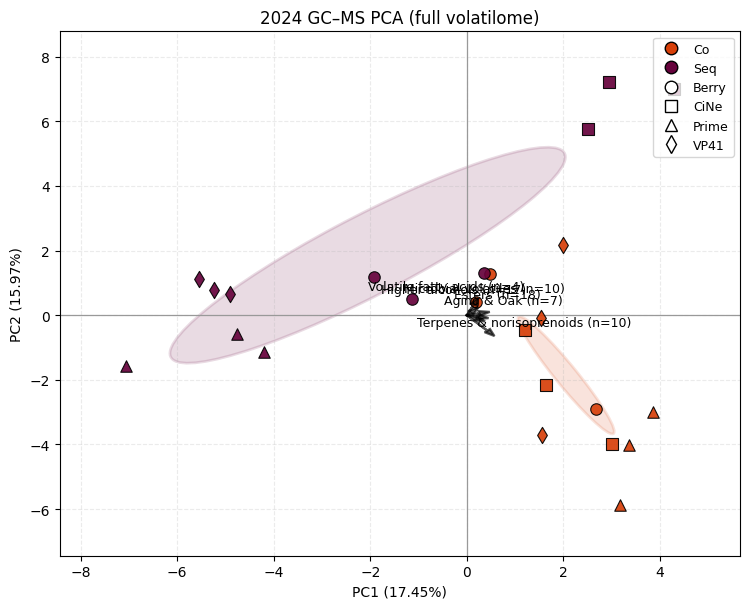

C:\Users\cinde\miniconda3\Lib\site-packages\skbio\stats\ordination\_principal_coordinate_analysis.py:157: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
C:\Users\cinde\miniconda3\Lib\site-packages\skbio\stats\ordination\_principal_coordinate_analysis.py:275: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.004204399313556706 whereas the largest positive one is 0.03830899640421159.
  warn(


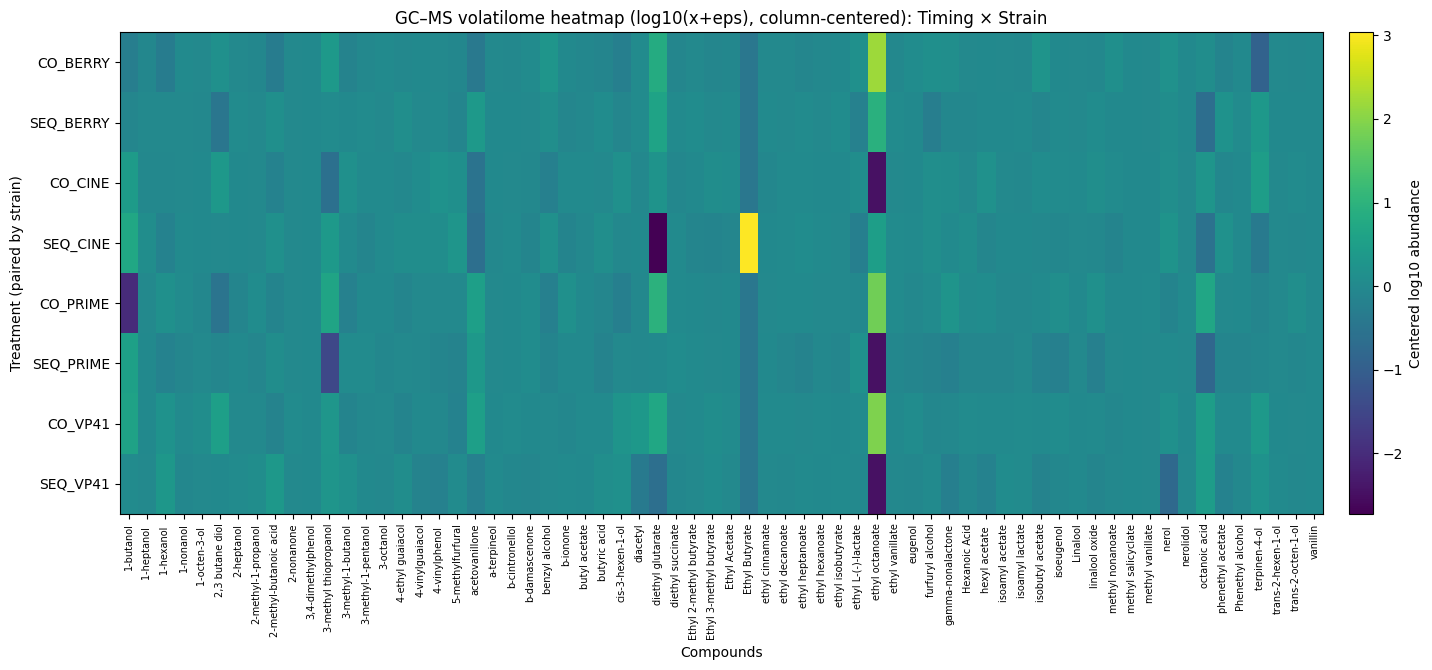

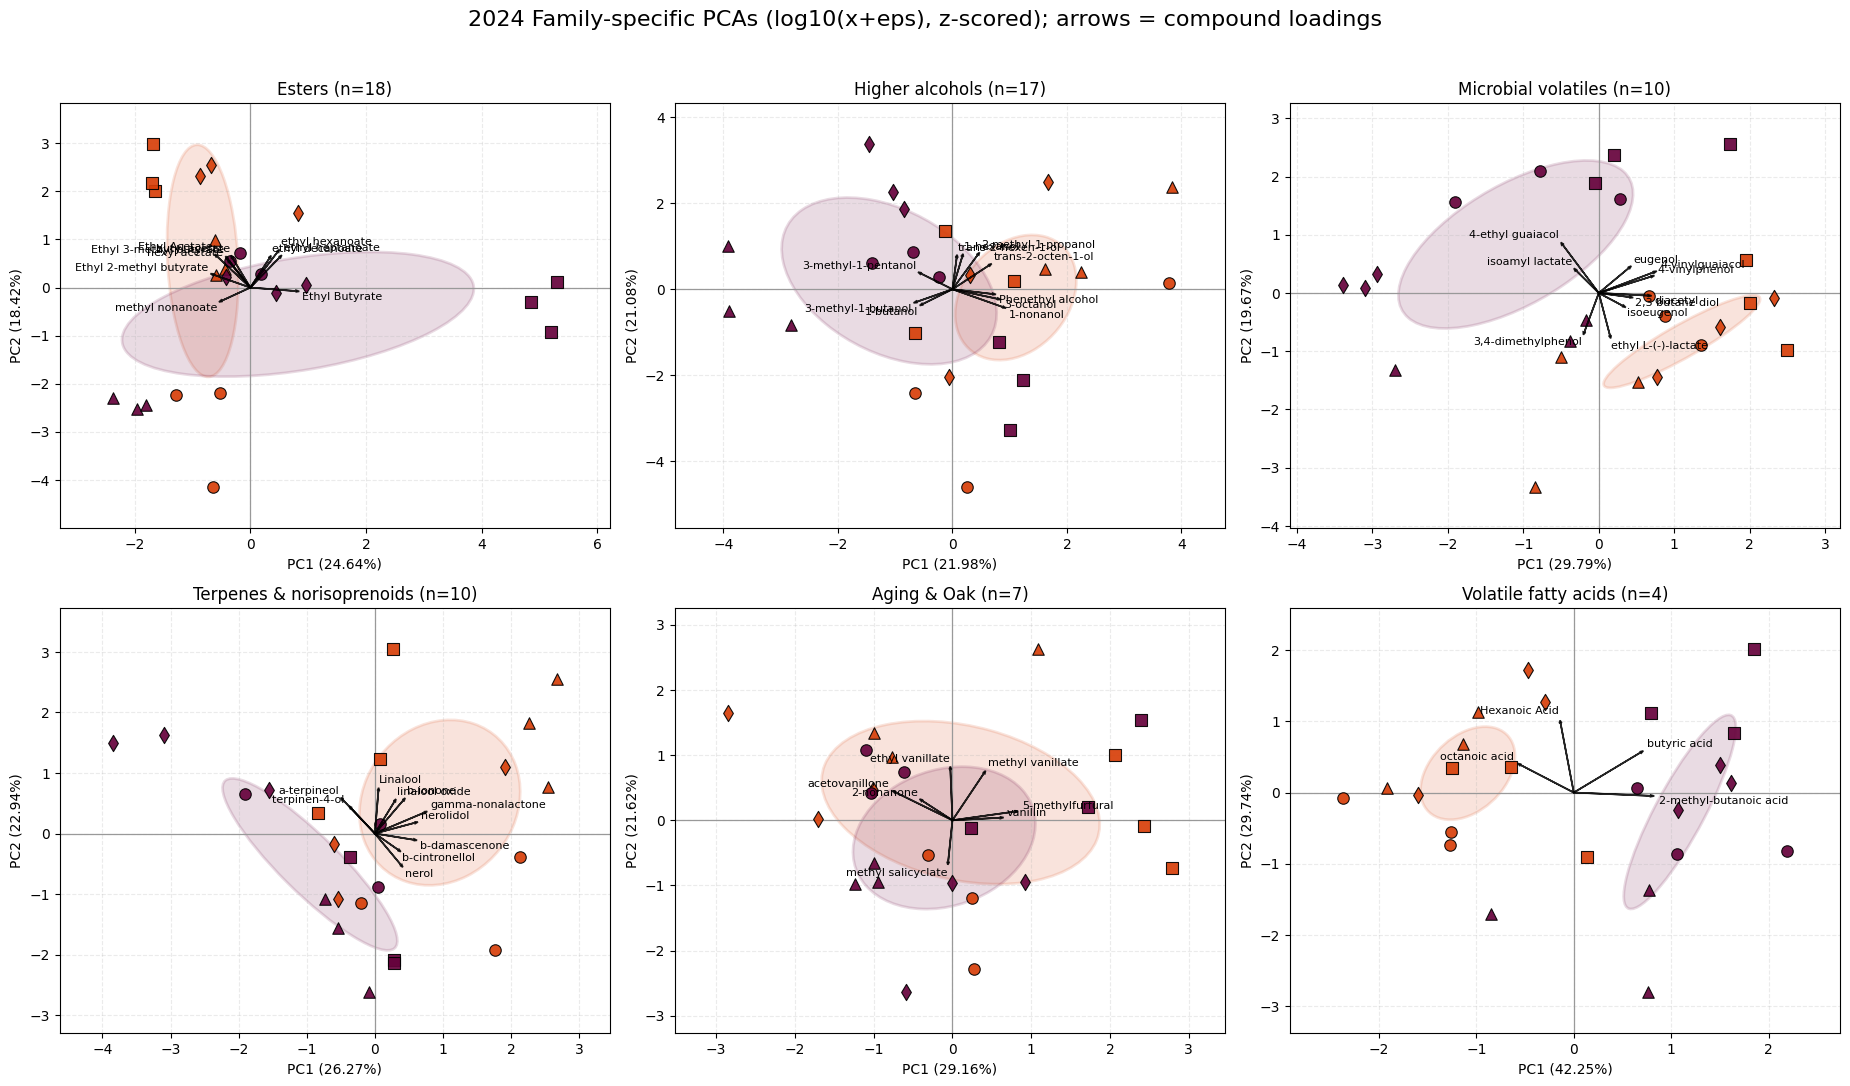

In [23]:
# ============================================================
# # Duplicate GC injections → biological replicate inference
#
# Deliverables:
#   A) Catch-all heatmap (ALL retained compounds) as a single matrix
#      (Timing×Strain), unchanged.
#   B) Full-volatilome PCA (ALL retained compounds) with LONGER
#      CHEMICAL FAMILY arrows.
#   C) Multi-panel FAMILY PCAs (per-family PCA), unchanged.
#   D) Means ± SD by treatment.
#   E) Bray–Curtis PERMANOVA on log10(x+eps), GLOBAL Timing only.
#   F) Bray–Curtis PERMDISP on log10(x+eps), GLOBAL Timing only.
#   G) Single unified audit TXT:
#        - family coverage
#        - all Grubbs-removed tech reps
#        - zero-compound filtering
#        - global PERMANOVA
#        - global PERMDISP
#        - PCA variance summary
# ============================================================

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================
# USER SETTINGS
# ============================================================

RAW_FILE = str(GCMS_FILE)
SHEET_NAME = 0
OUT_DIR = str(OUTPUT_DIR)

# Publication lock: retain true zeros, then apply log10(x + EPS) only at transform time.
EPS = GC_LOG_EPS

SAMPLEID_COL = "SampleID"

# kept outputs
MEANS_SD_CSV = str(TABLE_DIR / "gc2024_means_sd_by_treatment.csv")
PCA_FULL_PNG = str(FIGURE_DIR / "gc2024_pca_full_volatilome.png")
HEATMAP_PNG = str(FIGURE_DIR / "gc2024_heatmap_all_treatments.png")
FAMILY_PCA_MULTIPANEL_PNG = str(FIGURE_DIR / "gc2024_family_pcas_compound_arrows.png")
CLEAN_LONG_CSV = str(TABLE_DIR / "gc2024_clean_long_after_grubbs.csv")
AUDIT_TXT = str(REPORT_DIR / "gc2024_stats_audit.txt")

# ============================================================
# VISUAL ENCODING
# ============================================================

PCA_FIGSIZE = (7.6, 6.2)
PCA_POINT_SIZE = 95
PCA_EDGE_LW = 0.8
PCA_GRID_ALPHA = 0.25

SHOW_CENTROID_SD = False
SD_LW = 1.0

LABEL_TREATMENTS = False
LABEL_FONTSIZE = 8
LABEL_DX = 0.04
LABEL_DY = 0.04

ARROW_SCALE_FRAC = 0.22
FULL_PCA_FAMILY_ARROW_SCALE_MULTIPLIER = 2.4
FULL_PCA_FAMILY_LABEL_OFFSET_FRAC = 0.10

ARROW_HEAD_FRAC_W = 0.02
ARROW_HEAD_FRAC_L = 0.03
ARROW_ALPHA = 0.65
ARROW_LW = 1.0

ELLIPSE_N_STD = 1.0
ELLIPSE_ALPHA = 0.18
ELLIPSE_LW = 2.0

# ============================================================
# CHEMICAL FAMILY MAP
# ============================================================

COMPOUND_FAMILY_CANON = {
    # Higher alcohols & sulfur-containing alcohols (expanded)
    "1-Butanol": "Higher alcohols",
    "3-Methyl-1-pentanol": "Higher alcohols",
    "3-Methyl-1-butanol": "Higher alcohols",
    "1-Hexanol": "Higher alcohols",
    "trans-2-Octen-1-ol": "Higher alcohols",
    "3-Octanol": "Higher alcohols",
    "1-Octen-3-ol": "Higher alcohols",
    "2-Methyl-1-propanol": "Higher alcohols",
    "Phenethyl alcohol": "Higher alcohols",
    "Benzyl alcohol": "Higher alcohols",
    "2-Heptanol": "Higher alcohols",
    "1-Nonanol": "Higher alcohols",
    "1-Heptanol": "Higher alcohols",
    "Furfuryl alcohol": "Higher alcohols",
    "3-Methylthiopropanol": "Higher alcohols",
    "trans-2-Hexen-1-ol": "Higher alcohols",
    "cis-3-Hexen-1-ol": "Higher alcohols",

    # Esters
    "Ethyl hexanoate": "Esters",
    "Ethyl octanoate": "Esters",
    "Ethyl heptanoate": "Esters",
    "Methyl nonanoate": "Esters",
    "Ethyl decanoate": "Esters",
    "Isoamyl acetate": "Esters",
    "Isobutyl acetate": "Esters",
    "Ethyl acetate": "Esters",
    "Butyl acetate": "Esters",
    "Ethyl butyrate": "Esters",
    "Hexyl acetate": "Esters",
    "Diethyl succinate": "Esters",
    "Diethyl glutarate": "Esters",
    "Phenethyl acetate": "Esters",
    "Ethyl cinnamate": "Esters",
    "Ethyl isobutyrate": "Esters",
    "Ethyl 2-methylbutyrate": "Esters",
    "Ethyl 3-methylbutyrate": "Esters",
    "Ethyl 2-hydroxy-4-methylpentanoate": "Esters",

    # Volatile fatty acids
    "Hexanoic acid": "Volatile fatty acids",
    "Octanoic acid": "Volatile fatty acids",
    "Decanoic acid": "Volatile fatty acids",
    "Isobutyric acid": "Volatile fatty acids",
    "Butyric acid": "Volatile fatty acids",
    "3-methylbutanoic acid": "Volatile fatty acids",
    "2-methyl-butanoic acid": "Volatile fatty acids",

    # Terpenes & norisoprenoids
    "Limonene": "Terpenes & norisoprenoids",
    "α-Terpineol": "Terpenes & norisoprenoids",
    "Terpinen-4-ol": "Terpenes & norisoprenoids",
    "β-Citronellol": "Terpenes & norisoprenoids",
    "Nerolidol": "Terpenes & norisoprenoids",
    "Linalool oxide": "Terpenes & norisoprenoids",
    "Linalool": "Terpenes & norisoprenoids",
    "cis-Rose oxide": "Terpenes & norisoprenoids",
    "Nerol": "Terpenes & norisoprenoids",
    "γ-Nonalactone": "Terpenes & norisoprenoids",
    "α-Ionone": "Terpenes & norisoprenoids",
    "β-Ionone": "Terpenes & norisoprenoids",
    "β-Damascenone": "Terpenes & norisoprenoids",

    # Microbial-derived volatiles
    "Isoamyl lactate": "Microbial volatiles",
    "Ethyl L(-)-lactate": "Microbial volatiles",
    "4-Vinylphenol": "Microbial volatiles",
    "4-Ethylphenol": "Microbial volatiles",
    "3,4-Dimethylphenol": "Microbial volatiles",
    "Isoeugenol": "Microbial volatiles",
    "Eugenol": "Microbial volatiles",
    "4-Vinyl guaiacol": "Microbial volatiles",
    "4-Ethylguaiacol": "Microbial volatiles",
    "Diacetyl": "Microbial volatiles",
    "2,3-Butanediol": "Microbial volatiles",

    # Aging & Oak volatiles
    "Vanillin": "Aging & Oak",
    "Methyl vanillate": "Aging & Oak",
    "Ethyl vanillate": "Aging & Oak",
    "Acetovanillone": "Aging & Oak",
    "Methyl salicylate": "Aging & Oak",
    "Furfural": "Aging & Oak",
    "5-Methylfurfural": "Aging & Oak",
    "2-Nonanone": "Aging & Oak",
    "cis-whiskey lactone": "Aging & Oak",
}

# ============================================================
# NAME NORMALIZATION
# ============================================================

_GREEK_MAP = {
    "α": "a", "β": "b", "γ": "gamma",
    "Α": "a", "Β": "b", "Γ": "gamma",
}

def _norm_name(s: str) -> str:
    s = str(s).strip()
    for g, r in _GREEK_MAP.items():
        s = s.replace(g, r)
    s = s.lower()
    s = re.sub(r"\s+", " ", s)
    s = s.replace("–", "-").replace("—", "-").replace("_", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    s = s.replace("  ", " ")
    s = re.sub(r"[^\w\-\(\), ]+", "", s)
    s = s.replace(" ", "")
    return s

ALIASES = {
    _norm_name("2,3 butane diol"): _norm_name("2,3-Butanediol"),
    _norm_name("b-cintronellol"): _norm_name("b-Citronellol"),
    _norm_name("cis-rose-oxide"): _norm_name("cis-Rose oxide"),
    _norm_name("cis-whiskey lactone"): _norm_name("cis-Whisky lactone"),
    _norm_name("ethyl L-(-)-lactate"): _norm_name("Ethyl L(-)-lactate"),
    _norm_name("ethyl-2-hydroxy-4-methylpentanoate"): _norm_name("Ethyl 2-hydroxy-4-methylpentanoate"),
    _norm_name("methyl salicyclate"): _norm_name("Methyl salicylate"),
}

def build_family_map_for_dataframe_columns(df_cols, canon_map):
    canon_norm = {_norm_name(k): k for k in canon_map.keys()}
    col_to_family = {}
    unmatched = []
    for col in df_cols:
        n = _norm_name(col)
        n = ALIASES.get(n, n)
        if n in canon_norm:
            canon_key = canon_norm[n]
            col_to_family[col] = canon_map[canon_key]
        else:
            unmatched.append(col)
    return col_to_family, unmatched

# ============================================================
# SAMPLE ID PARSING
# Expected format: "SeqPrime 1.1"
# ============================================================

PAT = re.compile(
    r"^(Co|Seq)\s*(Berry|CiNe|Prime|VP41)[\s\-_]*(\d+)[\.\-_](\d+)$",
    re.I
)

def canon_strain(x: str) -> str:
    s = str(x).strip()
    k = s.lower()
    return {
        "berry": "BERRY",
        "cine": "CINE",
        "prime": "PRIME",
        "vp41": "VP41",
        "vp-41": "VP41",
        "vp_41": "VP41",
    }.get(k, s.upper())

def parse_sample_id(sample_id: str) -> dict:
    s = str(sample_id).strip()
    m = PAT.match(s)
    if not m:
        raise ValueError(
            f"SampleID '{sample_id}' does not match an accepted format. "
            f"Examples: 'CoVP41 1.2', 'CoVP41-1-2', 'SeqCiNe 2.1', 'SeqCiNe-2-1'."
        )

    timing = m.group(1).upper()
    strain = canon_strain(m.group(2))
    gc_rep = int(m.group(3))
    bio_rep = int(m.group(4))

    return {
        "Timing": timing,
        "Strain": strain,
        "GC_rep": gc_rep,
        "Bio_rep": bio_rep,
        "Treatment": f"{timing}_{strain}",
    }

# ============================================================
# GRUBBS HELPERS
# ============================================================

def grubbs_critical_value(n, alpha=0.05):
    if n < 3:
        return np.nan
    tcrit = t.ppf(1 - alpha / (2 * n), df=n - 2)
    return ((n - 1) / np.sqrt(n)) * np.sqrt(tcrit**2 / (n - 2 + tcrit**2))

def significance_stars(p):
    if pd.isna(p):
        return "NA"
    if p <= 1e-4:
        return "****"
    if p <= 1e-3:
        return "***"
    if p <= 1e-2:
        return "**"
    if p <= 5e-2:
        return "*"
    return "ns"

# ============================================================
# ELLIPSE HELPER
# ============================================================

def add_group_ellipse(ax, x, y, edgecolor="black", n_std=1.0, linewidth=2.0, alpha=0.18, zorder=0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if x.size < 3:
        return None

    cov = np.cov(x, y)
    if not np.isfinite(cov).all():
        return None

    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals = np.maximum(vals[order], 0.0)
    vecs = vecs[:, order]

    width = 2 * n_std * np.sqrt(vals[0])
    height = 2 * n_std * np.sqrt(vals[1])
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    ell = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        facecolor=edgecolor,
        edgecolor=edgecolor,
        linewidth=linewidth,
        alpha=alpha,
        zorder=zorder
    )
    ax.add_patch(ell)
    return ell

# ============================================================
# INPUT / PREPROCESSING
# ============================================================

def read_gcms_table(path, sheet=0):
    if str(path).lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(path, sheet_name=sheet)
    return pd.read_csv(path)

def add_metadata_from_sampleid(df):
    if SAMPLEID_COL not in df.columns:
        raise KeyError(f"Expected a '{SAMPLEID_COL}' column in the input table.")
    parsed = df[SAMPLEID_COL].apply(parse_sample_id)
    meta = pd.DataFrame(parsed.tolist(), index=df.index)

    out = pd.concat([df, meta], axis=1)
    out["Timing"] = out["Timing"].astype(str).str.upper()
    out["Strain"] = out["Strain"].astype(str).apply(canon_strain)
    out["Treatment"] = out["Treatment"].astype(str)
    return out

def infer_compound_columns(df):
    meta = {SAMPLEID_COL, "Timing", "Strain", "Treatment", "GC_rep", "Bio_rep"}
    cols = []
    for c in df.columns:
        if c in meta:
            continue
        s = pd.to_numeric(df[c], errors="coerce")
        if s.notna().any():
            cols.append(c)
    if not cols:
        raise ValueError("No numeric compound columns inferred.")
    return cols

# ============================================================
# FAMILY COVERAGE
# ============================================================

def get_family_coverage_lines(compound_cols, compound_to_family):
    fam_counts = {}
    unassigned = []

    for c in compound_cols:
        fam = compound_to_family.get(c, "Unassigned")
        fam_counts[fam] = fam_counts.get(fam, 0) + 1
        if fam == "Unassigned":
            unassigned.append(c)

    fam_counts_sorted = dict(sorted(fam_counts.items(), key=lambda kv: kv[1], reverse=True))

    lines = []
    lines.append("=== FAMILY COVERAGE REPORT (2024) ===")
    lines.append(f"Total compounds inferred: {len(compound_cols)}")
    lines.append("Counts by family:")
    for fam, n in fam_counts_sorted.items():
        lines.append(f"  {fam}: {n}")

    if unassigned:
        lines.append("")
        lines.append("Unassigned compounds (still retained unless removed later by zero-filter):")
        for c in unassigned:
            lines.append(f"  - {c}")
    else:
        lines.append("")
        lines.append("No unassigned compounds.")

    return lines

# ============================================================
# APPLY GRUBBS FILTER TO TECH REPS
# ============================================================

def remove_grubbs_outliers_from_raw(df, compound_cols, alpha=0.05, max_outliers=1):
    """
    Remove Grubbs-detected outlier technical injections within each:
        Timing × Strain × Treatment × Bio_rep
    separately for each compound.

    Returns:
        clean_long : retained long table
        removed_log : detailed removed tech reps
    """
    retained_rows = []
    removed_rows = []
    group_cols = ["Timing", "Strain", "Treatment", "Bio_rep"]

    for (tim, st, trt, bio), g in df.groupby(group_cols, sort=False):
        g = g.copy().reset_index(drop=True)

        for comp in compound_cols:
            sub = g[[SAMPLEID_COL, "GC_rep", comp]].copy()
            sub[comp] = pd.to_numeric(sub[comp], errors="coerce")
            sub = sub.dropna(subset=[comp]).reset_index(drop=True)

            if sub.empty:
                continue

            vals = sub[comp].to_numpy(dtype=float)
            keep_mask = np.ones(len(vals), dtype=bool)

            n_initial = len(vals)
            removed_count = 0

            # Only run Grubbs when >= 3 tech reps remain
            while keep_mask.sum() >= 3 and removed_count < max_outliers:
                active_idx = np.where(keep_mask)[0]
                x = vals[active_idx]

                mu = np.mean(x)
                sd = np.std(x, ddof=1)

                if (not np.isfinite(sd)) or sd == 0:
                    break

                dev = np.abs(x - mu)
                local_max = np.argmax(dev)
                global_idx = active_idx[local_max]

                G = dev[local_max] / sd
                Gcrit = grubbs_critical_value(len(x), alpha=alpha)

                if np.isfinite(Gcrit) and (G > Gcrit):
                    keep_mask[global_idx] = False
                    removed_count += 1

                    removed_rows.append({
                        "Timing": tim,
                        "Strain": st,
                        "Treatment": trt,
                        "Bio_rep": bio,
                        "GC_rep": int(sub.loc[global_idx, "GC_rep"]),
                        "SampleID": str(sub.loc[global_idx, SAMPLEID_COL]),
                        "Compound": comp,
                        "Removed_value": float(vals[global_idx]),
                        "G": float(G),
                        "Gcrit": float(Gcrit),
                        "n_initial": int(n_initial),
                        "n_remaining_after_removal": int(keep_mask.sum()),
                    })
                else:
                    break

            kept = sub.loc[keep_mask].copy()

            for _, r in kept.iterrows():
                retained_rows.append({
                    "Timing": tim,
                    "Strain": st,
                    "Treatment": trt,
                    "Bio_rep": bio,
                    "GC_rep": int(r["GC_rep"]),
                    "SampleID": str(r[SAMPLEID_COL]),
                    "Compound": comp,
                    "Value": float(r[comp]),
                })

    clean_long = pd.DataFrame(retained_rows)
    removed_log = pd.DataFrame(removed_rows)

    if clean_long.empty:
        raise ValueError("No data remained after Grubbs filtering. Check parsing and numeric columns.")

    return clean_long, removed_log

# ============================================================
# COLLAPSE CLEANED LONG TABLE TO BIO REPLICATE MEANS
# ============================================================

def collapse_cleaned_long_to_bio(clean_long):
    req = {"Timing", "Strain", "Treatment", "Bio_rep", "GC_rep", "Compound", "Value"}
    missing = req - set(clean_long.columns)
    if missing:
        raise KeyError(f"collapse_cleaned_long_to_bio: missing columns: {sorted(missing)}")

    bio_long = (
        clean_long
        .groupby(["Timing", "Strain", "Treatment", "Bio_rep", "Compound"], as_index=False)["Value"]
        .mean()
    )

    bio = (
        bio_long
        .pivot_table(
            index=["Timing", "Strain", "Treatment", "Bio_rep"],
            columns="Compound",
            values="Value",
            aggfunc="mean"
        )
        .reset_index()
    )

    bio.columns.name = None
    bio.columns = [str(c) for c in bio.columns]
    return bio

# ============================================================
# ZERO FILTER (POST-GRUBBS / POST-COLLAPSE)
# ============================================================
# Compounds are removed only if every post-collapse biological mean is zero or missing.
# For this filter decision, missing values are treated as zero by design.

def drop_all_zero_compounds_post_collapse(bio, compound_cols):
    keep = []
    removed = []

    for c in compound_cols:
        s = pd.to_numeric(bio[c], errors="coerce") if c in bio.columns else pd.Series(dtype=float)
        # Publication lock: treat NaN as zero only for the all-zero filter decision.
        s_filled = s.fillna(0.0 if GC_ZERO_FILTER_NA_AS_ZERO else np.nan)
        if np.isclose(s_filled.to_numpy(dtype=float), 0.0).all():
            removed.append(c)
        else:
            keep.append(c)

    bio_filtered = bio[["Timing", "Strain", "Treatment", "Bio_rep"] + keep].copy()
    return bio_filtered, keep, removed

# ============================================================
# MEANS / SD TABLES
# ============================================================

def mean_sd_table(bio, compound_cols):
    g = bio.groupby(["Timing", "Strain", "Treatment"], as_index=False)
    mean = g[compound_cols].mean().rename(columns={c: f"{c}_mean" for c in compound_cols})
    sd = g[compound_cols].std(ddof=1).rename(columns={c: f"{c}_sd" for c in compound_cols})
    n = g.size().rename(columns={"size": "n_bio"})
    return mean.merge(sd, on=["Timing", "Strain", "Treatment"]).merge(n, on=["Timing", "Strain", "Treatment"])

# ============================================================
# MULTIVARIATE CORE
# ============================================================

def pca_fit_scores(bio, cols, eps=EPS):
    X = np.log10(bio[cols].to_numpy(float) + eps)
    Z = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=0)
    scores = pca.fit_transform(Z)
    var = pca.explained_variance_ratio_
    return scores, pca, var

def bray_curtis_dm(bio, compound_cols, eps=EPS):
    X = np.log10(bio[compound_cols].to_numpy(float) + eps)
    D = squareform(pdist(X, metric="braycurtis"))
    return DistanceMatrix(D, ids=bio.index.astype(str).tolist())

# ============================================================
# LOADINGS → ARROWS
# ============================================================

def compute_loadings_df(pca_model, feature_names):
    comps = pca_model.components_
    if comps.shape[0] < 2:
        raise ValueError("Need at least 2 PCs for biplot arrows.")
    return pd.DataFrame(
        {"PC1_loading": comps[0, :], "PC2_loading": comps[1, :]},
        index=pd.Index(feature_names, name="Feature")
    )

def family_vectors_from_loadings(loadings_df, compound_to_family, method="mean", drop_unassigned=True):
    df = loadings_df.copy()
    df["Family"] = [compound_to_family.get(c, "Unassigned") for c in df.index]

    rows = []
    for fam, g in df.groupby("Family"):
        if drop_unassigned and fam == "Unassigned":
            continue

        if method == "sum":
            v1, v2 = g["PC1_loading"].sum(), g["PC2_loading"].sum()
        elif method == "median":
            v1, v2 = g["PC1_loading"].median(), g["PC2_loading"].median()
        else:
            v1, v2 = g["PC1_loading"].mean(), g["PC2_loading"].mean()

        rows.append({
            "Family": fam,
            "PC1_vec": float(v1),
            "PC2_vec": float(v2),
            "n_compounds": int(g.shape[0]),
            "strength": float(np.sqrt(v1*v1 + v2*v2)),
        })

    return pd.DataFrame(rows).set_index("Family").sort_values("strength", ascending=False)

def add_family_arrows(ax, family_vecs, base_scale, top_k=8, label_offsets=None, label_offset_frac=0.06):
    if label_offsets is None:
        label_offsets = {}

    fv = family_vecs.copy()
    if top_k is not None:
        fv = fv.head(int(top_k))

    default_label_step = label_offset_frac * base_scale
    default_along = 1.10

    for fam, r in fv.iterrows():
        dx = float(r["PC1_vec"]) * base_scale
        dy = float(r["PC2_vec"]) * base_scale

        ax.arrow(
            0, 0, dx, dy,
            length_includes_head=True,
            head_width=ARROW_HEAD_FRAC_W * base_scale,
            head_length=ARROW_HEAD_FRAC_L * base_scale,
            linewidth=1.6,
            color="black",
            alpha=ARROW_ALPHA,
            zorder=4
        )

        v = np.array([dx, dy], float)
        vn = np.linalg.norm(v)
        perp = np.array([0.0, 0.0]) if vn == 0 else np.array([-v[1], v[0]]) / vn

        tx = dx * default_along + perp[0] * default_label_step
        ty = dy * default_along + perp[1] * default_label_step

        if fam in label_offsets:
            ox, oy = label_offsets[fam]
            tx += ox
            ty += oy

        ax.text(
            tx, ty,
            f"{fam} (n={int(r['n_compounds'])})",
            fontsize=9,
            ha="center", va="center",
            zorder=5
        )

def add_compound_arrows(ax, loadings_df, base_scale, top_k=10):
    L = loadings_df.copy()
    L["strength"] = np.sqrt(L["PC1_loading"]**2 + L["PC2_loading"]**2)
    L = L.sort_values("strength", ascending=False)
    if top_k is not None:
        L = L.head(int(top_k))

    for comp, r in L.iterrows():
        x = float(r["PC1_loading"]) * base_scale
        y = float(r["PC2_loading"]) * base_scale

        ax.arrow(
            0, 0, x, y,
            length_includes_head=True,
            head_width=ARROW_HEAD_FRAC_W * base_scale,
            head_length=ARROW_HEAD_FRAC_L * base_scale,
            linewidth=1.2,
            color="black",
            alpha=0.85,
            zorder=4
        )
        ax.text(
            x * 1.06, y * 1.06,
            str(comp),
            fontsize=8,
            ha="left" if x >= 0 else "right",
            va="bottom" if y >= 0 else "top",
            zorder=5
        )

# ============================================================
# PCA PLOTTING
# ============================================================

def build_scores_df(bio, scores):
    sdf = bio[["Timing", "Strain", "Treatment", "Bio_rep"]].copy()
    sdf["Timing"] = sdf["Timing"].astype(str).str.upper()
    sdf["Strain"] = sdf["Strain"].astype(str).apply(canon_strain)
    sdf["Treatment"] = sdf["Treatment"].astype(str)
    sdf["PC1"] = scores[:, 0]
    sdf["PC2"] = scores[:, 1]
    return sdf

def pca_centroids(scores_df):
    cent = (
        scores_df.groupby(["Treatment", "Timing", "Strain"], as_index=False)
                 .agg(
                     PC1_mean=("PC1", "mean"),
                     PC2_mean=("PC2", "mean"),
                     PC1_sd=("PC1", "std"),
                     PC2_sd=("PC2", "std"),
                 )
    )
    cent["Strain"] = pd.Categorical(cent["Strain"], INOCULUM_ORDER, ordered=True)
    cent["Timing"] = pd.Categorical(cent["Timing"], TIMING_ORDER, ordered=True)
    return cent.sort_values(["Timing", "Strain"])

def plot_pca_centroids_with_timing_ellipses(
    ax,
    sdf_raw,
    cent,
    var_ratio=None,
    title=None,
    add_legend=True,
    legend_loc="upper right",
    label_treatments=LABEL_TREATMENTS,
    show_centroid_sd=SHOW_CENTROID_SD,
):
    for timing in TIMING_ORDER:
        sub = cent.loc[cent["Timing"].astype(str) == timing, ["PC1_mean", "PC2_mean"]].copy()
        if sub.shape[0] < 3:
            continue

        add_group_ellipse(
            ax,
            sub["PC1_mean"].to_numpy(float),
            sub["PC2_mean"].to_numpy(float),
            edgecolor=TIMING_COLORS.get(timing, "0.5"),
            n_std=1.0,
            linewidth=ELLIPSE_LW,
            alpha=0.14,
            zorder=1
        )

    rep = (
        sdf_raw.groupby(["Treatment", "Timing", "Strain", "Bio_rep"], as_index=False)
               .agg(
                   PC1_rep=("PC1", "mean"),
                   PC2_rep=("PC2", "mean"),
               )
               .sort_values(["Timing", "Strain", "Bio_rep"])
    )

    for _, r in rep.iterrows():
        timing = str(r["Timing"])
        strain = str(r["Strain"])
        x0, y0 = float(r["PC1_rep"]), float(r["PC2_rep"])

        ax.scatter(
            x0, y0,
            s=PCA_POINT_SIZE * 0.72,
            c=TIMING_COLORS.get(timing, "0.6"),
            marker=LAB_MARKERS.get(strain, "o"),
            edgecolor="black",
            linewidth=PCA_EDGE_LW,
            alpha=0.92,
            zorder=3
        )

    for _, r in cent.iterrows():
        x0, y0 = float(r["PC1_mean"]), float(r["PC2_mean"])

        if show_centroid_sd:
            if pd.notna(r.get("PC1_sd", np.nan)):
                dx = float(r["PC1_sd"])
                ax.plot([x0 - dx, x0 + dx], [y0, y0], color="black", lw=SD_LW, zorder=2)
            if pd.notna(r.get("PC2_sd", np.nan)):
                dy = float(r["PC2_sd"])
                ax.plot([x0, x0], [y0 - dy, y0 + dy], color="black", lw=SD_LW, zorder=2)

        if label_treatments:
            ax.text(
                x0 + LABEL_DX,
                y0 + LABEL_DY,
                str(r["Treatment"]),
                fontsize=LABEL_FONTSIZE,
                zorder=4
            )

    ax.axhline(0, color="0.6", lw=0.9)
    ax.axvline(0, color="0.6", lw=0.9)
    ax.grid(alpha=PCA_GRID_ALPHA, linestyle="--")

    xvals = np.concatenate([rep["PC1_rep"].to_numpy(float), cent["PC1_mean"].to_numpy(float)])
    yvals = np.concatenate([rep["PC2_rep"].to_numpy(float), cent["PC2_mean"].to_numpy(float)])
    m = np.isfinite(xvals) & np.isfinite(yvals)
    if m.any():
        xvals = xvals[m]
        yvals = yvals[m]
        xmin, xmax = float(np.min(xvals)), float(np.max(xvals))
        ymin, ymax = float(np.min(yvals)), float(np.max(yvals))
        xspan = max(xmax - xmin, 1.0)
        yspan = max(ymax - ymin, 1.0)
        ax.set_xlim(xmin - 0.12 * xspan, xmax + 0.12 * xspan)
        ax.set_ylim(ymin - 0.12 * yspan, ymax + 0.12 * yspan)

    if var_ratio is not None and len(var_ratio) >= 2:
        ax.set_xlabel(f"PC1 ({var_ratio[0]*100:.2f}%)")
        ax.set_ylabel(f"PC2 ({var_ratio[1]*100:.2f}%)")
    else:
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")

    if title:
        ax.set_title(title)

    if add_legend:
        from matplotlib.lines import Line2D

        timing_handles = [
            Line2D([0], [0], marker="o", linestyle="",
                   markerfacecolor=TIMING_COLORS["CO"], markeredgecolor="black",
                   markersize=9, label="Co"),
            Line2D([0], [0], marker="o", linestyle="",
                   markerfacecolor=TIMING_COLORS["SEQ"], markeredgecolor="black",
                   markersize=9, label="Seq"),
        ]

        strain_handles = []
        for k in ["BERRY", "CINE", "PRIME", "VP41"]:
            strain_handles.append(
                Line2D([0], [0], marker=LAB_MARKERS[k], linestyle="",
                       markerfacecolor="white", markeredgecolor="black",
                       markersize=9, label=STRAIN_LABELS[k])
            )

        ax.legend(
            handles=(timing_handles + strain_handles),
            loc=legend_loc,
            frameon=True,
            fontsize=9
        )

# ============================================================
# FULL PCA + FAMILY ARROWS
# ============================================================

def plot_full_pca_with_family_arrows(
    bio,
    compound_cols,
    compound_to_family,
    out_png=PCA_FULL_PNG,
    eps=EPS,
    show=True,
    family_method="mean",
    family_top_k=6,
):
    scores, pca_model, var = pca_fit_scores(bio, compound_cols, eps=eps)
    sdf = build_scores_df(bio, scores)
    cent = pca_centroids(sdf)

    fig, ax = plt.subplots(figsize=PCA_FIGSIZE)
    plot_pca_centroids_with_timing_ellipses(
        ax,
        sdf_raw=sdf,
        cent=cent,
        var_ratio=var,
        title="2024 GC–MS PCA (full volatilome)",
        add_legend=True,
        legend_loc="upper right",
        label_treatments=LABEL_TREATMENTS,
        show_centroid_sd=SHOW_CENTROID_SD,
    )

    xspan = ax.get_xlim()[1] - ax.get_xlim()[0]
    yspan = ax.get_ylim()[1] - ax.get_ylim()[0]
    base = min(xspan, yspan) * ARROW_SCALE_FRAC * FULL_PCA_FAMILY_ARROW_SCALE_MULTIPLIER

    loadings = compute_loadings_df(pca_model, compound_cols)
    fam_vecs = family_vectors_from_loadings(
        loadings,
        compound_to_family,
        method=family_method,
        drop_unassigned=True
    )

    add_family_arrows(
        ax,
        fam_vecs,
        base_scale=base,
        top_k=family_top_k,
        label_offsets=None,
        label_offset_frac=FULL_PCA_FAMILY_LABEL_OFFSET_FRAC
    )

    plt.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

    return pca_model, var

# ============================================================
# HEATMAP
# ============================================================

def center_by_column(X):
    return X - X.mean(axis=0)

def build_treatment_matrix_for_heatmap(bio, compound_cols, eps=EPS):
    expected = []
    for s in INOCULUM_ORDER:
        expected.append(f"CO_{s}")
        expected.append(f"SEQ_{s}")

    mean_tbl = (
        bio.groupby("Treatment", as_index=True)[compound_cols]
        .mean()
        .reindex(expected)
    )

    Xlog = np.log10(mean_tbl.astype(float) + eps)
    Xc = center_by_column(Xlog)
    return Xc

def plot_heatmap_single(
    bio,
    compound_cols,
    out_png,
    eps=EPS,
    show=False
):
    Xc = build_treatment_matrix_for_heatmap(bio, compound_cols, eps=eps)

    fig, ax = plt.subplots(figsize=(14.5, 6.8))
    im = ax.imshow(Xc.values, aspect="auto", interpolation="nearest")

    ax.set_title("GC–MS volatilome heatmap (log10(x+eps), column-centered): Timing × Strain")
    ax.set_ylabel("Treatment (paired by strain)")
    ax.set_xlabel("Compounds")

    ax.set_yticks(np.arange(Xc.shape[0]))
    ax.set_yticklabels(Xc.index.tolist())

    xticks = np.arange(len(compound_cols))
    ax.set_xticks(xticks)
    ax.set_xticklabels(compound_cols, rotation=90, fontsize=7)

    fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02, label="Centered log10 abundance")

    fig.tight_layout()
    fig.savefig(out_png, dpi=300)
    if show:
        plt.show()
    plt.close(fig)

# ============================================================
# MULTI-PANEL FAMILY PCAs
# ============================================================

def get_families_for_compounds(compound_cols, compound_to_family):
    fams = {}
    for c in compound_cols:
        fam = compound_to_family.get(c, "Unassigned")
        fams.setdefault(fam, []).append(c)
    return fams

def plot_family_pcas_multipanel(
    bio,
    compound_cols,
    compound_to_family,
    out_png=FAMILY_PCA_MULTIPANEL_PNG,
    eps=EPS,
    show=True,
    min_compounds=3,
    arrows_top_k=10,
    include_unassigned=False
):
    fam_map = get_families_for_compounds(compound_cols, compound_to_family)

    items = []
    for fam, cols in fam_map.items():
        if not include_unassigned and fam == "Unassigned":
            continue
        if len(cols) >= min_compounds:
            items.append((fam, cols))

    if len(items) == 0:
        raise ValueError("No families have enough compounds for PCA. Check COMPOUND_FAMILY coverage or min_compounds.")

    items.sort(key=lambda x: len(x[1]), reverse=True)

    n = len(items)
    ncols = 3 if n >= 3 else n
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2*ncols, 5.3*nrows))
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    for idx, (fam, cols) in enumerate(items):
        r = idx // ncols
        c = idx % ncols
        ax = axes[r, c]

        scores, pca_model, var = pca_fit_scores(bio, cols, eps=eps)
        sdf = build_scores_df(bio, scores)
        cent = pca_centroids(sdf)

        plot_pca_centroids_with_timing_ellipses(
            ax,
            sdf_raw=sdf,
            cent=cent,
            var_ratio=var,
            title=f"{fam} (n={len(cols)})",
            add_legend=False,
            label_treatments=False,
            show_centroid_sd=False,
        )

        ax.relim()
        ax.autoscale_view()
        xspan = ax.get_xlim()[1] - ax.get_xlim()[0]
        yspan = ax.get_ylim()[1] - ax.get_ylim()[0]
        base = min(xspan, yspan) * ARROW_SCALE_FRAC

        L = compute_loadings_df(pca_model, cols)
        add_compound_arrows(ax, L, base_scale=base, top_k=arrows_top_k)

    for k in range(len(items), nrows*ncols):
        r = k // ncols
        c = k % ncols
        axes[r, c].axis("off")

    fig.suptitle("2024 Family-specific PCAs (log10(x+eps), z-scored); arrows = compound loadings",
                 fontsize=16, y=1.02)

    plt.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

# ============================================================
# AUDIT WRITING
# ============================================================

def augment_removed_log_with_collapsed_means(removed_log, bio):
    if removed_log.empty:
        removed_log = removed_log.copy()
        removed_log["Collapsed_bio_mean_post_Grubbs"] = []
        return removed_log

    bio_long = (
        bio.melt(
            id_vars=["Timing", "Strain", "Treatment", "Bio_rep"],
            var_name="Compound",
            value_name="Collapsed_bio_mean_post_Grubbs"
        )
    )

    out = removed_log.merge(
        bio_long,
        on=["Timing", "Strain", "Treatment", "Bio_rep", "Compound"],
        how="left"
    )
    return out

def write_stats_audit(
    filepath,
    df_raw,
    compound_cols_initial,
    compound_cols_final,
    family_coverage_lines,
    removed_log_aug,
    removed_zero_compounds,
    permanova_res,
    permdisp_res,
    pca_var,
):
    lines = []
    lines.append("GC–MS 2024 STATS AUDIT")
    lines.append("=" * 72)
    lines.append("")
    lines.append("[1] Run metadata")
    lines.append(f"Raw input rows: {df_raw.shape[0]}")
    lines.append(f"Initial inferred compounds: {len(compound_cols_initial)}")
    lines.append(f"Retained compounds after post-collapse zero filter: {len(compound_cols_final)}")
    lines.append(f"Transformation for multivariate analyses: log10(x + {EPS})")
    lines.append("Zero policy: true zeros retained through preprocessing; no blanket zero-to-NaN conversion.")
    lines.append("Distance metric: Bray–Curtis")
    lines.append(f"Permutations: {PERMUTATIONS}")
    lines.append(f"Grubbs alpha: {ALPHA}")
    lines.append("Inferential scope: GLOBAL Timing only (CO vs SEQ)")
    lines.append("")

    lines.append("[2] Family coverage")
    lines.extend(family_coverage_lines)
    lines.append("")

    lines.append("[3] Grubbs full removal log (technical replicate layer)")
    if removed_log_aug.empty:
        lines.append("No technical replicate outliers were removed by Grubbs.")
    else:
        lines.append(f"Total removed technical replicates: {removed_log_aug.shape[0]}")
        lines.append("")
        lines.append(
            "Timing\tStrain\tTreatment\tBio_rep\tGC_rep\tSampleID\tCompound\tRemoved_value\tG\tGcrit\t"
            "n_initial\tn_remaining_after_removal\tCollapsed_bio_mean_post_Grubbs"
        )
        for _, r in removed_log_aug.sort_values(
            ["Timing", "Strain", "Bio_rep", "Compound", "GC_rep"]
        ).iterrows():
            lines.append(
                f"{r['Timing']}\t{r['Strain']}\t{r['Treatment']}\t{int(r['Bio_rep'])}\t{int(r['GC_rep'])}\t"
                f"{r['SampleID']}\t{r['Compound']}\t"
                f"{float(r['Removed_value']):.6g}\t{float(r['G']):.6g}\t{float(r['Gcrit']):.6g}\t"
                f"{int(r['n_initial'])}\t{int(r['n_remaining_after_removal'])}\t"
                f"{float(r['Collapsed_bio_mean_post_Grubbs']):.6g}"
            )

        lines.append("")
        lines.append("Removed-count summary by compound:")
        comp_counts = (
            removed_log_aug["Compound"]
            .value_counts()
            .sort_values(ascending=False)
        )
        for comp, n in comp_counts.items():
            lines.append(f"  {comp}: {int(n)}")

    lines.append("")
    lines.append("[4] Zero filter (post-Grubbs, post-collapse)")
    if removed_zero_compounds:
        lines.append("Removed compounds with all-zero / all-missing biological means:")
        for c in removed_zero_compounds:
            lines.append(f"  - {c}")
    else:
        lines.append("No compounds were removed by the all-zero post-collapse filter.")

    lines.append("")
    lines.append("[5] Global PERMANOVA (Timing: CO vs SEQ)")
    p_perm = float(permanova_res["p-value"])
    F_perm = float(permanova_res["test statistic"])
    lines.append(f"pseudo-F: {F_perm:.6f}")
    lines.append(f"p-value: {p_perm:.6g} {significance_stars(p_perm)}")

    lines.append("")
    lines.append("[6] Global PERMDISP (Timing: CO vs SEQ)")
    p_disp = float(permdisp_res["p-value"])
    F_disp = float(permdisp_res["test statistic"])
    lines.append(f"F-value: {F_disp:.6f}")
    lines.append(f"p-value: {p_disp:.6g} {significance_stars(p_disp)}")
    if p_disp <= 0.05:
        lines.append(
            "Interpretation note: significant dispersion difference detected; "
            "PERMANOVA may reflect both centroid separation and dispersion effects."
        )
    else:
        lines.append(
            "Interpretation note: no significant dispersion difference detected at alpha = 0.05."
        )

    lines.append("")
    lines.append("[7] Full PCA variance summary")
    lines.append(f"PC1: {pca_var[0]:.6f} ({pca_var[0]*100:.3f}%)")
    lines.append(f"PC2: {pca_var[1]:.6f} ({pca_var[1]*100:.3f}%)")
    lines.append(f"PC1 + PC2: {(pca_var[0] + pca_var[1]):.6f} ({(pca_var[0] + pca_var[1])*100:.3f}%)")
    lines.append("")

    with open(filepath, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

# ============================================================
# MAIN
# ============================================================

def run_gcms_pipeline_2024(show_plots=True):
    # 1) read + parse metadata
    df_raw = read_gcms_table(RAW_FILE, SHEET_NAME)
    df_raw = add_metadata_from_sampleid(df_raw)

    # 2) infer ALL compound columns
    compound_cols_initial = infer_compound_columns(df_raw)
    col_to_family_initial, unmatched_initial = build_family_map_for_dataframe_columns(
        compound_cols_initial, COMPOUND_FAMILY_CANON
    )

    # 3) family coverage lines
    family_coverage_lines = get_family_coverage_lines(compound_cols_initial, col_to_family_initial)

    # 4) Grubbs cleanup at tech-rep level + full removal log
    clean_long, removed_log = remove_grubbs_outliers_from_raw(
        df_raw, compound_cols_initial, alpha=ALPHA, max_outliers=1
    )
    clean_long.to_csv(CLEAN_LONG_CSV, index=False)

    # 5) collapse cleaned data to biological replicates
    bio = collapse_cleaned_long_to_bio(clean_long)

    bio["Timing"] = bio["Timing"].astype(str).str.upper()
    bio["Strain"] = bio["Strain"].astype(str).apply(canon_strain)
    bio["Treatment"] = bio["Timing"].astype(str).str.upper() + "_" + bio["Strain"].astype(str)

    # 6) post-collapse zero filter
    bio, compound_cols_final, removed_zero_compounds = drop_all_zero_compounds_post_collapse(
        bio, compound_cols_initial
    )

    # rebuild family map for retained compound set
    col_to_family_final, unmatched_final = build_family_map_for_dataframe_columns(
        compound_cols_final, COMPOUND_FAMILY_CANON
    )

    # 7) means ± SD table
    msd = mean_sd_table(bio, compound_cols_final)
    msd.to_csv(MEANS_SD_CSV, index=False)

    # 8) full PCA
    pca_model, var = plot_full_pca_with_family_arrows(
        bio=bio,
        compound_cols=compound_cols_final,
        compound_to_family=col_to_family_final,
        out_png=PCA_FULL_PNG,
        eps=EPS,
        show=show_plots,
        family_method="mean",
        family_top_k=8,
    )

    # 9) GLOBAL Timing-only PERMANOVA + PERMDISP
    dm = bray_curtis_dm(bio, compound_cols_final, eps=EPS)

    grouping_timing = pd.Series(
        bio.loc[pd.Index(dm.ids).astype(int), "Timing"].astype(str).to_numpy(),
        index=pd.Index(dm.ids, name="id"),
        name="Timing"
    )

    permanova_res = permanova(
        distance_matrix=dm,
        grouping=grouping_timing,
        permutations=PERMUTATIONS
    )

    permdisp_res = permdisp(
        distance_matrix=dm,
        grouping=grouping_timing,
        permutations=PERMUTATIONS
    )

    # 10) heatmap
    plot_heatmap_single(
        bio=bio,
        compound_cols=compound_cols_final,
        out_png=HEATMAP_PNG,
        eps=EPS,
        show=show_plots
    )

    # 11) family PCAs
    plot_family_pcas_multipanel(
        bio=bio,
        compound_cols=compound_cols_final,
        compound_to_family=col_to_family_final,
        out_png=FAMILY_PCA_MULTIPANEL_PNG,
        eps=EPS,
        show=show_plots,
        min_compounds=3,
        arrows_top_k=10,
        include_unassigned=False
    )

    # 12) augment Grubbs log with final collapsed bio means
    removed_log_aug = augment_removed_log_with_collapsed_means(removed_log, bio)

    # 13) unified audit
    write_stats_audit(
        filepath=AUDIT_TXT,
        df_raw=df_raw,
        compound_cols_initial=compound_cols_initial,
        compound_cols_final=compound_cols_final,
        family_coverage_lines=family_coverage_lines,
        removed_log_aug=removed_log_aug,
        removed_zero_compounds=removed_zero_compounds,
        permanova_res=permanova_res,
        permdisp_res=permdisp_res,
        pca_var=var,
    )

    return {
        "bio": bio,
        "clean_long": clean_long,
        "removed_log": removed_log_aug,
        "mean_sd": msd,
        "pca_model_full": pca_model,
        "permanova_timing": permanova_res,
        "permdisp_timing": permdisp_res,
        "compound_cols_initial": compound_cols_initial,
        "compound_cols_final": compound_cols_final,
        "removed_zero_compounds": removed_zero_compounds,
        "unmatched_family_names_initial": unmatched_initial,
        "unmatched_family_names_final": unmatched_final,
    }

# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    out = run_gcms_pipeline_2024(show_plots=True)


# GC–MS FOLLOW-ON STATS

C:\Users\cinde\miniconda3\Lib\site-packages\skbio\stats\ordination\_principal_coordinate_analysis.py:275: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.00021357609888442286 whereas the largest positive one is 0.011941134196372815.
  warn(
C:\Users\cinde\miniconda3\Lib\site-packages\skbio\stats\ordination\_principal_coordinate_analysis.py:275: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.0006164612441496785 whereas the largest positive one is 0.014002181378526811.
  warn(
C:\Users\cinde\miniconda3\Lib\site-packages\skbio\stats\ordination\_principal_coordinate_analysis.py:275: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. T

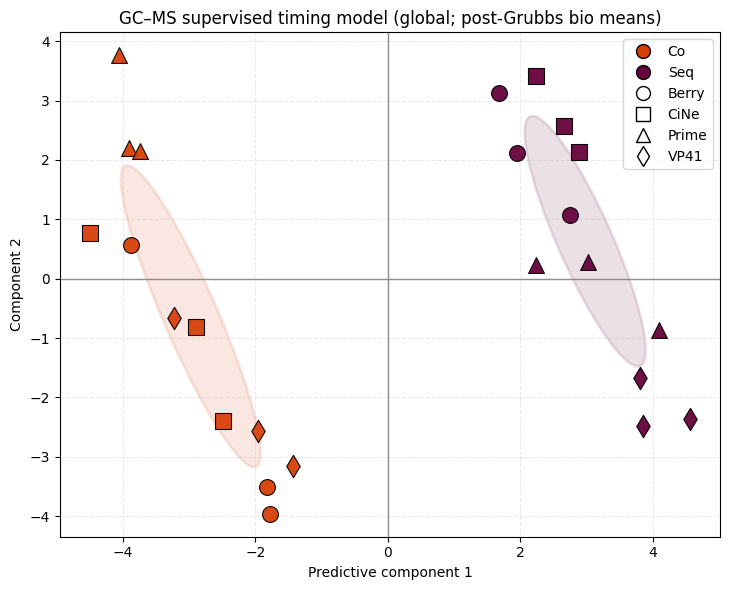

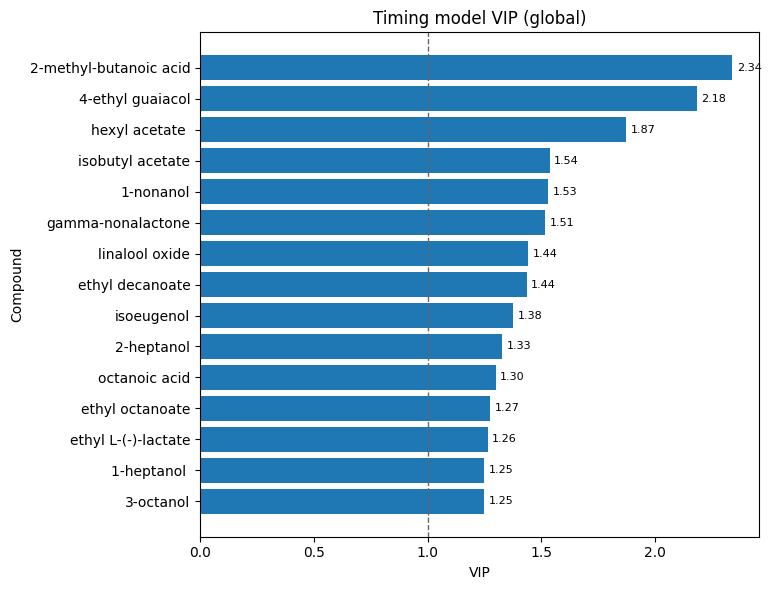

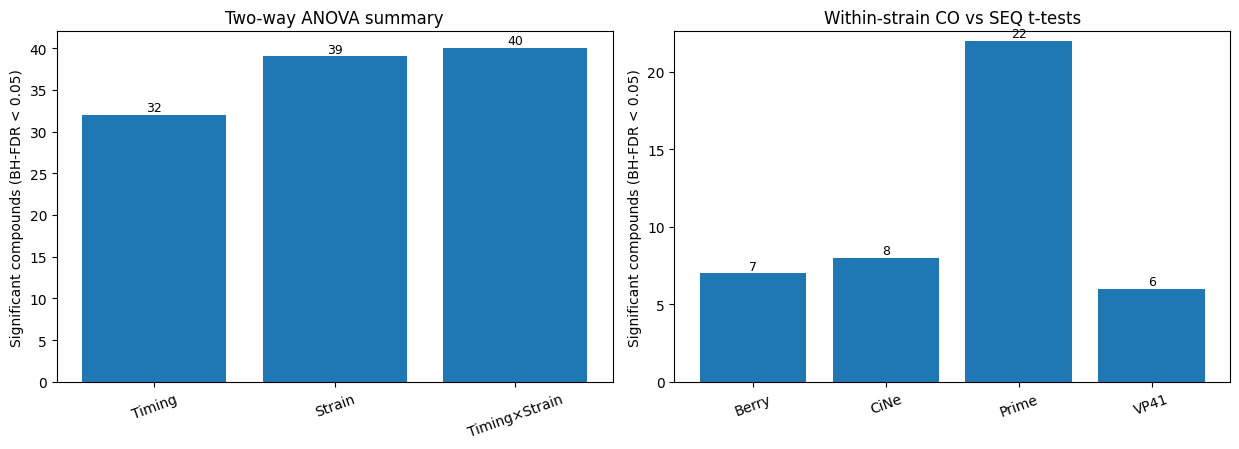

Saved:
 - C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\figures\gc2024_oplsda_timing_global.png
 - C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\figures\gc2024_oplsda_timing_global_vip.png
 - C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\tables\gc2024_twoway_anova_timing_strain.csv
 - C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\reports\gc2024_followon_stats_summary.txt

Global supervised model:


,Scope,Strain,Model_mode,n_components,n_splits,Q2,Permutation_p,CV_ANOVA_like_p,ROC_AUC,Train_accuracy
0,Global,ALL,PLS-DA fallback,2,3,0.897324,0.005,7.589531e-13,1.0,1.0



Top VIP rows (global):


,Scope,Strain,Compound,VIP
0,Global,ALL,2-methyl-butanoic acid,2.338888
1,Global,ALL,4-ethyl guaiacol,2.183793
2,Global,ALL,hexyl acetate,1.871303
3,Global,ALL,isobutyl acetate,1.536400
4,Global,ALL,1-nonanol,1.527999



Top ANOVA rows:


...

,Scope,Contrast,Strain,ok,F_value,p_value,n_groups,n,permutations,stars
0,WithinStrain,CO_vs_SEQ,BERRY,True,1.886501,0.180,2,6,999,ns
1,WithinStrain,CO_vs_SEQ,CINE,True,0.155631,0.298,2,6,999,ns
2,WithinStrain,CO_vs_SEQ,PRIME,True,1.122494,0.105,2,6,999,ns
3,WithinStrain,CO_vs_SEQ,VP41,True,0.260048,0.195,2,6,999,ns



Top VIP rows (within strain):


,Scope,Strain,Compound,VIP
0,WithinStrain,BERRY,ethyl L-(-)-lactate,1.473513
1,WithinStrain,BERRY,2-methyl-butanoic acid,1.470291
2,WithinStrain,BERRY,"2,3 butane diol",1.462545
3,WithinStrain,BERRY,4-ethyl guaiacol,1.460420
4,WithinStrain,BERRY,furfuryl alcohol,1.459698



Top within-strain t-test rows:


,Compound,Strain,n_CO,n_SEQ,Mean_log_CO,Mean_log_SEQ,Delta_log_SEQ_minus_CO,t_stat,p_value,FDR_BH_within_strain
0,1-butanol,BERRY,3,3,1.294450,1.937596,0.643146,-0.992969,0.425271,0.570044
1,1-butanol,CINE,3,3,2.432740,2.732418,0.299677,-2.719030,0.089589,0.201575
2,1-butanol,PRIME,3,3,0.000000,2.559405,2.559405,-51.044149,0.000384,0.002417
3,1-butanol,VP41,3,3,2.576350,1.495355,-1.080996,1.422125,0.283785,0.471715
4,1-heptanol,BERRY,3,3,1.284604,1.325478,0.040873,-2.669176,0.081750,0.215810


In [24]:
# ============================================================
# post-Grubbs data
# Within-strain timing suite / global supervised timing model /
# compound-wise two-way ANOVA / optional within-strain t-tests
# ============================================================

# Uses the post-Grubbs cleaned data generated by the GC–MS pipeline.
# Preference order:
#   1) out["clean_long"] / out["bio"] from the GC cell if present
#   2) CLEAN_LONG_CSV written by the GC cell
#
# Saved outputs:
#   - global supervised timing model plot
#   - global VIP plot
#   - two-way ANOVA CSV
#   - follow-on audit TXT
#
# Notes:
# - Global PERMANOVA / PERMDISP intentionally removed from this cell.
# - Within-strain PERMANOVA / PERMDISP are retained as exploratory drill-downs.
# - Within-strain t-tests are optional exploratory outputs.
# - BH-FDR is retained for compound-wise multiple testing.

FOLLOWON_DIR = str(OUTPUT_DIR)
# Publication lock: follow-on models consume post-Grubbs data with zeros preserved,
# then use the same log10(x + EPS) transform as the main GC–MS pipeline.

RUN_WITHIN_STRAIN_TTESTS = True
RUN_WITHIN_STRAIN_MODELS = True
RUN_WITHIN_STRAIN_PERMANOVA = True
RUN_WITHIN_STRAIN_PERMDISP = True

ANOVA_CSV = str(TABLE_DIR / "gc2024_twoway_anova_timing_strain.csv")
FOLLOWON_SUMMARY_TXT = str(REPORT_DIR / "gc2024_followon_stats_summary.txt")
OPLS_GLOBAL_PNG = str(FIGURE_DIR / "gc2024_oplsda_timing_global.png")
VIP_GLOBAL_PNG = str(FIGURE_DIR / "gc2024_oplsda_timing_global_vip.png")


def _load_postgrubbs_bio_for_followon():
    if "out" in globals() and isinstance(out, dict):
        bio_local = out.get("bio")
        clean_long_local = out.get("clean_long")
        if bio_local is not None:
            bio_local = bio_local.copy()

            compound_cols_local = out.get("compound_cols_final")
            if compound_cols_local is None:
                compound_cols_local = out.get("compound_cols")
            if compound_cols_local is None:
                compound_cols_local = infer_compound_columns(bio_local)

            return bio_local, clean_long_local, compound_cols_local

    if not os.path.exists(CLEAN_LONG_CSV):
        raise FileNotFoundError(
            f"Could not find post-Grubbs cleaned table: {CLEAN_LONG_CSV}\n"
            "Run the GC–MS pipeline cell first so the cleaned file exists."
        )

    clean_long_local = pd.read_csv(CLEAN_LONG_CSV)
    bio_local = collapse_cleaned_long_to_bio(clean_long_local)

    bio_local["Timing"] = bio_local["Timing"].astype(str).str.upper()
    bio_local["Strain"] = bio_local["Strain"].astype(str).apply(canon_strain)
    bio_local["Treatment"] = bio_local["Timing"].astype(str) + "_" + bio_local["Strain"].astype(str)

    compound_cols_local = infer_compound_columns(bio_local)
    return bio_local, clean_long_local, compound_cols_local


def _bray_dm_from_df(df, compound_cols, eps=EPS):
    X = np.log10(df[compound_cols].to_numpy(float) + eps)
    D = squareform(pdist(X, metric="braycurtis"))
    return DistanceMatrix(D, ids=df.index.astype(str).tolist())


def _align_dm_and_grouping(dm, grouping):
    """
    Make scikit-bio DistanceMatrix IDs and grouping labels explicitly compatible.
    Returns a filtered/reordered DistanceMatrix plus a grouping Series indexed by dm.ids.
    """
    if isinstance(grouping, pd.Series):
        g = grouping.copy()
    else:
        g = pd.Series(grouping)

    g.index = g.index.astype(str)
    dm_ids = [str(i) for i in dm.ids]
    overlap = [i for i in dm_ids if i in g.index]

    if len(overlap) == len(dm_ids):
        dm2 = dm.filter(overlap)
        g2 = g.loc[overlap].astype(str)
        return dm2, g2

    if len(g) == len(dm_ids):
        g2 = pd.Series(g.to_numpy(), index=dm_ids, dtype="object").astype(str)
        return dm, g2

    raise ValueError(
        f"Distance-matrix IDs and grouping labels do not align. "
        f"dm_n={len(dm_ids)}, grouping_n={len(g)}, overlap={len(overlap)}"
    )


def _safe_permanova(dm, grouping, permutations=PERMUTATIONS):
    try:
        dm2, grouping2 = _align_dm_and_grouping(dm, grouping)
    except Exception as e:
        return {"ok": False, "reason": str(e)}

    if grouping2.nunique() < 2:
        return {"ok": False, "reason": "Need at least 2 groups."}

    group_counts = grouping2.value_counts()
    if (group_counts < 2).any():
        return {"ok": False, "reason": f"Each group needs >=2 rows; counts={group_counts.to_dict()}"}

    try:
        meta = pd.DataFrame({"Group": grouping2}, index=grouping2.index)
        res = permanova(dm2, meta, column="Group", permutations=permutations)
        return {
            "ok": True,
            "pseudo_F": float(res["test statistic"]),
            "p_value": float(res["p-value"]),
            "n_groups": int(res["number of groups"]),
            "n": int(res["sample size"]),
            "permutations": int(res["number of permutations"]),
        }
    except Exception as e:
        return {"ok": False, "reason": str(e)}


def _safe_permdisp(dm, grouping, permutations=PERMUTATIONS):
    try:
        dm2, grouping2 = _align_dm_and_grouping(dm, grouping)
    except Exception as e:
        return {"ok": False, "reason": str(e)}

    if grouping2.nunique() < 2:
        return {"ok": False, "reason": "Need at least 2 groups."}

    group_counts = grouping2.value_counts()
    if (group_counts < 2).any():
        return {"ok": False, "reason": f"Each group needs >=2 rows; counts={group_counts.to_dict()}"}

    try:
        meta = pd.DataFrame({"Group": grouping2}, index=grouping2.index)
        res = permdisp(dm2, meta, column="Group", permutations=permutations)
        return {
            "ok": True,
            "F_value": float(res["test statistic"]),
            "p_value": float(res["p-value"]),
            "n_groups": int(res["number of groups"]),
            "n": int(res["sample size"]),
            "permutations": int(res["number of permutations"]),
        }
    except Exception as e:
        return {"ok": False, "reason": str(e)}


def _stars(p):
    if pd.isna(p):
        return "NA"
    if p <= 1e-4:
        return "****"
    if p <= 1e-3:
        return "***"
    if p <= 1e-2:
        return "**"
    if p <= 5e-2:
        return "*"
    return "ns"


def run_within_strain_permanova_timing_suite(bio_local, compound_cols, permutations=PERMUTATIONS):
    rows = []

    for strain in INOCULUM_ORDER:
        sub = bio_local[bio_local["Strain"] == strain].copy()
        if sub.empty:
            continue

        dm_sub = _bray_dm_from_df(sub, compound_cols, eps=EPS)
        res = _safe_permanova(dm_sub, sub["Timing"], permutations=permutations)

        row = {
            "Scope": "WithinStrain",
            "Contrast": "CO_vs_SEQ",
            "Strain": strain,
            **res
        }
        if row.get("ok", False):
            row["stars"] = _stars(row.get("p_value", np.nan))
        else:
            row["stars"] = "NA"
        rows.append(row)

    return pd.DataFrame(rows)


def run_within_strain_permdisp_timing_suite(bio_local, compound_cols, permutations=PERMUTATIONS):
    rows = []

    for strain in INOCULUM_ORDER:
        sub = bio_local[bio_local["Strain"] == strain].copy()
        if sub.empty:
            continue

        dm_sub = _bray_dm_from_df(sub, compound_cols, eps=EPS)
        res = _safe_permdisp(dm_sub, sub["Timing"], permutations=permutations)

        row = {
            "Scope": "WithinStrain",
            "Contrast": "CO_vs_SEQ",
            "Strain": strain,
            **res
        }
        if row.get("ok", False):
            row["stars"] = _stars(row.get("p_value", np.nan))
        else:
            row["stars"] = "NA"
        rows.append(row)

    return pd.DataFrame(rows)


def _prepare_supervised_xy(df, compound_cols):
    X = np.log10(df[compound_cols].to_numpy(float) + EPS)
    y = (df["Timing"].astype(str).str.upper() == "SEQ").astype(int).to_numpy()
    return X, y


def _q2_from_cv(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    press = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - y_true.mean()) ** 2)
    if tss <= 0:
        return np.nan
    return float(1 - press / tss)


def _cv_splits_for_binary(y):
    counts = pd.Series(y).value_counts()
    min_class = int(counts.min())
    return max(2, min(3, min_class))


def _fit_plsda_with_validation(df, compound_cols, n_components=2, n_perm=199, random_state=42):
    X, y = _prepare_supervised_xy(df, compound_cols)
    n_splits = _cv_splits_for_binary(y)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    pls_n = max(1, min(n_components, X.shape[0] - 1, X.shape[1]))
    model = PLSRegression(n_components=pls_n, scale=True)

    y_cv = cross_val_predict(model, X, y, cv=cv).ravel()
    q2 = _q2_from_cv(y, y_cv)

    rng = np.random.default_rng(random_state)
    perm_q2 = []
    for _ in range(int(n_perm)):
        y_perm = rng.permutation(y)
        try:
            y_perm_cv = cross_val_predict(model, X, y_perm, cv=cv).ravel()
            perm_q2.append(_q2_from_cv(y_perm, y_perm_cv))
        except Exception:
            perm_q2.append(np.nan)

    perm_q2 = np.asarray(perm_q2, dtype=float)
    perm_q2 = perm_q2[np.isfinite(perm_q2)]
    perm_p = float((np.sum(perm_q2 >= q2) + 1) / (len(perm_q2) + 1)) if len(perm_q2) else np.nan

    model.fit(X, y)
    x_scores = getattr(model, "x_scores_", None)
    if x_scores is None:
        x_scores = np.zeros((len(y), 2), dtype=float)
    if x_scores.shape[1] == 1:
        scores2d = np.column_stack([x_scores[:, 0], np.zeros(x_scores.shape[0])])
    else:
        scores2d = x_scores[:, :2]

    y_hat = model.predict(X).ravel()
    auc = float(roc_auc_score(y, y_hat)) if len(np.unique(y)) == 2 else np.nan
    acc = float(accuracy_score(y, (y_hat >= 0.5).astype(int)))

    try:
        cv_df = pd.DataFrame({"y": y.astype(float), "y_cv": y_cv.astype(float)})
        fit = smf.ols("y ~ y_cv", data=cv_df).fit()
        cv_anova_like_p = float(fit.f_pvalue)
    except Exception:
        cv_anova_like_p = np.nan

    try:
        T = model.x_scores_
        W = model.x_weights_
        Q = model.y_loadings_
        p, h = W.shape
        s = np.diag(T.T @ T @ Q.T @ Q).reshape(h, -1)
        total_s = s.sum()
        vip = np.sqrt(p * (W**2 @ s) / total_s).ravel()
    except Exception:
        vip = np.full(X.shape[1], np.nan)

    return {
        "mode": "PLS-DA fallback",
        "n_components": int(pls_n),
        "n_splits": int(n_splits),
        "q2": float(q2) if np.isfinite(q2) else np.nan,
        "perm_p": perm_p,
        "cv_anova_like_p": cv_anova_like_p,
        "auc": auc,
        "accuracy_train": acc,
        "scores2d": scores2d,
        "y": y,
        "y_hat": y_hat,
        "perm_q2": perm_q2,
        "vip": vip,
        "feature_names": list(compound_cols),
    }


def _vip_table_from_result(result, scope="Global", strain="ALL"):
    feat = list(result.get("feature_names", []))
    vip = np.asarray(result.get("vip", []), dtype=float)
    if vip.ndim == 0:
        vip = np.asarray([vip], dtype=float)

    if len(feat) != len(vip):
        n = min(len(feat), len(vip))
        feat = feat[:n]
        vip = vip[:n]

    df = pd.DataFrame({
        "Scope": scope,
        "Strain": strain,
        "Compound": feat,
        "VIP": vip,
    })

    if not df.empty:
        df = df.sort_values(["VIP", "Compound"], ascending=[False, True]).reset_index(drop=True)
    return df


def _plot_vip_table(vip_df, out_png, title, top_k=15):
    vip_df = vip_df.copy()
    vip_df = vip_df[np.isfinite(pd.to_numeric(vip_df["VIP"], errors="coerce"))]
    if vip_df.empty:
        return

    top = vip_df.sort_values("VIP", ascending=False).head(top_k).iloc[::-1]

    fig, ax = plt.subplots(figsize=(7.8, 6.0))
    bars = ax.barh(top["Compound"], top["VIP"])
    ax.axvline(1.0, color="0.4", linestyle="--", lw=1.0)
    ax.set_xlabel("VIP")
    ax.set_ylabel("Compound")
    ax.set_title(title)

    for b, v in zip(bars, top["VIP"]):
        ax.text(float(v) + 0.02, b.get_y() + b.get_height() / 2, f"{float(v):.2f}", va="center", fontsize=8)

    fig.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def draw_cov_ellipse(ax, pts, edgecolor="black", facecolor="black", alpha=0.12, lw=2.0, n_std=1.0):
    pts = np.asarray(pts, dtype=float)
    if pts.ndim != 2 or pts.shape[1] != 2 or pts.shape[0] < 3:
        return None

    x = pts[:, 0]
    y = pts[:, 1]
    add_group_ellipse(
        ax,
        x=x,
        y=y,
        edgecolor=edgecolor,
        n_std=n_std,
        linewidth=lw,
        alpha=alpha,
        zorder=1
    )
    return None


def _plot_supervised_scores(result, df, title, out_png):
    scores2d = np.asarray(result["scores2d"], dtype=float)
    fig, ax = plt.subplots(figsize=(7.4, 6.0))

    plot_df = df.copy().reset_index(drop=True)
    plot_df["Comp1"] = scores2d[:, 0]
    plot_df["Comp2"] = scores2d[:, 1] if scores2d.shape[1] > 1 else 0.0

    for strain in INOCULUM_ORDER:
        for timing in TIMING_ORDER:
            sub = plot_df[(plot_df["Strain"] == strain) & (plot_df["Timing"] == timing)]
            if sub.empty:
                continue
            ax.scatter(
                sub["Comp1"], sub["Comp2"],
                s=130,
                c=TIMING_COLORS.get(timing, "gray"),
                marker=LAB_MARKERS.get(strain, "o"),
                edgecolor="black",
                linewidth=PCA_EDGE_LW,
                alpha=0.95,
                zorder=3,
            )

    for timing in TIMING_ORDER:
        sub = plot_df[plot_df["Timing"] == timing]
        if len(sub) < 3:
            continue
        pts = sub[["Comp1", "Comp2"]].to_numpy(float)
        try:
            draw_cov_ellipse(
                ax, pts,
                edgecolor=TIMING_COLORS.get(timing, "gray"),
                facecolor=TIMING_COLORS.get(timing, "gray"),
                alpha=0.12,
                lw=2.0,
                n_std=1.0
            )
        except Exception:
            pass

    ax.axhline(0, color="0.55", lw=1.0)
    ax.axvline(0, color="0.55", lw=1.0)
    ax.grid(alpha=0.25, linestyle="--")
    ax.set_xlabel("Predictive component 1")
    ax.set_ylabel("Component 2")
    ax.set_title(title)

    timing_handles = [
        Line2D([0], [0], marker="o", color="none", label="Co",
               markerfacecolor=CO_COLOR, markeredgecolor="black", markersize=10),
        Line2D([0], [0], marker="o", color="none", label="Seq",
               markerfacecolor=SEQ_COLOR, markeredgecolor="black", markersize=10),
    ]
    strain_handles = [
        Line2D([0], [0], marker=LAB_MARKERS[k], color="none",
               label=STRAIN_LABELS.get(k, k), markerfacecolor="white",
               markeredgecolor="black", markersize=10)
        for k in INOCULUM_ORDER
    ]
    ax.legend(handles=timing_handles + strain_handles, loc="best", frameon=True)
    fig.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def run_supervised_timing_models(bio_local, compound_cols, n_perm=199):
    global_res = _fit_plsda_with_validation(bio_local, compound_cols, n_components=2, n_perm=n_perm)
    global_row = pd.DataFrame([{
        "Scope": "Global",
        "Strain": "ALL",
        "Model_mode": global_res["mode"],
        "n_components": global_res["n_components"],
        "n_splits": global_res["n_splits"],
        "Q2": global_res["q2"],
        "Permutation_p": global_res["perm_p"],
        "CV_ANOVA_like_p": global_res["cv_anova_like_p"],
        "ROC_AUC": global_res["auc"],
        "Train_accuracy": global_res["accuracy_train"],
    }])

    by_rows = []
    by_res = {}
    if RUN_WITHIN_STRAIN_MODELS:
        for strain in INOCULUM_ORDER:
            sub = bio_local[bio_local["Strain"] == strain].copy()
            if sub["Timing"].nunique() < 2 or len(sub) < 4:
                continue
            res = _fit_plsda_with_validation(sub, compound_cols, n_components=2, n_perm=n_perm)
            by_res[strain] = (sub, res)
            by_rows.append({
                "Scope": "WithinStrain",
                "Strain": strain,
                "Model_mode": res["mode"],
                "n_components": res["n_components"],
                "n_splits": res["n_splits"],
                "Q2": res["q2"],
                "Permutation_p": res["perm_p"],
                "CV_ANOVA_like_p": res["cv_anova_like_p"],
                "ROC_AUC": res["auc"],
                "Train_accuracy": res["accuracy_train"],
            })

    return global_res, global_row, by_res, pd.DataFrame(by_rows)


def run_compoundwise_anova_and_ttests(bio_local, compound_cols, run_ttests=True):
    rows_anova = []
    rows_t = []

    for compound in compound_cols:
        tmp = bio_local[["Timing", "Strain", compound]].copy()
        tmp["log_value"] = np.log10(pd.to_numeric(tmp[compound], errors="coerce") + EPS)
        tmp = tmp.dropna(subset=["log_value"])
        if tmp.empty:
            continue

        try:
            fit = ols("log_value ~ C(Timing) * C(Strain)", data=tmp).fit()
            aov = anova_lm(fit, typ=2)

            def _grab(term, stat_col):
                try:
                    return float(aov.loc[term, stat_col])
                except Exception:
                    return np.nan

            rows_anova.append({
                "Compound": compound,
                "Timing_F": _grab("C(Timing)", "F"),
                "Timing_p": _grab("C(Timing)", "PR(>F)"),
                "Strain_F": _grab("C(Strain)", "F"),
                "Strain_p": _grab("C(Strain)", "PR(>F)"),
                "Interaction_F": _grab("C(Timing):C(Strain)", "F"),
                "Interaction_p": _grab("C(Timing):C(Strain)", "PR(>F)"),
            })
        except Exception:
            rows_anova.append({
                "Compound": compound,
                "Timing_F": np.nan, "Timing_p": np.nan,
                "Strain_F": np.nan, "Strain_p": np.nan,
                "Interaction_F": np.nan, "Interaction_p": np.nan,
            })

        if run_ttests:
            for strain in INOCULUM_ORDER:
                sub = tmp[tmp["Strain"] == strain].copy()
                co = sub.loc[sub["Timing"] == "CO", "log_value"].dropna().to_numpy(float)
                seq = sub.loc[sub["Timing"] == "SEQ", "log_value"].dropna().to_numpy(float)
                if len(co) < 2 or len(seq) < 2:
                    continue

                stat, p = stats.ttest_ind(co, seq, equal_var=False, nan_policy="omit")
                rows_t.append({
                    "Compound": compound,
                    "Strain": strain,
                    "n_CO": int(len(co)),
                    "n_SEQ": int(len(seq)),
                    "Mean_log_CO": float(np.mean(co)),
                    "Mean_log_SEQ": float(np.mean(seq)),
                    "Delta_log_SEQ_minus_CO": float(np.mean(seq) - np.mean(co)),
                    "t_stat": float(stat),
                    "p_value": float(p),
                })

    anova_df = pd.DataFrame(rows_anova)
    if not anova_df.empty:
        for raw_col, adj_col in [
            ("Timing_p", "Timing_FDR_BH"),
            ("Strain_p", "Strain_FDR_BH"),
            ("Interaction_p", "Interaction_FDR_BH"),
        ]:
            pvals = pd.to_numeric(anova_df[raw_col], errors="coerce")
            mask = pvals.notna()
            adj = np.full(len(anova_df), np.nan, dtype=float)
            if mask.sum() > 0:
                adj[mask] = multipletests(pvals[mask], method="fdr_bh")[1]
            anova_df[adj_col] = adj

    t_df = pd.DataFrame(rows_t)
    if not t_df.empty:
        t_df["FDR_BH_within_strain"] = np.nan

        for strain in sorted(t_df["Strain"].dropna().unique()):
            mask = t_df["Strain"] == strain
            pvals = pd.to_numeric(t_df.loc[mask, "p_value"], errors="coerce")
            valid = pvals.notna()

            adj = np.full(mask.sum(), np.nan, dtype=float)
            if valid.sum() > 0:
                adj_valid = multipletests(pvals[valid], method="fdr_bh")[1]
                adj[np.where(valid)[0]] = adj_valid

            t_df.loc[mask, "FDR_BH_within_strain"] = adj

        t_df["FDR_BH_within_strain"] = pd.to_numeric(t_df["FDR_BH_within_strain"], errors="coerce")

    return anova_df, t_df


def plot_followon_anova_summary(anova_df, t_df):
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

    effect_counts = pd.Series({
        "Timing": int((anova_df["Timing_FDR_BH"] < ALPHA).sum()) if "Timing_FDR_BH" in anova_df else 0,
        "Strain": int((anova_df["Strain_FDR_BH"] < ALPHA).sum()) if "Strain_FDR_BH" in anova_df else 0,
        "Timing×Strain": int((anova_df["Interaction_FDR_BH"] < ALPHA).sum()) if "Interaction_FDR_BH" in anova_df else 0,
    })

    bars0 = axes[0].bar(effect_counts.index, effect_counts.values)
    axes[0].set_ylabel("Significant compounds (BH-FDR < 0.05)")
    axes[0].set_title("Two-way ANOVA summary")
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].set_ylim(0, max(1, effect_counts.max()) + 2)

    for b, v in zip(bars0, effect_counts.values):
        axes[0].text(
            b.get_x() + b.get_width() / 2,
            float(v) + 0.1,
            str(int(v)),
            ha="center",
            va="bottom",
            fontsize=9
        )

    if not t_df.empty:
        counts = (
            t_df.assign(sig=t_df["FDR_BH_within_strain"] < ALPHA)
            .groupby("Strain")["sig"].sum()
            .reindex(INOCULUM_ORDER)
            .fillna(0)
            .astype(int)
        )
    else:
        counts = pd.Series(0, index=INOCULUM_ORDER, dtype=int)

    labels = [STRAIN_LABELS.get(s, s) for s in counts.index]
    bars1 = axes[1].bar(labels, counts.values)
    axes[1].set_ylabel("Significant compounds (BH-FDR < 0.05)")
    axes[1].set_title("Within-strain CO vs SEQ t-tests")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].set_ylim(0, max(1, counts.max()) + 0.6)

    for b, v in zip(bars1, counts.values):
        axes[1].text(
            b.get_x() + b.get_width() / 2,
            float(v) + 0.05,
            str(int(v)),
            ha="center",
            va="bottom",
            fontsize=9
        )

    fig.tight_layout()
    plt.show()
    plt.close(fig)


def _top_compounds_by_column(df, sort_col, n=10):
    if df.empty or sort_col not in df.columns:
        return pd.DataFrame()
    tmp = df.copy()
    tmp[sort_col] = pd.to_numeric(tmp[sort_col], errors="coerce")
    tmp = tmp[np.isfinite(tmp[sort_col])]
    if tmp.empty:
        return pd.DataFrame()
    return tmp.sort_values(sort_col, ascending=True).head(n)


def write_followon_audit(
    path,
    global_sup_df,
    vip_global_df,
    anova_df,
    within_perm_df,
    within_disp_df,
    vip_bystrain_df,
    ttest_df,
    top_vip_global_n=15,
    top_vip_strain_n=10,
    top_anova_n=10
):
    with open(path, "w", encoding="utf-8") as fh:
        fh.write("GC–MS FOLLOW-ON STATS AUDIT (2024)\n")
        fh.write("=" * 58 + "\n\n")

        fh.write("[GLOBAL]\n")
        fh.write("-" * 58 + "\n")

        fh.write("Supervised timing model (global)\n")
        fh.write(global_sup_df.to_string(index=False))
        fh.write("\n\n")

        fh.write(f"Top global VIP compounds (top {top_vip_global_n})\n")
        if not vip_global_df.empty:
            fh.write(vip_global_df.head(top_vip_global_n).to_string(index=False))
        else:
            fh.write("No VIP values.\n")
        fh.write("\n\n")

        fh.write("Two-way ANOVA summary (BH-FDR < 0.05)\n")
        if not anova_df.empty:
            fh.write(
                f"Timing: {(anova_df['Timing_FDR_BH'] < ALPHA).sum()}\n"
                f"Strain: {(anova_df['Strain_FDR_BH'] < ALPHA).sum()}\n"
                f"Timing×Strain: {(anova_df['Interaction_FDR_BH'] < ALPHA).sum()}\n"
            )
        else:
            fh.write("No ANOVA results.\n")
        fh.write("\n")

        if not anova_df.empty:
            fh.write(f"Top Timing compounds by BH-FDR (top {top_anova_n})\n")
            top_timing = _top_compounds_by_column(anova_df, "Timing_FDR_BH", n=top_anova_n)
            fh.write(top_timing.to_string(index=False) if not top_timing.empty else "No rows.\n")
            fh.write("\n\n")

            fh.write(f"Top Strain compounds by BH-FDR (top {top_anova_n})\n")
            top_strain = _top_compounds_by_column(anova_df, "Strain_FDR_BH", n=top_anova_n)
            fh.write(top_strain.to_string(index=False) if not top_strain.empty else "No rows.\n")
            fh.write("\n\n")

            fh.write(f"Top Timing×Strain compounds by BH-FDR (top {top_anova_n})\n")
            top_inter = _top_compounds_by_column(anova_df, "Interaction_FDR_BH", n=top_anova_n)
            fh.write(top_inter.to_string(index=False) if not top_inter.empty else "No rows.\n")
            fh.write("\n\n")

        fh.write("[DRILL-DOWN]\n")
        fh.write("-" * 58 + "\n")

        fh.write("Within-strain PERMANOVA (Timing: CO vs SEQ)\n")
        if within_perm_df is not None and not within_perm_df.empty:
            fh.write(within_perm_df.to_string(index=False))
        else:
            fh.write("No within-strain PERMANOVA results.\n")
        fh.write("\n\n")

        fh.write("Within-strain PERMDISP (Timing: CO vs SEQ)\n")
        if within_disp_df is not None and not within_disp_df.empty:
            fh.write(within_disp_df.to_string(index=False))
        else:
            fh.write("No within-strain PERMDISP results.\n")
        fh.write("\n\n")

        fh.write(f"Strain VIP compounds (top {top_vip_strain_n} each)\n")
        if vip_bystrain_df is not None and not vip_bystrain_df.empty:
            for strain in [s for s in INOCULUM_ORDER if s in vip_bystrain_df["Strain"].astype(str).unique().tolist()]:
                fh.write(f"\n<{strain}>\n")
                fh.write(
                    vip_bystrain_df[vip_bystrain_df["Strain"] == strain]
                    .head(top_vip_strain_n)
                    .to_string(index=False)
                )
                fh.write("\n")
        else:
            fh.write("No within-strain VIP results.\n")
        fh.write("\n")

        fh.write("Within-strain t-tests (BH-FDR)\n")
        if ttest_df is not None and not ttest_df.empty:
            sig_counts = (
                ttest_df.assign(sig=ttest_df["FDR_BH_within_strain"] < ALPHA)
                .groupby("Strain")["sig"].sum()
                .reindex(INOCULUM_ORDER)
                .fillna(0)
                .astype(int)
            )
            fh.write("Significant compounds by strain (FDR < 0.05)\n")
            fh.write(sig_counts.to_string())
            fh.write("\n\n")

            for strain in INOCULUM_ORDER:
                sub = ttest_df[ttest_df["Strain"] == strain].copy()
                if sub.empty:
                    continue
                sub = sub.sort_values("FDR_BH_within_strain", ascending=True)
                fh.write(f"<{strain}> top t-test rows\n")
                fh.write(sub.head(10).to_string(index=False))
                fh.write("\n\n")
        else:
            fh.write("Within-strain t-tests not run or no valid rows.\n")


# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------
bio_followon, clean_long_followon, compound_cols_followon = _load_postgrubbs_bio_for_followon()

# Within-strain timing suite only
within_perm_df = pd.DataFrame()
if RUN_WITHIN_STRAIN_PERMANOVA:
    within_perm_df = run_within_strain_permanova_timing_suite(
        bio_followon, compound_cols_followon, permutations=PERMUTATIONS
    )

within_disp_df = pd.DataFrame()
if RUN_WITHIN_STRAIN_PERMDISP:
    within_disp_df = run_within_strain_permdisp_timing_suite(
        bio_followon, compound_cols_followon, permutations=PERMUTATIONS
    )

# Global supervised timing model + optional within-strain supervised models
global_sup_res, global_sup_df, bystrain_sup_res, bystrain_sup_df = run_supervised_timing_models(
    bio_followon, compound_cols_followon, n_perm=199
)

vip_global_df = _vip_table_from_result(global_sup_res, scope="Global", strain="ALL")

vip_bystrain_df = (
    pd.concat(
        [_vip_table_from_result(res, scope="WithinStrain", strain=strain)
         for strain, (_, res) in bystrain_sup_res.items()],
        ignore_index=True
    )
    if len(bystrain_sup_res)
    else pd.DataFrame(columns=["Scope", "Strain", "Compound", "VIP"])
)

# Save only the global plots
_plot_supervised_scores(
    global_sup_res,
    bio_followon,
    title="GC–MS supervised timing model (global; post-Grubbs bio means)",
    out_png=OPLS_GLOBAL_PNG
)

_plot_vip_table(
    vip_global_df,
    VIP_GLOBAL_PNG,
    "Timing model VIP (global)",
    top_k=15
)

# ANOVA + optional t-tests
anova_followon_df, ttest_followon_df = run_compoundwise_anova_and_ttests(
    bio_followon,
    compound_cols_followon,
    run_ttests=RUN_WITHIN_STRAIN_TTESTS
)

# Keep ANOVA CSV only
anova_followon_df.to_csv(ANOVA_CSV, index=False)

# In-notebook only ANOVA summary plot
plot_followon_anova_summary(anova_followon_df, ttest_followon_df)

# Single audit file
write_followon_audit(
    path=FOLLOWON_SUMMARY_TXT,
    global_sup_df=global_sup_df,
    vip_global_df=vip_global_df,
    anova_df=anova_followon_df,
    within_perm_df=within_perm_df,
    within_disp_df=within_disp_df,
    vip_bystrain_df=vip_bystrain_df,
    ttest_df=ttest_followon_df
)

print("Saved:")
print(" -", OPLS_GLOBAL_PNG)
print(" -", VIP_GLOBAL_PNG)
print(" -", ANOVA_CSV)
print(" -", FOLLOWON_SUMMARY_TXT)

print("\nGlobal supervised model:")
display(global_sup_df)

print("\nTop VIP rows (global):")
display(vip_global_df.head())

print("\nTop ANOVA rows:")
display(anova_followon_df.head())

print("\nWithin-strain PERMANOVA timing suite:")
display(within_perm_df)

print("\nWithin-strain PERMDISP timing suite:")
display(within_disp_df)

print("\nTop VIP rows (within strain):")
display(vip_bystrain_df.head())

print("\nTop within-strain t-test rows:")
display(ttest_followon_df.head())


# MFA Plotting and Report 

[MFA] PANEL_MODE=consumers → attempting bio-rep MFA
[MFA] No Bio_rep column in sensory metadata → falling back to treatment-level MFA
[MFA] Aligned Treatments: ['CO_BERRY', 'CO_CINE', 'CO_PRIME', 'CO_VP41', 'SEQ_BERRY', 'SEQ_CINE', 'SEQ_PRIME', 'SEQ_VP41']
[MFA] GC matrix: (8, 66)
[MFA] Sensory matrix: (8, 14)
[MFA] Plotting GC VIP arrows: ['2-methyl-butanoic acid', '4-ethyl guaiacol', 'hexyl acetate ', 'isobutyl acetate', '1-nonanol', 'gamma-nonalactone', 'linalool oxide', 'ethyl decanoate', 'isoeugenol', '2-heptanol', 'octanoic acid', 'ethyl octanoate']


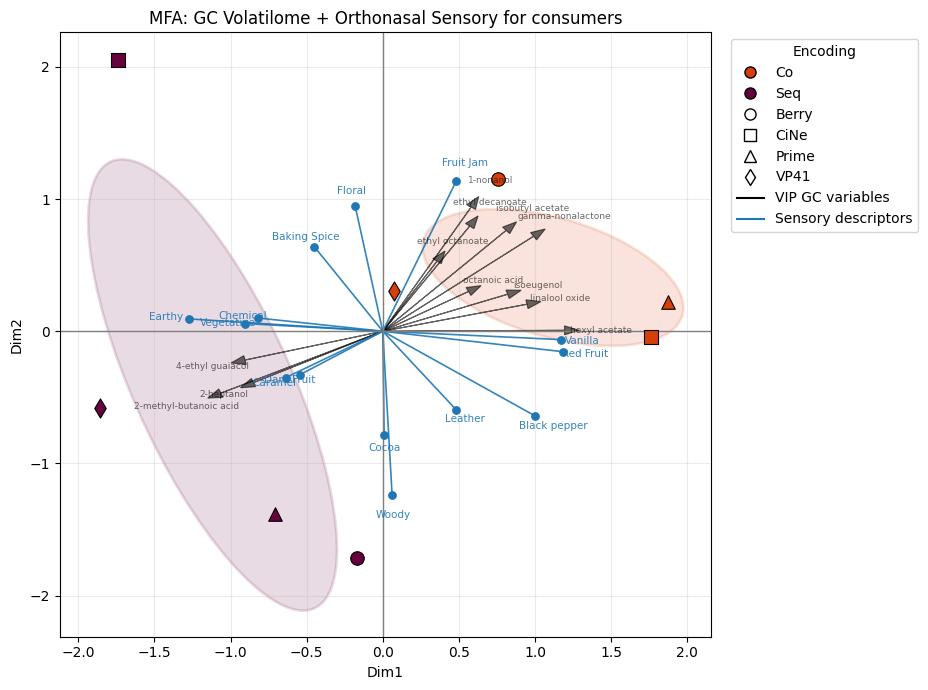

Saved MFA figure:   C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\figures\gc_sensory_mfa_consumers.png
Saved MFA scores:   C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\tables\gc_sensory_mfa_coords_consumers.csv
Saved MFA loadings: C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\tables\gc_sensory_mfa_loadings_consumers.csv
Saved MFA report:   C:\Users\cinde\OneDrive - Oregon State University\Lab_Docs\JupyterProject\Notebooks\publication\outputs\reports\gc_sensory_mfa_report_consumers.txt


In [26]:
# =========================
# MFA: GC volatilome + sensory orthonasal aroma (_a only)
# Function-structured cell
# Handles PANEL_MODE:
#   - winemaker = treatment-level MFA
#   - consumer = bio-rep MFA if Bio_rep exists, otherwise treatment-level fallback
# =========================

# --------------------------------------------------
# Outputs / controls
# --------------------------------------------------
MFA_FIG = FIGURE_DIR / f"gc_sensory_mfa_{PANEL_MODE}.png"
MFA_COORDS = TABLE_DIR / f"gc_sensory_mfa_coords_{PANEL_MODE}.csv"
MFA_LOADINGS = TABLE_DIR / f"gc_sensory_mfa_loadings_{PANEL_MODE}.csv"
MFA_REPORT = REPORT_DIR / f"gc_sensory_mfa_report_{PANEL_MODE}.txt"

MFA_TOP_GC_ARROWS = 12
MFA_PLOT_ALL_SENSORY_ARROWS = True


# --------------------------------------------------
# Helpers
# --------------------------------------------------
def normalize_treatment_for_mfa(x):
    s = str(x).upper().replace("_", "").replace("-", "").replace(" ", "")

    if s.startswith("CO"):
        timing = "CO"
        rest = s[2:]
    elif s.startswith("SEQ"):
        timing = "SEQ"
        rest = s[3:]
    else:
        return s

    strain_map = {
        "BERRY": "BERRY",
        "CINE": "CINE",
        "PRIME": "PRIME",
        "VP41": "VP41",
    }

    strain = strain_map.get(rest, rest)
    return f"{timing}_{strain}"


def load_orthonasal_sensory_block(panel_mode):
    sensory_raw = load_rata_excel(str(RATA_FILE_BY_MODE[panel_mode]))
    sensory_df = add_metadata(sensory_raw)

    cols_aroma, cols_taste_tri, cols_all, families = infer_descriptor_groups(sensory_df)
    orthonasal_cols = families.get("Orthonasal", [])

    if len(orthonasal_cols) == 0:
        raise ValueError("No orthonasal *_a descriptor columns found in sensory dataframe.")

    X_sens_raw = prepare_numeric_matrix(sensory_df, orthonasal_cols)

    sens_md = prepare_metadata_df(sensory_df)
    X_sens_raw, sens_md = align_numeric_and_metadata(X_sens_raw, sens_md)

    sens_md = sens_md.copy()
    sens_md["Treatment_norm"] = sens_md["Treatment"].apply(normalize_treatment_for_mfa)

    return X_sens_raw, sens_md, orthonasal_cols


def load_gc_followon_block():
    if "bio_followon" not in globals() or "compound_cols_followon" not in globals():
        raise NameError(
            "Expected bio_followon and compound_cols_followon from the GC follow-on stats cell. "
            "Run the GC pipeline and GC follow-on stats cell first."
        )

    gc_bio = bio_followon.copy()
    gc_cols = list(compound_cols_followon)

    if "Bio_rep" not in gc_bio.columns:
        raise KeyError("Expected Bio_rep column in bio_followon.")

    gc_bio["Treatment_norm"] = gc_bio["Treatment"].apply(normalize_treatment_for_mfa)

    return gc_bio, gc_cols


def build_mfa_blocks(panel_mode):
    X_sens_raw, sens_md, orthonasal_cols = load_orthonasal_sensory_block(panel_mode)
    gc_bio, gc_cols = load_gc_followon_block()

    mode = str(panel_mode).lower()

    if mode == "winemaker":
        print("[MFA] PANEL_MODE=winemaker → treatment-level MFA")

        X_sens = (
            X_sens_raw
            .groupby(sens_md["Treatment_norm"])
            .mean()
        )

        X_gc_raw = (
            gc_bio
            .groupby("Treatment_norm", observed=True)[gc_cols]
            .mean(numeric_only=True)
        )

        key_name = "Treatment"

    else:
        print(f"[MFA] PANEL_MODE={panel_mode} → attempting bio-rep MFA")

        if "Bio_rep" not in sens_md.columns:
            print("[MFA] No Bio_rep column in sensory metadata → falling back to treatment-level MFA")

            X_sens = (
                X_sens_raw
                .groupby(sens_md["Treatment_norm"])
                .mean()
            )

            X_gc_raw = (
                gc_bio
                .groupby("Treatment_norm", observed=True)[gc_cols]
                .mean(numeric_only=True)
            )

            key_name = "Treatment"

        else:
            sens_md["SampleKey"] = (
                sens_md["Treatment_norm"] + "_R" + sens_md["Bio_rep"].astype(str)
            )

            gc_bio["SampleKey"] = (
                gc_bio["Treatment_norm"] + "_R" + gc_bio["Bio_rep"].astype(str)
            )

            X_sens = (
                X_sens_raw
                .groupby(sens_md["SampleKey"])
                .mean()
            )

            X_gc_raw = (
                gc_bio
                .groupby("SampleKey", observed=True)[gc_cols]
                .mean(numeric_only=True)
            )

            key_name = "SampleKey"

    X_gc = np.log10(X_gc_raw.astype(float) + EPS)

    X_sens.columns = [
        c[:-2].strip() if isinstance(c, str) and c.endswith("_a") else c
        for c in X_sens.columns
    ]

    X_sens = X_sens.loc[:, X_sens.std(axis=0) > 0]
    X_gc = X_gc.loc[:, X_gc.std(axis=0) > 0]

    common = X_gc.index.intersection(X_sens.index)

    if len(common) == 0:
        print("GC keys:", list(X_gc.index))
        print("Sensory keys:", list(X_sens.index))
        raise ValueError("No overlapping keys between GC and sensory matrices.")

    X_gc = X_gc.loc[common].copy()
    X_sens = X_sens.loc[common].copy()

    print(f"[MFA] Aligned {key_name}s: {list(common)}")
    print(f"[MFA] GC matrix: {X_gc.shape}")
    print(f"[MFA] Sensory matrix: {X_sens.shape}")

    return X_gc, X_sens, key_name, orthonasal_cols


def run_mfa_model(X_gc, X_sens):
    X_gc_scaled = (X_gc - X_gc.mean()) / X_gc.std(ddof=0)
    X_sens_scaled = (X_sens - X_sens.mean()) / X_sens.std(ddof=0)

    X_gc_scaled = X_gc_scaled.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X_sens_scaled = X_sens_scaled.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    gc_var_names = list(X_gc_scaled.columns)
    sens_var_names = list(X_sens_scaled.columns)

    X_gc_scaled.columns = pd.MultiIndex.from_product(
        [["GC"], gc_var_names],
        names=["Block", "Variable"]
    )

    X_sens_scaled.columns = pd.MultiIndex.from_product(
        [["Sensory_Aroma_A"], sens_var_names],
        names=["Block", "Variable"]
    )

    X_combined = pd.concat([X_gc_scaled, X_sens_scaled], axis=1)

    mfa = prince.MFA(
        n_components=2,
        random_state=GLOBAL_RANDOM_SEED
    )

    mfa = mfa.fit(
        X_combined,
        groups=["GC", "Sensory_Aroma_A"]
    )

    coords = mfa.row_coordinates(X_combined)

    # Older prince versions expose this as a property, not a method.
    loadings = mfa.column_correlations.copy()

    loadings.index = [
        col[1] if isinstance(col, tuple) else col
        for col in loadings.index
    ]

    loadings["mag"] = np.sqrt(loadings[0] ** 2 + loadings[1] ** 2)

    return mfa, coords, loadings, X_combined, gc_var_names, sens_var_names


def build_mfa_coords_df(coords, X_combined, key_name):
    coords_df = coords.copy()
    coords_df.index = X_combined.index
    coords_df = coords_df.rename(columns={0: "Dim1", 1: "Dim2"}).reset_index()

    first_col = coords_df.columns[0]
    coords_df = coords_df.rename(columns={first_col: "Key"})

    if key_name == "SampleKey":
        coords_df["SampleKey"] = coords_df["Key"]
        coords_df["Treatment"] = coords_df["SampleKey"].str.replace(r"_R\d+$", "", regex=True)
        coords_df["Bio_rep"] = coords_df["SampleKey"].str.extract(r"_R(\d+)$")[0]
    else:
        coords_df["Treatment"] = coords_df["Key"]
        coords_df["SampleKey"] = coords_df["Treatment"]
        coords_df["Bio_rep"] = np.nan

    coords_df["Timing"] = coords_df["Treatment"].str.split("_").str[0]
    coords_df["Strain"] = coords_df["Treatment"].str.split("_").str[1]

    return coords_df


def select_mfa_plot_variables(loadings, gc_var_names, sens_var_names, top_gc_arrows=12, plot_all_sensory=True):
    if "vip_global_df" not in globals() or vip_global_df.empty:
        raise NameError(
            "vip_global_df not found or empty. Run the GC follow-on stats cell before the MFA cell."
        )

    vip_candidates = (
        vip_global_df
        .sort_values("VIP", ascending=False)
        ["Compound"]
        .astype(str)
        .tolist()
    )

    gc_top = [
        v for v in vip_candidates
        if v in gc_var_names and v in loadings.index
    ][:top_gc_arrows]

    missing_vips = [
        v for v in vip_candidates[:top_gc_arrows]
        if v not in gc_var_names or v not in loadings.index
    ]

    if len(missing_vips) > 0:
        print(f"[MFA] VIP compounds skipped because they were not found in MFA matrix: {missing_vips}")

    if len(gc_top) == 0:
        raise ValueError("No VIP compounds matched MFA GC variables.")

    if plot_all_sensory:
        sens_to_plot = [v for v in sens_var_names if v in loadings.index]
    else:
        sens_to_plot = (
            loadings.loc[[v for v in sens_var_names if v in loadings.index]]
            .sort_values("mag", ascending=False)
            .head(10)
            .index
            .tolist()
        )

    vars_to_plot = gc_top + sens_to_plot

    print(f"[MFA] Plotting GC VIP arrows: {gc_top}")

    return gc_top, sens_to_plot, vars_to_plot


def get_mfa_axis_labels(mfa):
    try:
        eig = mfa.eigenvalues_summary
        pct1 = float(eig.loc[0, "percentage of variance"])
        pct2 = float(eig.loc[1, "percentage of variance"])
        return f"Dim1 ({pct1:.1f}%)", f"Dim2 ({pct2:.1f}%)"
    except Exception:
        return "Dim1", "Dim2"


def plot_mfa(
    coords_df,
    loadings,
    vars_to_plot,
    gc_var_names,
    gc_top,
    panel_mode,
    mfa,
    out_png
):
    fig, ax = plt.subplots(figsize=(9.4, 7.0))

    for timing in ["CO", "SEQ"]:
        sub = coords_df[coords_df["Timing"] == timing]

        if len(sub) >= 3:
            add_group_ellipse(
                ax,
                sub["Dim1"].values,
                sub["Dim2"].values,
                edgecolor=TIMING_COLORS[timing],
                n_std=1.0,
                linewidth=2.0,
                alpha=0.14,
                zorder=0
            )

    for _, row in coords_df.iterrows():
        ax.scatter(
            row["Dim1"],
            row["Dim2"],
            color=TIMING_COLORS[row["Timing"]],
            marker=LAB_MARKERS[row["Strain"].upper()],
            s=95,
            edgecolors="black",
            linewidths=0.8,
            zorder=3
        )

    score_span = max(
        coords_df["Dim1"].max() - coords_df["Dim1"].min(),
        coords_df["Dim2"].max() - coords_df["Dim2"].min()
    )

    if not np.isfinite(score_span) or score_span <= 0:
        score_span = 1.0

    loading_mag = np.sqrt(
        loadings.loc[vars_to_plot, 0] ** 2 +
        loadings.loc[vars_to_plot, 1] ** 2
    ).max()

    arrow_scale = 0.35 * score_span / loading_mag if loading_mag > 0 else 1.0

    for var, row in loadings.loc[vars_to_plot].iterrows():
        x = row[0] * arrow_scale
        y = row[1] * arrow_scale

        if var in gc_var_names:
            color = "black"
            alpha = 0.58
            fontsize = 6.5

            ax.arrow(
                0, 0, x, y,
                color=color,
                alpha=alpha,
                head_width=score_span * 0.018,
                head_length=score_span * 0.025,
                length_includes_head=True,
                linewidth=0.8,
                zorder=2
            )

        else:
            color = "#1f77b4"
            alpha = 0.90
            fontsize = 7.5

            ax.plot(
                [0, x],
                [0, y],
                color=color,
                alpha=alpha,
                linewidth=1.2,
                zorder=2
            )

            ax.scatter(
                x,
                y,
                color=color,
                s=28,
                zorder=3
            )

        ax.text(
            x * 1.12,
            y * 1.12,
            var,
            fontsize=fontsize,
            ha="center",
            va="center",
            color=color,
            alpha=alpha
        )

    ax.axhline(0, color="0.5", lw=1)
    ax.axvline(0, color="0.5", lw=1)
    ax.grid(alpha=0.25)

    xlabel, ylabel = get_mfa_axis_labels(mfa)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_title(f"MFA: GC Volatilome + Orthonasal Sensory for {panel_mode}")

    timing_handles = [
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=TIMING_COLORS["CO"], markeredgecolor="black",
               linestyle="None", markersize=8, label="Co"),
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=TIMING_COLORS["SEQ"], markeredgecolor="black",
               linestyle="None", markersize=8, label="Seq"),
    ]

    strain_handles = [
        Line2D([0], [0],
               marker=LAB_MARKERS[s],
               color="black",
               markerfacecolor="white",
               markeredgecolor="black",
               linestyle="None",
               markersize=8,
               label=STRAIN_LABELS.get(s, s))
        for s in STRAIN_ORDER
    ]

    variable_handles = [
        Line2D([0], [0], color="black", lw=1.5, label=f"VIP GC variables"),
        Line2D([0], [0],
               color="#1f77b4", lw=1.5, label="Sensory descriptors"),
    ]

    legend_elements = timing_handles + strain_handles + variable_handles

    ax.legend(
        handles=legend_elements,
        title="Encoding",
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        frameon=True
    )

    plt.tight_layout()
    savefig_standard(fig, out_png)
    plt.show()

    return fig, ax


def write_mfa_report(
    report_path,
    panel_mode,
    key_name,
    X_gc,
    X_sens,
    X_combined,
    coords_df,
    loadings,
    gc_top,
    sens_to_plot,
    mfa
):
    report_path = Path(report_path)
    ensure_dir(report_path.parent)

    with open(report_path, "w", encoding="utf-8") as f:
        f.write("GC–Sensory MFA Report\n")
        f.write("=" * 80 + "\n\n")

        f.write("RUN SETTINGS\n")
        f.write("-" * 80 + "\n")
        f.write(f"PANEL_MODE: {panel_mode}\n")
        f.write(f"Row level: {key_name}\n")
        f.write("Sensory block: orthonasal descriptors only (*_a)\n")
        f.write("GC block: log10(x + EPS), then z-scored before MFA\n")
        f.write("Sensory block: z-scored before MFA\n")
        f.write("GC arrows plotted: global VIP compounds from GC follow-on model\n")
        f.write("Sensory vectors plotted: dot-ended descriptor vectors\n\n")

        f.write("MATRIX DIMENSIONS\n")
        f.write("-" * 80 + "\n")
        f.write(f"Aligned rows: {X_combined.shape[0]}\n")
        f.write(f"GC variables used in MFA: {X_gc.shape[1]}\n")
        f.write(f"Sensory variables used in MFA: {X_sens.shape[1]}\n")
        f.write(f"Total MFA variables: {X_combined.shape[1]}\n\n")

        f.write("ALIGNED KEYS\n")
        f.write("-" * 80 + "\n")
        f.write("\n".join(map(str, X_gc.index.tolist())))
        f.write("\n\n")

        f.write("EIGENVALUES / VARIANCE SUMMARY\n")
        f.write("-" * 80 + "\n")
        try:
            f.write(str(mfa.eigenvalues_summary))
        except Exception:
            try:
                f.write(str(mfa.eigenvalues_))
            except Exception:
                f.write("Eigenvalue summary unavailable for this prince version.")
        f.write("\n\n")

        f.write("GC VIP VARIABLES PLOTTED\n")
        f.write("-" * 80 + "\n")
        f.write("\n".join(gc_top))
        f.write("\n\n")

        f.write("SENSORY DESCRIPTORS PLOTTED\n")
        f.write("-" * 80 + "\n")
        f.write("\n".join(sens_to_plot))
        f.write("\n\n")

        f.write("TOP GLOBAL GC VIP TABLE\n")
        f.write("-" * 80 + "\n")
        if "vip_global_df" in globals() and vip_global_df is not None and not vip_global_df.empty:
            f.write(vip_global_df.head(20).to_string(index=False))
        else:
            f.write("vip_global_df unavailable or empty.")
        f.write("\n\n")

        f.write("MFA SCORES\n")
        f.write("-" * 80 + "\n")
        f.write(coords_df.to_string(index=False))
        f.write("\n\n")

        f.write("TOP MFA LOADINGS BY MAGNITUDE\n")
        f.write("-" * 80 + "\n")
        top_load = loadings.sort_values("mag", ascending=False).head(30)
        f.write(top_load.to_string())
        f.write("\n\n")

        f.write("INTERPRETATION NOTES\n")
        f.write("-" * 80 + "\n")
        f.write(
            "MFA rows represent either treatment means or bio-replicate means depending on PANEL_MODE and available sensory replicate metadata.\n"
            "The model uses all retained GC and sensory variables, while the figure displays selected GC VIP variables plus sensory descriptor vectors.\n"
            "GC arrows are anchored to the supervised GC timing model; therefore, the plotted GC variables are not selected by MFA loading magnitude alone.\n"
        )


def run_gc_sensory_mfa(
    panel_mode=PANEL_MODE,
    out_fig=MFA_FIG,
    out_coords=MFA_COORDS,
    out_loadings=MFA_LOADINGS,
    out_report=MFA_REPORT,
    top_gc_arrows=MFA_TOP_GC_ARROWS,
    plot_all_sensory=MFA_PLOT_ALL_SENSORY_ARROWS
):
    X_gc, X_sens, key_name, orthonasal_cols = build_mfa_blocks(panel_mode)

    mfa, coords, loadings, X_combined, gc_var_names, sens_var_names = run_mfa_model(
        X_gc=X_gc,
        X_sens=X_sens
    )

    coords_df = build_mfa_coords_df(
        coords=coords,
        X_combined=X_combined,
        key_name=key_name
    )

    gc_top, sens_to_plot, vars_to_plot = select_mfa_plot_variables(
        loadings=loadings,
        gc_var_names=gc_var_names,
        sens_var_names=sens_var_names,
        top_gc_arrows=top_gc_arrows,
        plot_all_sensory=plot_all_sensory
    )

    plot_mfa(
        coords_df=coords_df,
        loadings=loadings,
        vars_to_plot=vars_to_plot,
        gc_var_names=gc_var_names,
        gc_top=gc_top,
        panel_mode=panel_mode,
        mfa=mfa,
        out_png=out_fig
    )

    ensure_dir(Path(out_coords).parent)
    ensure_dir(Path(out_loadings).parent)

    coords_df.to_csv(out_coords, index=False)
    loadings.to_csv(out_loadings)

    write_mfa_report(
        report_path=out_report,
        panel_mode=panel_mode,
        key_name=key_name,
        X_gc=X_gc,
        X_sens=X_sens,
        X_combined=X_combined,
        coords_df=coords_df,
        loadings=loadings,
        gc_top=gc_top,
        sens_to_plot=sens_to_plot,
        mfa=mfa
    )

    print(f"Saved MFA figure:   {out_fig}")
    print(f"Saved MFA scores:   {out_coords}")
    print(f"Saved MFA loadings: {out_loadings}")
    print(f"Saved MFA report:   {out_report}")

    return {
        "mfa": mfa,
        "coords": coords_df,
        "loadings": loadings,
        "X_gc": X_gc,
        "X_sens": X_sens,
        "X_combined": X_combined,
        "gc_top": gc_top,
        "sensory_plotted": sens_to_plot,
        "key_name": key_name,
        "orthonasal_cols": orthonasal_cols,
    }


# --------------------------------------------------
# Run
# --------------------------------------------------
mfa_out = run_gc_sensory_mfa()